# Мультимодальная модель диагностики: Eye Tracking + Speech

## Структура ноутбука
1. **Получение данных** — пайплайны обработки аудиовизуальных данных
2. **Загрузка данных** — оба датасета
3. **Анализ и предобработка** речевого датасета
4. **Обучение моделей** на речевых данных (RF, XGBoost, SVM, KNN)
5. **Анализ глазодвигательного датасета** + аугментация данных
6. **Обучение моделей** на глазодвигательных данных
7. **Мультимодальная модель** (Soft Voting)
8. **Сравнение всех подходов** с визуализациями
9. **Инференс по одному пациенту**

# Установка зависимостей

In [ ]:
!pip install -q scikit-learn xgboost imbalanced-learn shap matplotlib seaborn scipy librosa soundfile speechrecognition spacy textstat nltk antropy
!python -m spacy download en_core_web_sm

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneOut
import librosa
import soundfile as sf
import os
import zipfile
import pandas as pd
from antropy import sample_entropy, detrended_fluctuation
import librosa
import numpy as np
from scipy.stats import variation
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score, roc_curve, auc
import plotly.express as px
from termcolor import colored
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC


try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False

SEED = 42
np.random.seed(SEED)

#единый стиль графиков
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
PALETTE = {'healthy': '#2196F3', 'patient': '#E91E63'}

print('Готово')

Готово


# Речевой пайплайн

## Извлечение аудиофрагментов из архива

Извлечние файлов из zip архива

In [ ]:
!unzip '/content/data1.zip'

In [ ]:
zip_path = '/content/data1.zip'
extract_dir = "/content"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Архив {zip_path} распакован в {extract_dir}")

Архив /content/data1.zip распакован в /content


Извлечение аудио и сохранение в отдельный файл

In [ ]:
def extract_audio_from_video(video_path, output_audio_path):
    #загрузка аудио с помощью librosa
    y, sr = librosa.load(video_path, sr=None)

    #сохранение аудио в WAV файл
    sf.write(output_audio_path, y, sr)

    return output_audio_path, sr
video_paths = ["/content/2025-05-17_11-40-03-76fce8de/5dda54a9_0.0-136.822.mp4", '/content/data1/1b82ad3e_0.0-108.347.mp4']
k = 0
for i in video_paths:
  audio_path, sr = extract_audio_from_video(i, f'temp_audio_{k}.wav')
  k+=1
  print(f"Аудио извлечено и сохранено в {audio_path}, sample rate: {sr}")

/tmp/ipykernel_9348/2550356482.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(video_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Аудио извлечено и сохранено в temp_audio_0.wav, sample rate: 48000


/tmp/ipykernel_9348/2550356482.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(video_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Аудио извлечено и сохранено в temp_audio_1.wav, sample rate: 48000


## Извлечение речевых признаков из аудио

In [ ]:
def calculate_correlation_dimension(signal, emb_dim=10, tau=1, epsilons=np.logspace(-3, 0, 50)):
    # 1. Фазовое пространственное вложение
    n_points = len(signal) - (emb_dim-1)*tau
    if n_points <= 0:
        return np.nan

    embedded = np.zeros((n_points, emb_dim))
    for i in range(emb_dim):
        embedded[:,i] = signal[i*tau:i*tau+n_points]

    # 2. Нормализация данных
    embedded = (embedded - np.mean(embedded, axis=0)) / np.std(embedded)

    # 3. Вычисление матрицы расстояний
    dist_matrix = squareform(pdist(embedded))

    # 4. Расчет корреляционного интеграла C(ε)
    C_epsilon = []
    for eps in epsilons:
        C = np.sum(dist_matrix < eps) - n_points  # Исключаем диагональ
        C_epsilon.append(C / (n_points*(n_points-1)))

    # 5. Линейная регрессия в логарифмических координатах
    log_eps = np.log(epsilons)
    log_C = np.log(C_epsilon)

    # Удаляем NaN/Inf значения
    mask = np.isfinite(log_eps) & np.isfinite(log_C)
    if np.sum(mask) < 2:
        return np.nan

    coeffs = np.polyfit(log_eps[mask], log_C[mask], 1)
    D2 = coeffs[0]  # Наклон прямой

    # Валидация результата
    if not 0 < D2 < emb_dim*1.5:  # Физически plausible диапазон
        return np.nan

    return D2

In [ ]:
def extract_audio_features(file_path, status_label):
    y, sr = librosa.load(file_path, sr=44100)
    #частотные характеристики
    f0 = librosa.yin(y, fmin=60, fmax=300)
    f0 = f0[f0 > 0] #чистка записей

    features = {
        'MDVP:Fo(Hz)': np.mean(f0),
        'MDVP:Fhi(Hz)': np.max(f0),
        'MDVP:Flo(Hz)': np.min(f0)
    }
    #параметры дрожания
    diffs = np.diff(f0)
    abs_diffs = np.abs(diffs)
    periods = 1 / f0[f0 > 0] #частота в периоды
    mean_period = np.mean(periods)

    features.update({
        'MDVP:Jitter(%)': variation(f0) * 100,
        'MDVP:Jitter(Abs)': np.mean(abs_diffs),
        'MDVP:RAP': np.mean(0.5 * abs_diffs[:-1] + 0.5 * abs_diffs[1:]),
        'MDVP:PPQ': np.mean(np.convolve(abs_diffs, [0.2]*5, 'valid')),
        'Jitter:DDP': np.mean(np.abs(diffs[:-1] - diffs[1:]))
    })
    #параметры дрожания амплитуды
    frames = librosa.util.frame(y, frame_length=2048, hop_length=512)
    amplitudes = [np.max(np.abs(frame)) for frame in frames.T]
    amp_diffs = np.abs(np.diff(amplitudes))

    features.update({
        'MDVP:Shimmer': np.std(amplitudes) / np.mean(amplitudes),
        'MDVP:Shimmer(dB)': 20 * np.log10(np.std(amplitudes) / np.mean(amplitudes)),
        'Shimmer:APQ3': np.mean(amp_diffs[:len(amp_diffs)-2] + amp_diffs[1:-1] + amp_diffs[2:]) / 3,
        'Shimmer:APQ5': np.mean(np.convolve(amp_diffs, [0.2]*5, 'valid')),
        'MDVP:APQ': np.mean(np.abs(periods - mean_period)) / mean_period * 100,
        'Shimmer:DDA': np.mean(np.abs(np.diff(amplitudes, 2)))
    })
    #параметры шума
    harmonic = librosa.effects.harmonic(y)
    percussive = librosa.effects.percussive(y)

    features.update({
        'NHR': np.sum(percussive**2) / (np.sum(harmonic**2) + 1e-10),
        'HNR': 10 * np.log10(np.sum(harmonic**2) / (np.sum(percussive**2) + 1e-10)),
        'status': status_label
    })
    #нелинейные параметры
    features.update({
        'RPDE': sample_entropy(f0, order=2, metric='chebyshev'),
        'DFA': detrended_fluctuation(f0),
        'spread1': np.quantile(f0, 0.9) - np.quantile(f0, 0.1),
        'spread2': np.std(f0) / np.mean(f0),
    })

    features['D2'] = calculate_correlation_dimension(f0)
    features.update({
        'PPE': sample_entropy(f0, order=2, metric='euclidean')
    })

    return features

def create_dataset(audio_files, status_labels):
    dataset = []
    for file, label in zip(audio_files, status_labels):
        try:
            features = extract_audio_features(file, label)
            dataset.append(features)
        except Exception as e:
            print(f"Error processing {file}: {str(e)}")

    return pd.DataFrame(dataset)

audio_files = ["/content/temp_audio_0.wav",  '/content/temp_audio_1.wav']
status_labels = [1, 0]

df = create_dataset(audio_files, status_labels)
df

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,114.580645,302.054795,59.918478,71.280757,19.731678,19.733351,19.737994,36.520222,0.982112,-0.156779,...,0.005115,0.292649,5.336525,1,0.160271,0.959240,226.202935,0.712808,0.833348,0.248109
1,168.084724,302.054795,59.918478,45.291739,36.108518,36.111717,36.122395,65.772116,0.322987,-9.816293,...,0.004073,0.101602,9.930984,0,0.919002,0.851304,189.854181,0.452917,0.154063,1.059524


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MDVP:Fo(Hz)       2 non-null      float64
 1   MDVP:Fhi(Hz)      2 non-null      float64
 2   MDVP:Flo(Hz)      2 non-null      float64
 3   MDVP:Jitter(%)    2 non-null      float64
 4   MDVP:Jitter(Abs)  2 non-null      float64
 5   MDVP:RAP          2 non-null      float64
 6   MDVP:PPQ          2 non-null      float64
 7   Jitter:DDP        2 non-null      float64
 8   MDVP:Shimmer      2 non-null      float32
 9   MDVP:Shimmer(dB)  2 non-null      float32
 10  Shimmer:APQ3      2 non-null      float32
 11  Shimmer:APQ5      2 non-null      float64
 12  MDVP:APQ          2 non-null      float64
 13  Shimmer:DDA       2 non-null      float32
 14  NHR               2 non-null      float32
 15  HNR               2 non-null      float32
 16  status            2 non-null      int64  
 17  R

## Паркинсон

### О датасете

Этот датасет содержит биометрические параметры голоса 31 человека, из которых у 23 — болезнь Паркинсона (БП). Всего в нём 195 записей голоса (по ~6 на каждого участника). Данные представлены в формате CSV, где каждая строка — одна запись, а столбцы — характеристики голоса.

**Список атрибутов датасета**

**Основные параметры**
- name - ID записи (формат: phon_RXX_SXX_X)
- status - метка класса (0 - здоров, 1 - болезнь Паркинсона)

**Частотные характеристики**
- MDVP:Fo(Hz) - средняя частота голоса
- MDVP:Fhi(Hz) - максимальная частота  
- MDVP:Flo(Hz) - минимальная частота

**Параметры дрожания (Jitter)**
- MDVP:Jitter(%) - процент вариации частоты
- MDVP:Jitter(Abs) - абсолютное значение вариации
- MDVP:RAP - относительная амплитудная вариация
- MDVP:PPQ - пятиточечная вариация периода
- Jitter:DDP - средняя разница периодов

**Параметры дрожания амплитуды (Shimmer)**
- MDVP:Shimmer - вариация амплитуды
- MDVP:Shimmer(dB) - вариация в децибелах  
- Shimmer:APQ3 - трехточечная вариация
- Shimmer:APQ5 - пятиточечная вариация
- Shimmer:DDA - средняя разница амплитуд

**Параметры шума**
- NHR - соотношение шум/тональность
- HNR - соотношение гармоники/шум

**Нелинейные параметры**
- RPDE - энтропия плотности периода
- D2 - размерность корреляции
- DFA - анализ фрактальных флуктуаций  
- spread1/spread2 - нелинейные меры вариации
- PPE - энтропия периода тона

### Работа с датасетом

In [ ]:
!pip install -q kaggle
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
!kaggle datasets download -d vikasukani/parkinsons-disease-data-set

Dataset URL: https://www.kaggle.com/datasets/vikasukani/parkinsons-disease-data-set
License(s): DbCL-1.0
100% 15.6k/15.6k [00:00<00:00, 18.2MB/s]



In [ ]:
zip_path = '/content/parkinsons-disease-data-set.zip'
extract_dir = "/content"


with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Архив {zip_path} распакован в {extract_dir}")

Архив /content/parkinsons-disease-data-set.zip распакован в /content


In [ ]:
#даннные с kaggle + убираем ненужные поля
parkinson = pd.read_csv('/content/parkinsons.data')
parkinson = parkinson.drop(['name','D2'], axis = 1)
parkinson

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.02971,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.04368,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.03590,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.03772,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.04465,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,0.405,...,0.02745,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,0.133050
191,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,0.263,...,0.01879,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,0.168895
192,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,0.256,...,0.01667,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,0.131728
193,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,0.241,...,0.01588,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,0.123306


In [ ]:
parkinson.head(10)

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.02971,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.04368,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.03590,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.03772,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.04465,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,0.410335
5,120.552,131.162,113.787,0.00968,0.00008,0.00463,0.00750,0.01388,0.04701,0.456,...,0.03243,0.06985,0.01222,21.378,1,0.415564,0.825069,-4.242867,0.299111,0.357775
6,120.267,137.244,114.820,0.00333,0.00003,0.00155,0.00202,0.00466,0.01608,0.140,...,0.01351,0.02337,0.00607,24.886,1,0.596040,0.764112,-5.634322,0.257682,0.211756
7,107.332,113.840,104.315,0.00290,0.00003,0.00144,0.00182,0.00431,0.01567,0.134,...,0.01256,0.02487,0.00344,26.892,1,0.637420,0.763262,-6.167603,0.183721,0.163755
8,95.730,132.068,91.754,0.00551,0.00006,0.00293,0.00332,0.00880,0.02093,0.191,...,0.01717,0.03218,0.01070,21.812,1,0.615551,0.773587,-5.498678,0.327769,0.231571
9,95.056,120.103,91.226,0.00532,0.00006,0.00268,0.00332,0.00803,0.02838,0.255,...,0.02444,0.04324,0.01022,21.862,1,0.547037,0.798463,-5.011879,0.325996,0.271362


In [ ]:
parkinson.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MDVP:Fo(Hz)       195 non-null    float64
 1   MDVP:Fhi(Hz)      195 non-null    float64
 2   MDVP:Flo(Hz)      195 non-null    float64
 3   MDVP:Jitter(%)    195 non-null    float64
 4   MDVP:Jitter(Abs)  195 non-null    float64
 5   MDVP:RAP          195 non-null    float64
 6   MDVP:PPQ          195 non-null    float64
 7   Jitter:DDP        195 non-null    float64
 8   MDVP:Shimmer      195 non-null    float64
 9   MDVP:Shimmer(dB)  195 non-null    float64
 10  Shimmer:APQ3      195 non-null    float64
 11  Shimmer:APQ5      195 non-null    float64
 12  MDVP:APQ          195 non-null    float64
 13  Shimmer:DDA       195 non-null    float64
 14  NHR               195 non-null    float64
 15  HNR               195 non-null    float64
 16  status            195 non-null    int64  
 1

In [ ]:
# объединение датасетов
combined_df = pd.concat([parkinson, df], axis=0, ignore_index=True)
combined_df

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,PPE,D2
0,119.992000,157.302000,74.997000,0.007840,0.000070,0.003700,0.005540,0.011090,0.043740,0.426000,...,0.065450,0.022110,21.033000,1,0.414783,0.815285,-4.813031,0.266482,0.284654,NaN
1,122.400000,148.650000,113.819000,0.009680,0.000080,0.004650,0.006960,0.013940,0.061340,0.626000,...,0.094030,0.019290,19.085000,1,0.458359,0.819521,-4.075192,0.335590,0.368674,NaN
2,116.682000,131.111000,111.555000,0.010500,0.000090,0.005440,0.007810,0.016330,0.052330,0.482000,...,0.082700,0.013090,20.651000,1,0.429895,0.825288,-4.443179,0.311173,0.332634,NaN
3,116.676000,137.871000,111.366000,0.009970,0.000090,0.005020,0.006980,0.015050,0.054920,0.517000,...,0.087710,0.013530,20.644000,1,0.434969,0.819235,-4.117501,0.334147,0.368975,NaN
4,116.014000,141.781000,110.655000,0.012840,0.000110,0.006550,0.009080,0.019660,0.064250,0.584000,...,0.104700,0.017670,19.649000,1,0.417356,0.823484,-3.747787,0.234513,0.410335,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,174.688000,240.005000,74.287000,0.013600,0.000080,0.006240,0.005640,0.018730,0.023080,0.256000,...,0.038040,0.107150,17.883000,0,0.407567,0.655683,-6.787197,0.158453,0.131728,NaN
193,198.764000,396.961000,74.904000,0.007400,0.000040,0.003700,0.003900,0.011090,0.022960,0.241000,...,0.037940,0.072230,19.020000,0,0.451221,0.643956,-6.744577,0.207454,0.123306,NaN
194,214.289000,260.277000,77.973000,0.005670,0.000030,0.002950,0.003170,0.008850,0.018840,0.190000,...,0.030780,0.043980,21.209000,0,0.462803,0.664357,-5.724056,0.190667,0.148569,NaN
195,114.580645,302.054795,59.918478,71.280757,19.731678,19.733351,19.737994,36.520222,0.982112,-0.156779,...,0.005115,0.292649,5.336525,1,0.160271,0.959240,226.202935,0.712808,0.248109,0.833348


In [ ]:
combined_df.to_csv("speech_datase.csv", index=False)

In [ ]:
combined_df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),197.0,154.097718,41.287274,88.333000,117.274000,148.790000,182.018000,260.105000
MDVP:Fhi(Hz),197.0,198.170399,91.632634,102.145000,135.069000,176.595000,225.930000,592.030000
MDVP:Flo(Hz),197.0,115.751979,43.668318,59.918478,83.961000,104.095000,138.990000,239.170000
MDVP:Jitter(%),197.0,0.597896,6.002498,0.001680,0.003460,0.004950,0.007420,71.280757
MDVP:Jitter(Abs),197.0,0.283496,2.925374,0.000007,0.000020,0.000030,0.000060,36.108518
MDVP:RAP,197.0,0.286750,2.925318,0.000680,0.001660,0.002500,0.003880,36.111717
MDVP:PPQ,197.0,0.286967,2.926128,0.000920,0.001860,0.002700,0.003980,36.122395
Jitter:DDP,197.0,0.529070,5.347415,0.002040,0.004990,0.007500,0.011640,65.772116
MDVP:Shimmer,197.0,0.036032,0.073338,0.009540,0.016570,0.023080,0.038520,0.982112
MDVP:Shimmer(dB),197.0,0.228761,0.745658,-9.816293,0.145000,0.217000,0.350000,1.302000


In [ ]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MDVP:Fo(Hz)       197 non-null    float64
 1   MDVP:Fhi(Hz)      197 non-null    float64
 2   MDVP:Flo(Hz)      197 non-null    float64
 3   MDVP:Jitter(%)    197 non-null    float64
 4   MDVP:Jitter(Abs)  197 non-null    float64
 5   MDVP:RAP          197 non-null    float64
 6   MDVP:PPQ          197 non-null    float64
 7   Jitter:DDP        197 non-null    float64
 8   MDVP:Shimmer      197 non-null    float64
 9   MDVP:Shimmer(dB)  197 non-null    float64
 10  Shimmer:APQ3      197 non-null    float64
 11  Shimmer:APQ5      197 non-null    float64
 12  MDVP:APQ          197 non-null    float64
 13  Shimmer:DDA       197 non-null    float64
 14  NHR               197 non-null    float64
 15  HNR               197 non-null    float64
 16  status            197 non-null    int64  
 1

/tmp/ipython-input-28-3449430484.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count = pd.value_counts(combined_df['status'], sort = True)


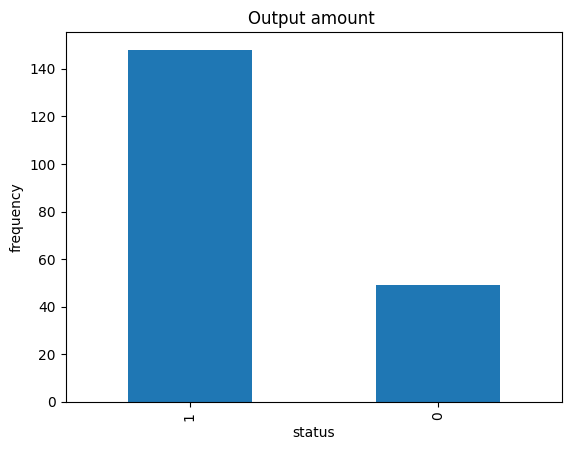

In [ ]:
count = pd.value_counts(combined_df['status'], sort = True)
count.plot(kind = "bar")
plt.title("Output amount ")
plt.xlabel("status")
plt.ylabel("frequency")
plt.show()

## Применение моделей

In [ ]:
#разделение выборок
X = combined_df.drop('status', axis=1)
y = combined_df['status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=11, stratify = y)

### Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [ ]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.60      0.72        15
           1       0.88      0.98      0.93        45

    accuracy                           0.88        60
   macro avg       0.89      0.79      0.82        60
weighted avg       0.89      0.88      0.87        60

Accuracy Score: 0.8833333333333333


In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_probs = rf.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)
best_threshold = 0.5
best_f1 = 0

for thresh in thresholds:
    y_pred_thresh = (y_probs >= thresh).astype(int)
    current_f1 = f1_score(y_test, y_pred_thresh, average='macro')
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = thresh

print(f"Лучший порог: {best_threshold:.2f}, F1-score: {best_f1:.3f}")

# Классификация с новым порогом
y_pred_optimized = (y_probs >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_optimized))

Лучший порог: 0.49, F1-score: 0.901
              precision    recall  f1-score   support

           0       1.00      0.73      0.85        15
           1       0.92      1.00      0.96        44

    accuracy                           0.93        59
   macro avg       0.96      0.87      0.90        59
weighted avg       0.94      0.93      0.93        59



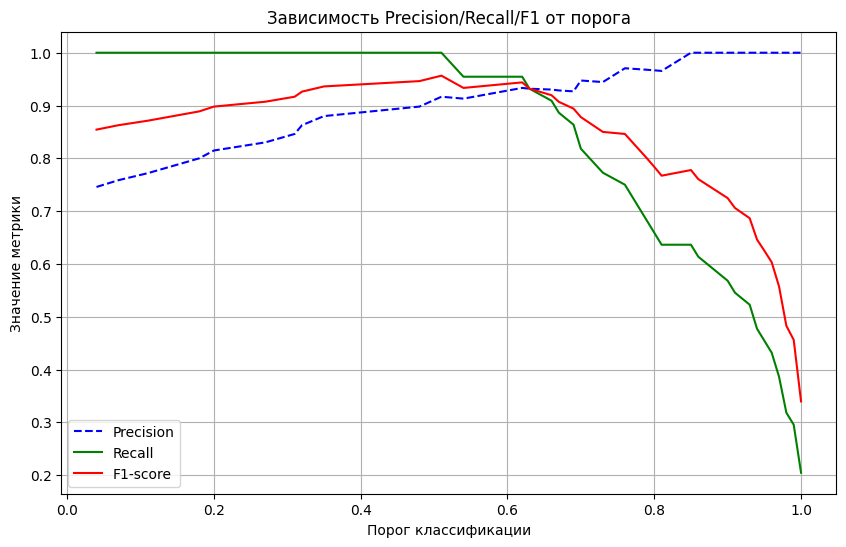

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Получаем вероятности для класса "1"
y_probs = rf.predict_proba(X_test)[:, 1]

# Вычисляем кривую
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Строим график
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.plot(thresholds, (2 * precisions * recalls)[:-1] / (precisions + recalls)[:-1], "r-", label="F1-score")
plt.xlabel("Порог классификации")
plt.ylabel("Значение метрики")
plt.legend()
plt.title("Зависимость Precision/Recall/F1 от порога")
plt.grid()
plt.show()

In [ ]:
#подбор гиперпараметров
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'max_features': ['sqrt', 'log2']
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}


In [ ]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\nEvaluation of Tuned Model:")
print(classification_report(y_test, y_pred_best))
print("Accuracy Score:", accuracy_score(y_test, y_pred_best))


Evaluation of Tuned Model:
              precision    recall  f1-score   support

           0       1.00      0.73      0.85        15
           1       0.92      1.00      0.96        44

    accuracy                           0.93        59
   macro avg       0.96      0.87      0.90        59
weighted avg       0.94      0.93      0.93        59

Accuracy Score: 0.9322033898305084


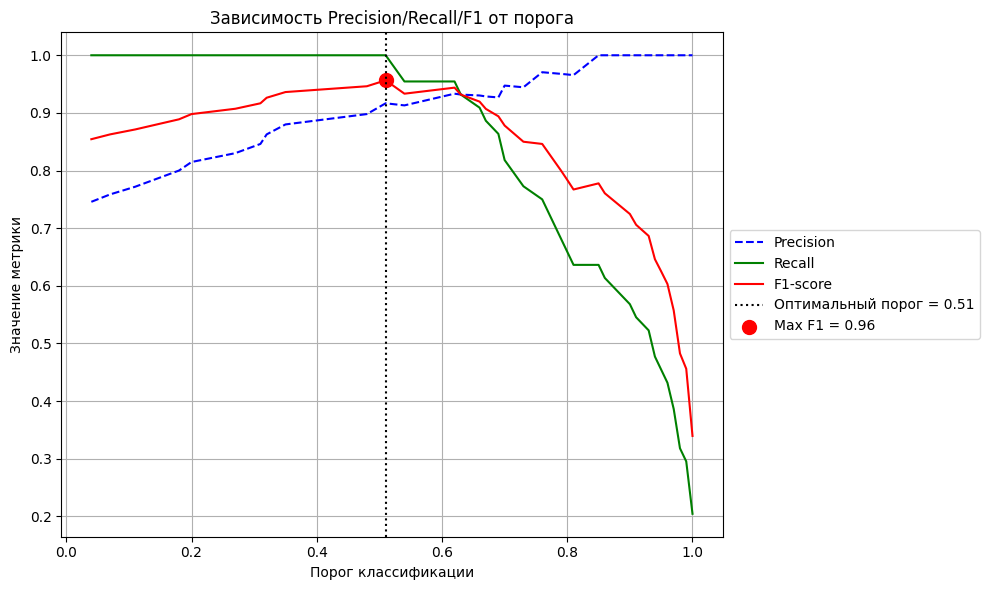

Оптимальный порог: 0.510
Максимальный F1-score: 0.957


In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Получаем вероятности для класса "1"
y_probs = best_model.predict_proba(X_test)[:, 1]

# Вычисляем кривую
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Рассчитываем F1-score для каждого порога
f1_scores = (2 * precisions * recalls) / (precisions + recalls)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

# Строим график
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.plot(thresholds, f1_scores[:-1], "r-", label="F1-score")

# Добавляем вертикальную линию для лучшего порога
plt.axvline(x=best_threshold, color='k', linestyle=':',
            label=f'Оптимальный порог = {best_threshold:.2f}')

# Добавляем точку максимума F1
plt.scatter(best_threshold, f1_scores[best_idx], color='red', s=100,
            label=f'Max F1 = {f1_scores[best_idx]:.2f}')

plt.xlabel("Порог классификации")
plt.ylabel("Значение метрики")
plt.title("Зависимость Precision/Recall/F1 от порога")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.tight_layout()
plt.show()

/tmp/ipython-input-37-4285762016.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:10], y=X.columns[indices][:10], palette='Set3')


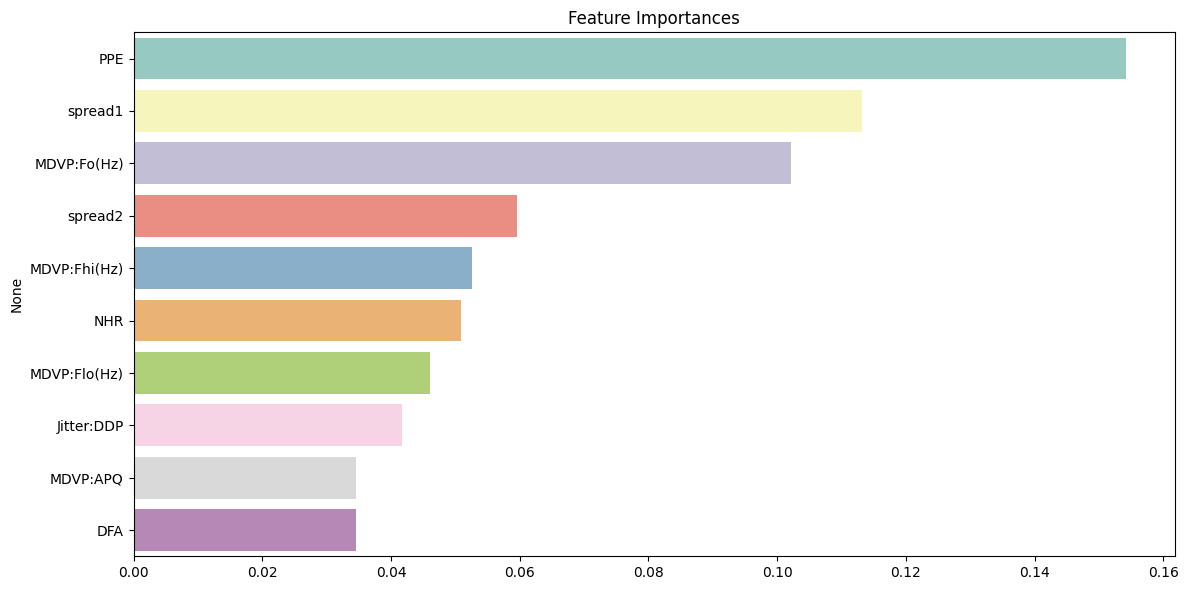

In [ ]:
#analyze feature importance
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
sns.barplot(x=importances[indices][:10], y=X.columns[indices][:10], palette='Set3')
plt.tight_layout()

/tmp/ipython-input-28-389352806.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette='Set3')


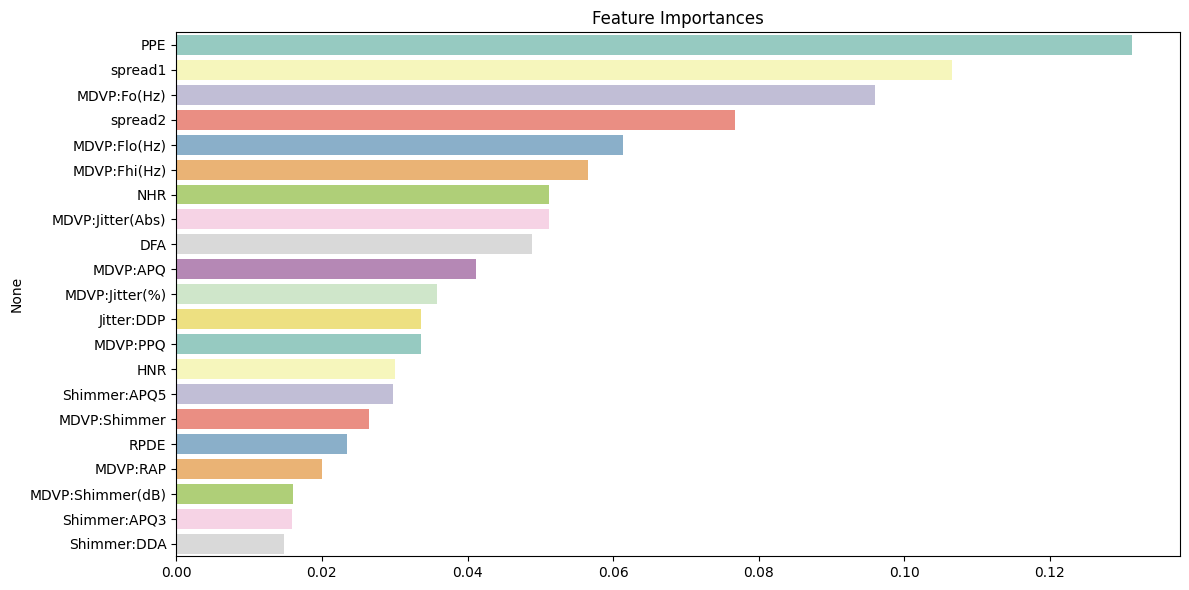

In [ ]:
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
sns.barplot(x=importances[indices], y=X.columns[indices], palette='Set3')
plt.tight_layout()

### XGBoost

In [ ]:
import xgboost as xgb

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)


xgb_best = xgb_grid.best_estimator_

print("Best Parameters for XGBoost:", xgb_grid.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters for XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:34:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
y_pred_xgb_best = xgb_best.predict(X_test)

print("\nClassification Report for Tuned XGBoost:")
print(classification_report(y_test, y_pred_xgb_best))
print("Accuracy Score:", accuracy_score(y_test, y_pred_xgb_best))


Classification Report for Tuned XGBoost:
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        15
           1       0.91      0.93      0.92        45

    accuracy                           0.88        60
   macro avg       0.85      0.83      0.84        60
weighted avg       0.88      0.88      0.88        60

Accuracy Score: 0.8833333333333333


### SVC

In [ ]:
model_svc=SVC(kernel='linear')
model_svc.fit(X_train, y_train)
pred_test=model_svc.predict(X_test)
print('Accuracy Score on testing data(without scaling): ',accuracy_score(y_test,pred_test))

Accuracy Score on testing data(without scaling):  0.8333333333333334


In [ ]:
#Нормализация данных
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
#подбор параметров с нормализацией данных
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42))
])

param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__gamma': ['scale', 'auto'] + [0.001, 0.01, 0.1],
    'svc__degree': [2, 3, 4]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность (accuracy):", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Лучшие параметры: {'svc__C': 100, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
Лучшая точность (accuracy): 0.9126984126984127

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        15
           1       0.95      0.93      0.94        45

    accuracy                           0.92        60
   macro avg       0.88      0.90      0.89        60
weighted avg       0.92      0.92      0.92        60



### KNN

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2],
    'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность (accuracy):", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Лучшие параметры: {'knn__algorithm': 'auto', 'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'uniform'}
Лучшая точность (accuracy): 0.9126984126984127

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       0.98      0.98      0.98        45

    accuracy                           0.97        60
   macro avg       0.96      0.96      0.96        60
weighted avg       0.97      0.97      0.97        60



# Глазодвигательный пайплайн

## Neon Metrics Pipeline (без видео)
=================================
Цель:
- Принять много ZIP (Neon export v2) в папке
- Распаковать/кешировать
- Найти все recordings внутри каждого ZIP (может быть 1+)
- Посчитать:
  1) subject_qc.csv (1 строка на recording)
  2) trial_metrics.csv (1 строка на trial)
  3) block_summary.csv (агрегаты по блокам)
- Построить сравнение таймлайнов healthy vs patient
- Сделать слепую кластеризацию по фичам

Термины/метрики/имена колонок — по ТЗ.

## Описание и конфиг

In [ ]:
from __future__ import annotations

from pathlib import Path
import re
import json
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# =========================
# CONFIG: пороги и параметры (ТЗ)
# =========================
CFG = {
    # RT detection (gaze-based)
    "thr_px_ratio": 0.05,         # 5% ширины (если знаем ширину)
    "thr_px_fallback": 60,        # иначе 60px
    "hold_ms_reaction": 40,       # удержание для реакции
    "search_window_reaction": (0.08, 0.70),

    # Target acquired
    "hold_ms_target": 80,
    "search_window_target": (0.0, 1.5),

    # Express-like
    "express_thr_ms": 120,

    # Large jumps proxy
    "jump_thr_px_ratio": 0.03,    # 3% ширины
    "jump_thr_px_fallback": 40,

    # QC flags thresholds
    "qc_worn_min": 0.8,
    "qc_gaze_rate_min_hz": 50,
    "qc_imu_gyro_rms_max": 50.0,  # стартовый порог, подберёте по своим данным
}

# =========================
# INPUT/OUTPUT
# =========================
DATASET_DIR = Path(r"./neon_zips")  # <-- папка, где лежат все zip: 6 HC + 2 PAT
WORK_DIR = Path(r"./neon_workdir")  # сюда будем распаковывать
OUTPUT_DIR = Path(r"./neon_outputs") # сюда пишем csv

WORK_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
DATASET_DIR.mkdir(parents=True, exist_ok=True)

## Сбор ZIP-файлов и определение метки (здоров/болен)

In [ ]:
def infer_label_from_zipname(zip_path: Path) -> tuple[int | None, str]:
    """
    Возвращает:
      label: 0=healthy/control, 1=patient, None=unknown
      label_text: 'healthy'/'patient'/'unknown'
    Рекомендуемая схема имен:
      HC_001.zip, CONTROL_*.zip -> healthy
      PAT_001.zip, AD_*.zip, MCI_*.zip -> patient
    """
    name = zip_path.stem.lower()

    healthy_tokens = ["hc", "healthy", "control", "ctl", "norm", "normal"]
    patient_tokens = ["pat", "patient", "ad", "alz", "alzheimer", "mci", "dement"]

    if any(tok in name for tok in patient_tokens):
        return 1, "patient"
    if any(tok in name for tok in healthy_tokens):
        return 0, "healthy"
    return None, "unknown"


def list_zip_files(dataset_dir: Path) -> list[Path]:
    zips = sorted(dataset_dir.glob("*.zip"))
    if not zips:
        raise FileNotFoundError(f"В папке {dataset_dir} не найдено .zip файлов")
    return zips


zip_files = list_zip_files(DATASET_DIR)

zip_index = []
for zp in zip_files:
    label, label_text = infer_label_from_zipname(zp)
    zip_index.append({
        "zip_path": str(zp),
        "zip_name": zp.name,
        "zip_stem": zp.stem,
        "label": label,
        "label_text": label_text,
    })

zip_index_df = pd.DataFrame(zip_index)
# display(zip_index_df)

# Если какие-то zip попали как unknown — можно вручную задать mapping:
# MANUAL_LABELS = {"somefile.zip": 0, "other.zip": 1}
MANUAL_LABELS = {}

if MANUAL_LABELS:
    for k, v in MANUAL_LABELS.items():
        mask = zip_index_df["zip_name"] == k
        zip_index_df.loc[mask, "label"] = v
        zip_index_df.loc[mask, "label_text"] = "patient" if v == 1 else "healthy"

display(zip_index_df)

,zip_path,zip_name,zip_stem,label,label_text
0,neon_zips/HC_001.zip,HC_001.zip,HC_001,0,healthy
1,neon_zips/HC_002.zip,HC_002.zip,HC_002,0,healthy
2,neon_zips/HC_003.zip,HC_003.zip,HC_003,0,healthy
3,neon_zips/HC_004.zip,HC_004.zip,HC_004,0,healthy
4,neon_zips/HC_005.zip,HC_005.zip,HC_005,0,healthy
5,neon_zips/HC_006.zip,HC_006.zip,HC_006,0,healthy
6,neon_zips/PAT_001.zip,PAT_001.zip,PAT_001,1,patient
7,neon_zips/PAT_002.zip,PAT_002.zip,PAT_002,1,patient


## Распаковка ZIP (кешируем) и поиск recordings

In [ ]:
def unzip_cached(zip_path: Path, work_dir: Path) -> Path:
    """
    Распаковывает zip в work_dir/<zip_stem>/ если ещё не распаковано.
    Возвращает корень распаковки для этого zip.
    """
    out_dir = work_dir / zip_path.stem
    if out_dir.exists():
        return out_dir

    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)
    return out_dir


def find_recording_folders(root: Path) -> list[Path]:
    """
    Ищем папки recordings внутри распакованного архива:
    критерий: наличие info.json и gaze.csv
    """
    root = Path(root)
    recs = []
    for p in root.rglob("info.json"):
        folder = p.parent
        if (folder / "gaze.csv").exists():
            recs.append(folder.resolve())
    return sorted(list({r for r in recs}))


# Строим таблицу всех recordings (это "импровизированный датасет")
records = []
for _, row in zip_index_df.iterrows():
    zp = Path(row["zip_path"])
    extracted_root = unzip_cached(zp, WORK_DIR)
    rec_folders = find_recording_folders(extracted_root)

    for rf in rec_folders:
        records.append({
            "zip_name": row["zip_name"],
            "zip_stem": row["zip_stem"],
            "label": row["label"],
            "label_text": row["label_text"],
            "recording_folder": str(rf),
            "recording_id": rf.name,  # по ТЗ: из folder name
        })

dataset_index = pd.DataFrame(records)
display(dataset_index)

print("Всего recordings:", len(dataset_index))

,zip_name,zip_stem,label,label_text,recording_folder,recording_id
0,HC_001.zip,HC_001,0,healthy,/content/neon_workdir/HC_001/2025-11-10_17-32-...,2025-11-10_17-32-11-c567dcb6
1,HC_002.zip,HC_002,0,healthy,/content/neon_workdir/HC_002/2025-12-22_15-21-...,2025-12-22_15-21-53-5007559b
2,HC_003.zip,HC_003,0,healthy,/content/neon_workdir/HC_003/2025-12-22_15-49-...,2025-12-22_15-49-23-4e211ab0
3,HC_004.zip,HC_004,0,healthy,/content/neon_workdir/HC_004/2025-12-22_15-36-...,2025-12-22_15-36-14-5ae0d89d
4,HC_005.zip,HC_005,0,healthy,/content/neon_workdir/HC_005/2025-12-22_16-02-...,2025-12-22_16-02-47-6f17655e
5,HC_006.zip,HC_006,0,healthy,/content/neon_workdir/HC_006/2026-01-07_14-37-...,2026-01-07_14-37-02-7649719b
6,PAT_001.zip,PAT_001,1,patient,/content/neon_workdir/PAT_001/мультиситемная_а...,мультиситемная_атрофия-2bcec8bf
7,PAT_002.zip,PAT_002,1,patient,/content/neon_workdir/PAT_002/болезнь_парксинс...,болезнь_парксинсона_смешанная_форма_3_стадия-e...


Всего recordings: 8


## Загрузка одной записи + нормализация времени (по ТЗ)

In [ ]:
def read_json(path: Path) -> dict:
    if not path.exists():
        return {}
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def read_csv_safe(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)

def add_time_seconds(df: pd.DataFrame, ts_col: str, t0_ns: int, out_col: str) -> pd.DataFrame:
    if df is None or df.empty:
        return df
    df = df.copy()
    df[out_col] = (df[ts_col].astype(np.int64) - int(t0_ns)) / 1e9
    return df

def load_recording(folder: Path) -> dict:
    """
    load_recording(path) -> dict(dataframes)
    По ТЗ: принимает папку (у нас уже распаковано), но выше мы принимаем и zip.
    """
    folder = Path(folder)
    info = read_json(folder / "info.json")
    scene_camera = read_json(folder / "scene_camera.json")

    rec = {
        "folder": folder,
        "recording_id": folder.name,
        "info": info,
        "scene_camera": scene_camera,
        "gaze": read_csv_safe(folder / "gaze.csv"),
        "fixations": read_csv_safe(folder / "fixations.csv"),
        "saccades": read_csv_safe(folder / "saccades.csv"),
        "blinks": read_csv_safe(folder / "blinks.csv"),
        "events": read_csv_safe(folder / "events.csv"),
        "imu": read_csv_safe(folder / "imu.csv"),
        "world_timestamps": read_csv_safe(folder / "world_timestamps.csv"),
    }
    return rec

def normalize_time(rec: dict) -> dict:
    """
    normalize_time(rec) -> rec
    По ТЗ:
      t0_ns = info["start_time"]
      t_s = (timestamp_ns - t0_ns)/1e9
    """
    t0_ns = rec["info"].get("start_time")
    if t0_ns is None:
        # fallback: min timestamp из gaze/events
        candidates = []
        if not rec["gaze"].empty:
            candidates.append(rec["gaze"]["timestamp [ns]"].min())
        if not rec["events"].empty:
            candidates.append(rec["events"]["timestamp [ns]"].min())
        if not candidates:
            raise ValueError(f"Не удалось определить t0_ns для recording {rec['recording_id']}")
        t0_ns = int(min(candidates))

    rec["t0_ns"] = int(t0_ns)

    rec["gaze"] = add_time_seconds(rec["gaze"], "timestamp [ns]", t0_ns, "t_s")
    rec["events"] = add_time_seconds(rec["events"], "timestamp [ns]", t0_ns, "t_s")

    rec["fixations"] = add_time_seconds(rec["fixations"], "start timestamp [ns]", t0_ns, "t_start_s")
    rec["fixations"] = add_time_seconds(rec["fixations"], "end timestamp [ns]", t0_ns, "t_end_s")

    rec["saccades"] = add_time_seconds(rec["saccades"], "start timestamp [ns]", t0_ns, "t_start_s")
    rec["saccades"] = add_time_seconds(rec["saccades"], "end timestamp [ns]", t0_ns, "t_end_s")

    rec["blinks"] = add_time_seconds(rec["blinks"], "start timestamp [ns]", t0_ns, "t_start_s")
    rec["blinks"] = add_time_seconds(rec["blinks"], "end timestamp [ns]", t0_ns, "t_end_s")

    rec["imu"] = add_time_seconds(rec["imu"], "timestamp [ns]", t0_ns, "t_s")
    rec["world_timestamps"] = add_time_seconds(rec["world_timestamps"], "timestamp [ns]", t0_ns, "t_s")

    return rec

# Быстрый тест на одной записи
sample_folder = Path(dataset_index.iloc[0]["recording_folder"])
rec0 = normalize_time(load_recording(sample_folder))

print("recording_id:", rec0["recording_id"])
print("gaze t_s range:", rec0["gaze"]["t_s"].min(), rec0["gaze"]["t_s"].max())
print("events t_s range:", rec0["events"]["t_s"].min(), rec0["events"]["t_s"].max())

recording_id: 2025-11-10_17-32-11-c567dcb6
gaze t_s range: 2.473939274 727.853910274
events t_s range: 0.0 727.86


## Парсинг блоков и trial-событий (по ТЗ)

In [ ]:
# По ТЗ: blocks = PREDICTION, GAP, OVERLAP, DECISION, ANTISACCADE, CALIB
def infer_block_windows(events: pd.DataFrame) -> pd.DataFrame:
    """
    infer_block_windows(events) -> df(block, part, t_start, t_end)
    По ТЗ:
      intro: START_<B>_BLOCK_START .. START_<B>_BLOCK_END
      trials: START_<B>_BLOCK_END .. END_<B>_BLOCK_START
      outro: END_<B>_BLOCK_START .. END_<B>_BLOCK_END
    Для CALIB: CALIB_BLOCK_START..CALIB_BLOCK_END
    """
    ev = events.sort_values("timestamp [ns]").copy()
    rows = []

    # CALIB
    if (ev["name"] == "CALIB_BLOCK_START").any() and (ev["name"] == "CALIB_BLOCK_END").any():
        t_start = ev.loc[ev["name"]=="CALIB_BLOCK_START", "t_s"].min()
        t_end   = ev.loc[ev["name"]=="CALIB_BLOCK_END", "t_s"].min()
        rows.append({"block":"CALIB", "part":"trials", "t_start":t_start, "t_end":t_end})

    for b in ["PREDICTION","GAP","OVERLAP","DECISION","ANTISACCADE"]:
        s1 = f"START_{b}_BLOCK_START"
        s2 = f"START_{b}_BLOCK_END"
        e1 = f"END_{b}_BLOCK_START"
        e2 = f"END_{b}_BLOCK_END"
        if not ((ev["name"]==s1).any() and (ev["name"]==s2).any() and (ev["name"]==e1).any() and (ev["name"]==e2).any()):
            continue

        intro_start = ev.loc[ev["name"]==s1, "t_s"].min()
        intro_end   = ev.loc[ev["name"]==s2, "t_s"].min()
        trials_start = intro_end
        trials_end   = ev.loc[ev["name"]==e1, "t_s"].min()
        outro_start  = trials_end
        outro_end    = ev.loc[ev["name"]==e2, "t_s"].min()

        rows += [
            {"block":b, "part":"intro",  "t_start":intro_start, "t_end":intro_end},
            {"block":b, "part":"trials", "t_start":trials_start, "t_end":trials_end},
            {"block":b, "part":"outro",  "t_start":outro_start, "t_end":outro_end},
        ]

    return pd.DataFrame(rows).sort_values(["t_start","block","part"]).reset_index(drop=True)


def parse_event_name(name: str):
    """
    По ТЗ:
      "<trial>.<step>_<tag>_<edge>", edge in {start,end}
    tag может быть сложным: LEFT_16, RIGHT_12_CORRECT, GREEN, ...
    Извлекаем:
      side, color, correctness, param_num
    """
    m = re.match(r"(?P<trial>\d+)\.(?P<step>\d+)_(?P<tag>.*)_(?P<edge>start|end)$", str(name))
    if not m:
        return None

    d = m.groupdict()
    d["trial_id"] = int(d.pop("trial"))
    d["step"] = int(d["step"])

    tag = d["tag"]
    parts = tag.split("_")

    side_set = {"LEFT","RIGHT","CENTER","UP","DOWN"}
    color_set = {"RED","GREEN","BLUE","YELLOW","WHITE","BLACK"}

    d["side"] = parts[0] if parts and parts[0] in side_set else None
    d["color"] = parts[0] if parts and parts[0] in color_set else None

    d["correctness"] = None
    if "CORRECT" in parts:
        d["correctness"] = "CORRECT"
    elif "INCORRECT" in parts:
        d["correctness"] = "INCORRECT"

    d["param_num"] = None
    for p in parts[1:]:
        if p.isdigit():
            d["param_num"] = int(p)
            break

    return d


def parse_trial_events(events: pd.DataFrame, block_windows: pd.DataFrame) -> pd.DataFrame:
    """
    parse_trial_events(events, block_windows) -> df
    Выдаёт parsed events таблицу по ТЗ:
      block, trial_id, step, tag, edge, side, color, correctness, param_num, t_s
    Парсим только внутри part='trials' окон.
    """
    out = []
    for _, bw in block_windows[block_windows["part"]=="trials"].iterrows():
        b = bw["block"]
        seg = events[(events["t_s"]>=bw["t_start"]) & (events["t_s"]<=bw["t_end"])].copy()
        seg = seg.sort_values("timestamp [ns]")

        for _, r in seg.iterrows():
            p = parse_event_name(r["name"])
            if p is None:
                continue
            p["block"] = b
            p["t_s"] = float(r["t_s"])
            out.append(p)

    if not out:
        return pd.DataFrame()

    cols = ["block","trial_id","step","tag","edge","side","color","correctness","param_num","t_s"]
    return pd.DataFrame(out)[cols].sort_values(["block","trial_id","step","t_s"]).reset_index(drop=True)


# тест на sample
bw0 = infer_block_windows(rec0["events"])
pe0 = parse_trial_events(rec0["events"], bw0)

display(bw0)
display(pe0.head(20))
print("parsed events shape:", pe0.shape)

,block,part,t_start,t_end
0,CALIB,trials,2.687183,46.072882
1,PREDICTION,intro,65.786034,67.988160
2,PREDICTION,trials,67.988160,124.019460
3,PREDICTION,outro,124.019460,126.099585
4,ANTISACCADE,intro,167.724894,169.970745
5,ANTISACCADE,trials,169.970745,303.933222
6,ANTISACCADE,outro,303.933222,306.044707
7,GAP,intro,334.338824,336.520467
8,GAP,trials,336.520467,439.718575
9,GAP,outro,439.718575,441.749831


,block,trial_id,step,tag,edge,side,color,correctness,param_num,t_s
0,ANTISACCADE,1,1,CENTER,start,CENTER,None,None,NaN,170.098023
1,ANTISACCADE,1,1,CENTER,end,CENTER,None,None,NaN,172.927740
2,ANTISACCADE,1,2,RED,start,None,RED,None,NaN,172.965242
3,ANTISACCADE,1,2,RED,end,None,RED,None,NaN,174.488836
4,ANTISACCADE,1,3,GREEN,start,None,GREEN,None,NaN,174.503889
5,ANTISACCADE,1,3,GREEN,end,None,GREEN,None,NaN,176.025463
6,ANTISACCADE,2,1,CENTER,start,CENTER,None,None,NaN,176.653916
7,ANTISACCADE,2,1,CENTER,end,CENTER,None,None,NaN,179.566328
8,ANTISACCADE,2,2,RED,start,None,RED,None,NaN,179.622463
9,ANTISACCADE,2,2,RED,end,None,RED,None,NaN,181.145283


parsed events shape: (560, 10)


## QC-метрики (subject_qc.csv)

In [ ]:
def estimate_gaze_rate_hz(gaze_t: pd.Series) -> float:
    ts = gaze_t.dropna().values
    if len(ts) < 5:
        return np.nan
    dt = np.diff(ts)
    dt = dt[(dt > 0) & (dt < np.quantile(dt, 0.99))]
    if len(dt) == 0:
        return np.nan
    return float(1.0 / np.median(dt))

def imu_gyro_rms(imu: pd.DataFrame) -> float:
    if imu is None or imu.empty:
        return np.nan
    gyro_cols = [c for c in imu.columns if c.lower().startswith("gyro")]
    if not gyro_cols:
        return np.nan
    arr = imu[gyro_cols].fillna(0).values
    return float(np.sqrt(np.mean(arr**2)))

def compute_qc(rec: dict, cfg=CFG) -> dict:
    """
    compute_qc(rec) -> row dict для subject_qc.csv
    По ТЗ: обязательные поля + qc flags.
    """
    gaze = rec["gaze"]
    fix = rec["fixations"]
    sac = rec["saccades"]
    bl  = rec["blinks"]

    recording_id = rec["recording_id"]

    # duration_s
    if rec["info"].get("duration"):
        duration_s = float(rec["info"]["duration"]) / 1e9
    else:
        duration_s = float(gaze["t_s"].max()) if not gaze.empty else np.nan

    gaze_rate_hz = estimate_gaze_rate_hz(gaze["t_s"]) if not gaze.empty else np.nan
    worn_ratio = float(gaze["worn"].mean()) if (not gaze.empty and "worn" in gaze.columns) else np.nan
    n_gaze_samples = int(len(gaze))

    blink_rate_per_min = (len(bl) / (duration_s/60)) if (duration_s and not bl.empty) else np.nan

    fix_dur_med = float(fix["duration [ms]"].median()) if (not fix.empty and "duration [ms]" in fix.columns) else np.nan
    fix_dur_mean = float(fix["duration [ms]"].mean()) if (not fix.empty and "duration [ms]" in fix.columns) else np.nan

    n_saccades = int(len(sac))
    sacc_amp_deg_mean = float(sac["amplitude [deg]"].mean()) if (not sac.empty and "amplitude [deg]" in sac.columns) else np.nan
    sacc_peak_px_s_mean = float(sac["peak velocity [px/s]"].mean()) if (not sac.empty and "peak velocity [px/s]" in sac.columns) else np.nan

    imu_rms = imu_gyro_rms(rec["imu"])

    qc_flag_low_worn = int((not np.isnan(worn_ratio)) and (worn_ratio < cfg["qc_worn_min"]))
    qc_flag_low_rate = int((not np.isnan(gaze_rate_hz)) and (gaze_rate_hz < cfg["qc_gaze_rate_min_hz"]))
    qc_flag_high_motion = int((not np.isnan(imu_rms)) and (imu_rms > cfg["qc_imu_gyro_rms_max"]))

    return {
        "recording_id": recording_id,
        "duration_s": duration_s,
        "gaze_rate_hz": gaze_rate_hz,
        "worn_ratio": worn_ratio,
        "n_gaze_samples": n_gaze_samples,
        "blink_rate_per_min": blink_rate_per_min,
        "n_fixations": int(len(fix)),
        "fix_dur_ms_median": fix_dur_med,
        "fix_dur_ms_mean": fix_dur_mean,
        "n_saccades": n_saccades,
        "sacc_amp_deg_mean": sacc_amp_deg_mean,
        "sacc_peak_px_s_mean": sacc_peak_px_s_mean,
        "imu_gyro_rms": imu_rms,
        "qc_flag_low_worn": qc_flag_low_worn,
        "qc_flag_low_rate": qc_flag_low_rate,
        "qc_flag_high_motion": qc_flag_high_motion,
    }

qc0 = compute_qc(rec0)
qc0

{'recording_id': '2025-11-10_17-32-11-c567dcb6',
 'duration_s': 727.86,
 'gaze_rate_hz': 249.00398406506548,
 'worn_ratio': 1.0,
 'n_gaze_samples': 144884,
 'blink_rate_per_min': 39.15588162558734,
 'n_fixations': 995,
 'fix_dur_ms_median': 268.0,
 'fix_dur_ms_mean': 599.7628140703517,
 'n_saccades': 995,
 'sacc_amp_deg_mean': 7.30371882143878,
 'sacc_peak_px_s_mean': 4921.638762322186,
 'imu_gyro_rms': 0.8251479029010139,
 'qc_flag_low_worn': 0,
 'qc_flag_low_rate': 0,
 'qc_flag_high_motion': 0}

## Вспомогательные функции для gaze-based RT/target acquired

In [ ]:
def get_frame_width_from_scene_camera(scene_camera: dict) -> int | None:
    """
    Пытаемся вытащить ширину кадра без видео.
    В Neon scene_camera.json часто есть resolution/width/height (зависит от версии).
    Если не нашли — None.
    """
    if not scene_camera:
        return None
    # варианты
    if "resolution" in scene_camera and isinstance(scene_camera["resolution"], (list, tuple)) and len(scene_camera["resolution"]) == 2:
        return int(scene_camera["resolution"][0])
    if "width" in scene_camera:
        return int(scene_camera["width"])
    if "camera" in scene_camera and isinstance(scene_camera["camera"], dict):
        if "resolution" in scene_camera["camera"]:
            r = scene_camera["camera"]["resolution"]
            if isinstance(r, (list, tuple)) and len(r) == 2:
                return int(r[0])
    return None

def gaze_valid_mask(gaze: pd.DataFrame) -> pd.Series:
    """
    По ТЗ: исключать worn!=1 и blink id not null (если есть).
    """
    mask = pd.Series(True, index=gaze.index)
    if "worn" in gaze.columns:
        mask &= (gaze["worn"] == 1)
    if "blink id" in gaze.columns:
        mask &= gaze["blink id"].isna()
    return mask

def sustained_condition_time(ts: np.ndarray, cond: np.ndarray, min_hold_s: float) -> float | None:
    """
    Находит первое время, где cond=True удерживается непрерывно >= min_hold_s.
    Возвращает ts[start] или None.
    """
    if len(ts) == 0:
        return None
    i = 0
    n = len(ts)
    while i < n:
        if not cond[i]:
            i += 1
            continue
        j = i
        while j < n and cond[j]:
            j += 1
        # участок [i, j-1]
        if ts[j-1] - ts[i] >= min_hold_s:
            return float(ts[i])
        i = j
    return None

def compute_thr_px(rec: dict, cfg=CFG) -> int:
    w = get_frame_width_from_scene_camera(rec.get("scene_camera", {}))
    if w is None:
        return int(cfg["thr_px_fallback"])
    return int(max(cfg["thr_px_fallback"], cfg["thr_px_ratio"] * w))

def compute_jump_thr_px(rec: dict, cfg=CFG) -> int:
    w = get_frame_width_from_scene_camera(rec.get("scene_camera", {}))
    if w is None:
        return int(cfg["jump_thr_px_fallback"])
    return int(max(cfg["jump_thr_px_fallback"], cfg["jump_thr_px_ratio"] * w))

def gaze_based_rt(rec: dict, onset_s: float, cfg=CFG) -> dict:
    """
    По ТЗ:
      baseline_x/y = median gaze в [onset-0.20, onset-0.05]
      rt_s: первое t после onset+0.08..+0.70 где |gaze_x - baseline_x|>=thr_px удерживается >= hold_ms_reaction
      response_dir по медиане gaze_x в [rt_s, rt_s+0.12]
    """
    gaze = rec["gaze"]
    thr_px = compute_thr_px(rec, cfg)

    # baseline window
    base = gaze[(gaze["t_s"]>=onset_s-0.20) & (gaze["t_s"]<=onset_s-0.05)].copy()
    base = base[gaze_valid_mask(base)]
    if len(base) < 5:
        return {"qc_trial_valid": 0, "baseline_x": np.nan, "baseline_y": np.nan, "rt_s": None, "rt_found": 0,
                "rt_gaze_ms": np.nan, "response_dir": None, "thr_px": thr_px}

    baseline_x = float(base["gaze x [px]"].median())
    baseline_y = float(base["gaze y [px]"].median())

    # reaction search window
    w0, w1 = cfg["search_window_reaction"]
    seg = gaze[(gaze["t_s"]>=onset_s+w0) & (gaze["t_s"]<=onset_s+w1)].copy()
    seg = seg[gaze_valid_mask(seg)]
    if len(seg) < 10:
        return {"qc_trial_valid": 0, "baseline_x": baseline_x, "baseline_y": baseline_y, "rt_s": None, "rt_found": 0,
                "rt_gaze_ms": np.nan, "response_dir": None, "thr_px": thr_px}

    ts = seg["t_s"].values
    dx = (seg["gaze x [px]"].values - baseline_x)
    cond = np.abs(dx) >= thr_px

    rt_s = sustained_condition_time(ts, cond, cfg["hold_ms_reaction"]/1000.0)

    if rt_s is None:
        return {"qc_trial_valid": 1, "baseline_x": baseline_x, "baseline_y": baseline_y, "rt_s": None, "rt_found": 0,
                "rt_gaze_ms": np.nan, "response_dir": None, "thr_px": thr_px}

    rt_gaze_ms = float((rt_s - onset_s) * 1000.0)

    # response_dir
    resp = gaze[(gaze["t_s"]>=rt_s) & (gaze["t_s"]<=rt_s+0.12)].copy()
    resp = resp[gaze_valid_mask(resp)]
    if len(resp) < 5:
        response_dir = None
    else:
        dx_med = float(resp["gaze x [px]"].median() - baseline_x)
        response_dir = "RIGHT" if dx_med > 0 else "LEFT"

    return {"qc_trial_valid": 1, "baseline_x": baseline_x, "baseline_y": baseline_y,
            "rt_s": rt_s, "rt_found": 1, "rt_gaze_ms": rt_gaze_ms, "response_dir": response_dir, "thr_px": thr_px}

def target_acquired_time(rec: dict, onset_s: float, target_side: str, baseline_x: float, cfg=CFG) -> dict:
    """
    По ТЗ:
      target acquired если gaze попадает в сектор (LEFT/RIGHT) и удерживается >= hold_ms_target
      поиск в [onset, onset+1.5]
      time_to_target_ms = (t_target - onset)*1000
    """
    gaze = rec["gaze"]
    thr_px = compute_thr_px(rec, cfg)

    w0, w1 = cfg["search_window_target"]
    seg = gaze[(gaze["t_s"]>=onset_s+w0) & (gaze["t_s"]<=onset_s+w1)].copy()
    seg = seg[gaze_valid_mask(seg)]
    if len(seg) < 10 or (target_side not in ["LEFT","RIGHT"]) or np.isnan(baseline_x):
        return {"target_reached": 0, "t_target": None, "time_to_target_ms": np.nan}

    x = seg["gaze x [px]"].values
    ts = seg["t_s"].values

    if target_side == "LEFT":
        cond = x <= (baseline_x - thr_px)
    else:
        cond = x >= (baseline_x + thr_px)

    t_target = sustained_condition_time(ts, cond, cfg["hold_ms_target"]/1000.0)
    if t_target is None:
        return {"target_reached": 0, "t_target": None, "time_to_target_ms": np.nan}

    return {"target_reached": 1, "t_target": t_target, "time_to_target_ms": float((t_target - onset_s)*1000.0)}

def rt_saccade_reference(rec: dict, onset_s: float, cfg=CFG) -> dict:
    """
    По ТЗ: rt_saccade_ms только как reference (из saccades.csv).
    Берём первую саккаду со start в [onset+0.08, onset+0.70]
    """
    sac = rec["saccades"]
    w0, w1 = cfg["search_window_reaction"]
    cand = sac[(sac["t_start_s"]>=onset_s+w0) & (sac["t_start_s"]<=onset_s+w1)].sort_values("t_start_s")
    if cand.empty:
        return {"rt_saccade_found": 0, "rt_saccade_ms": np.nan}
    t = float(cand.iloc[0]["t_start_s"])
    return {"rt_saccade_found": 1, "rt_saccade_ms": float((t - onset_s)*1000.0)}

## Trial metrics (trial_metrics.csv)

In [ ]:
def trial_window_from_parsed(parsed_block: pd.DataFrame, trial_id: int, onset_s: float) -> tuple[float, float]:
    """
    По ТЗ:
      окно trial для фиксаций:
        [step1_start, step2_end] если есть,
        иначе [onset-0.5, onset+1.5]
    """
    t0 = onset_s - 0.5
    t1 = onset_s + 1.5

    sub = parsed_block[parsed_block["trial_id"]==trial_id]
    # step1 start
    s1 = sub[(sub["step"]==1) & (sub["edge"]=="start")]["t_s"]
    # step2 end
    e2 = sub[(sub["step"]==2) & (sub["edge"]=="end")]["t_s"]

    if not s1.empty:
        t0 = float(s1.min())
    if not e2.empty:
        t1 = float(e2.max())
    return t0, t1

def fixation_trial_stats(rec: dict, t0: float, t1: float) -> dict:
    """
    По ТЗ:
      fix_dur_ms_mean_trial / median_trial
    """
    fix = rec["fixations"]
    if fix is None or fix.empty or "duration [ms]" not in fix.columns:
        return {"fix_dur_ms_mean_trial": np.nan, "fix_dur_ms_median_trial": np.nan}

    # фиксация попадает в окно, если начало/конец пересекаются с [t0,t1]
    seg = fix[(fix["t_end_s"]>=t0) & (fix["t_start_s"]<=t1)]
    if seg.empty:
        return {"fix_dur_ms_mean_trial": np.nan, "fix_dur_ms_median_trial": np.nan}
    return {
        "fix_dur_ms_mean_trial": float(seg["duration [ms]"].mean()),
        "fix_dur_ms_median_trial": float(seg["duration [ms]"].median())
    }

def count_large_jumps(gaze: pd.DataFrame, t0: float, t1: float, jump_thr_px: float) -> int:
    """
    По ТЗ:
      n_large_jumps_to_target — proxy по gaze:
      |Δgaze_x| между соседними точками > jump_thr_px (исключая blink/worn)
    """
    seg = gaze[(gaze["t_s"]>=t0) & (gaze["t_s"]<=t1)].copy()
    seg = seg[gaze_valid_mask(seg)]
    if len(seg) < 3:
        return 0
    dx = np.diff(seg["gaze x [px]"].values)
    return int(np.sum(np.abs(dx) > jump_thr_px))

def compute_trial_metrics_for_block(rec: dict, parsed_events: pd.DataFrame, block: str, cfg=CFG) -> pd.DataFrame:
    """
    compute_trial_metrics(rec, parsed_events, block) -> df(trial_metrics)
    По ТЗ:
      - PREDICTION/GAP/OVERLAP: target_side из step=2 start, side LEFT/RIGHT
      - DECISION: onset=min(step2 start), correct_side из step3 CORRECT
      - ANTISACCADE: cue_color на step=2 start (RED/GREEN), без direction_error
    """
    pe = parsed_events[parsed_events["block"]==block].copy()
    if pe.empty:
        return pd.DataFrame()

    rows = []
    gaze = rec["gaze"]
    jump_thr_px = compute_jump_thr_px(rec, cfg)

    # trials list
    for trial_id in sorted(pe["trial_id"].unique()):
        trial = pe[pe["trial_id"]==trial_id].copy()

        base_row = {
            "recording_id": rec["recording_id"],
            "block": block,
            "trial_id": int(trial_id),
            "onset_s": np.nan,
            "target_side": None,
            "qc_trial_valid": 0,
        }

        if block in ["PREDICTION","GAP","OVERLAP"]:
            onset_candidates = trial[(trial["step"]==2) & (trial["edge"]=="start") & (trial["side"].isin(["LEFT","RIGHT"]))][["t_s","side"]]
            if onset_candidates.empty:
                rows.append(base_row)
                continue

            onset_s = float(onset_candidates["t_s"].min())
            target_side = onset_candidates.sort_values("t_s").iloc[0]["side"]

            base_row["onset_s"] = onset_s
            base_row["target_side"] = target_side

            # RT (gaze-based)
            rt = gaze_based_rt(rec, onset_s, cfg)
            base_row["qc_trial_valid"] = int(rt["qc_trial_valid"])
            base_row["rt_found"] = int(rt["rt_found"])
            base_row["rt_gaze_ms"] = rt["rt_gaze_ms"]
            base_row["response_dir"] = rt["response_dir"]

            # saccade reference
            sref = rt_saccade_reference(rec, onset_s, cfg)
            base_row.update(sref)

            # direction error
            if base_row["rt_found"] == 1 and base_row["response_dir"] in ["LEFT","RIGHT"]:
                base_row["direction_error"] = int(base_row["response_dir"] != target_side)
            else:
                base_row["direction_error"] = np.nan

            # express-like
            base_row["express_like"] = int((base_row["rt_found"]==1) and (base_row["rt_gaze_ms"] < cfg["express_thr_ms"]))

            # target acquired
            ta = target_acquired_time(rec, onset_s, target_side, rt["baseline_x"], cfg)
            base_row["target_reached"] = int(ta["target_reached"])
            base_row["time_to_target_ms"] = ta["time_to_target_ms"]

            # post_response_dx_px + accuracy_sector
            if rt["rt_s"] is not None:
                post = gaze[(gaze["t_s"]>=rt["rt_s"]+0.15) & (gaze["t_s"]<=rt["rt_s"]+0.35)].copy()
                post = post[gaze_valid_mask(post)]
                if len(post) >= 5:
                    post_dx = float(post["gaze x [px]"].median() - rt["baseline_x"])
                else:
                    post_dx = np.nan
            else:
                post_dx = np.nan

            base_row["post_response_dx_px"] = post_dx
            if not np.isnan(post_dx) and target_side in ["LEFT","RIGHT"]:
                base_row["accuracy_sector"] = int((post_dx > 0 and target_side=="RIGHT") or (post_dx < 0 and target_side=="LEFT"))
            else:
                base_row["accuracy_sector"] = np.nan

            # фиксации в окне trial
            t0, t1 = trial_window_from_parsed(pe, trial_id, onset_s)
            base_row.update(fixation_trial_stats(rec, t0, t1))

            # large jumps до цели
            if ta["t_target"] is not None:
                n_jumps = count_large_jumps(gaze, onset_s, ta["t_target"], jump_thr_px)
            else:
                n_jumps = count_large_jumps(gaze, onset_s, onset_s + cfg["search_window_target"][1], jump_thr_px)

            base_row["n_large_jumps_to_target"] = n_jumps
            base_row["n_steps_to_target"] = n_jumps  # proxy по ТЗ

            # доля времени на достижение цели
            # trial_duration_ms: step2_end - onset, иначе 2000ms
            step2_end = trial[(trial["step"]==2) & (trial["edge"]=="end")]["t_s"]
            if not step2_end.empty:
                trial_dur_ms = float((step2_end.max() - onset_s) * 1000.0)
            else:
                trial_dur_ms = 2000.0

            base_row["trial_duration_ms"] = trial_dur_ms
            if base_row["target_reached"] == 1 and not np.isnan(base_row["time_to_target_ms"]) and trial_dur_ms > 0:
                base_row["time_to_target_share"] = float(base_row["time_to_target_ms"] / trial_dur_ms)
            else:
                base_row["time_to_target_share"] = np.nan

            rows.append(base_row)
            continue

        if block == "DECISION":
            onset_candidates = trial[(trial["step"]==2) & (trial["edge"]=="start")][["t_s"]]
            if onset_candidates.empty:
                rows.append(base_row)
                continue

            onset_s = float(onset_candidates["t_s"].min())
            base_row["onset_s"] = onset_s

            # correct_side из step=3 CORRECT
            corr = trial[(trial["step"]==3) & (trial["correctness"]=="CORRECT") & (trial["edge"]=="start")]["side"]
            correct_side = corr.iloc[0] if not corr.empty else None

            # RT по gaze (decision_rt_gaze_ms) + choice_side
            rt = gaze_based_rt(rec, onset_s, cfg)
            base_row["qc_trial_valid"] = int(rt["qc_trial_valid"])
            base_row["decision_rt_gaze_ms"] = rt["rt_gaze_ms"]
            base_row["choice_side"] = rt["response_dir"]
            base_row["correct_side"] = correct_side

            if (base_row["choice_side"] in ["LEFT","RIGHT"]) and (correct_side in ["LEFT","RIGHT"]):
                base_row["decision_correct"] = int(base_row["choice_side"] == correct_side)
            else:
                base_row["decision_correct"] = np.nan

            # фиксации trial
            t0, t1 = trial_window_from_parsed(pe, trial_id, onset_s)
            base_row.update(fixation_trial_stats(rec, t0, t1))

            rows.append(base_row)
            continue

        if block == "ANTISACCADE":
            # cue_color на step=2 start
            cue = trial[(trial["step"]==2) & (trial["edge"]=="start")]["color"]
            if cue.empty:
                rows.append(base_row)
                continue

            onset_s = float(trial[(trial["step"]==2) & (trial["edge"]=="start")]["t_s"].min())
            cue_color = cue.iloc[0]

            base_row["onset_s"] = onset_s
            base_row["cue_color"] = cue_color

            rt = gaze_based_rt(rec, onset_s, cfg)
            base_row["qc_trial_valid"] = int(rt["qc_trial_valid"])
            base_row["rt_found"] = int(rt["rt_found"])
            base_row["rt_gaze_ms"] = rt["rt_gaze_ms"]
            base_row["response_dir"] = rt["response_dir"]

            # фиксации trial
            t0, t1 = trial_window_from_parsed(pe, trial_id, onset_s)
            base_row.update(fixation_trial_stats(rec, t0, t1))

            rows.append(base_row)
            continue

    return pd.DataFrame(rows)

# тест на sample
tm_pred = compute_trial_metrics_for_block(rec0, pe0, "PREDICTION")
display(tm_pred.head(10))

,recording_id,block,trial_id,onset_s,target_side,qc_trial_valid,rt_found,rt_gaze_ms,response_dir,rt_saccade_found,...,target_reached,time_to_target_ms,post_response_dx_px,accuracy_sector,fix_dur_ms_mean_trial,fix_dur_ms_median_trial,n_large_jumps_to_target,n_steps_to_target,trial_duration_ms,time_to_target_share
0,2025-11-10_17-32-11-c567dcb6,PREDICTION,1,69.054843,LEFT,1,1,387.063274,LEFT,1,...,1,387.063274,-178.4795,1.0,363.333333,224.0,0,0,1017.275,0.380490
1,2025-11-10_17-32-11-c567dcb6,PREDICTION,2,71.793922,RIGHT,1,1,340.032274,RIGHT,1,...,1,340.032274,212.3600,1.0,948.000000,1192.0,0,0,1018.050,0.334004
2,2025-11-10_17-32-11-c567dcb6,PREDICTION,3,74.659077,LEFT,1,1,246.876274,LEFT,1,...,1,246.876274,-171.2080,1.0,1306.000000,1306.0,0,0,1015.168,0.243188
3,2025-11-10_17-32-11-c567dcb6,PREDICTION,4,77.527991,RIGHT,1,1,81.956274,RIGHT,0,...,1,1.926274,155.6330,1.0,657.250000,674.0,0,0,1028.286,0.001873
4,2025-11-10_17-32-11-c567dcb6,PREDICTION,5,80.224618,LEFT,1,0,NaN,None,0,...,0,NaN,NaN,NaN,833.333333,504.0,0,0,1015.389,NaN
5,2025-11-10_17-32-11-c567dcb6,PREDICTION,6,83.031743,RIGHT,1,1,250.316274,RIGHT,1,...,1,250.316274,180.6535,1.0,886.666667,1020.0,0,0,1017.102,0.246107
6,2025-11-10_17-32-11-c567dcb6,PREDICTION,7,85.820470,LEFT,1,1,245.494274,LEFT,1,...,1,245.494274,-171.7435,1.0,669.000000,516.0,0,0,1029.329,0.238499
7,2025-11-10_17-32-11-c567dcb6,PREDICTION,8,88.688523,RIGHT,1,1,241.367274,RIGHT,1,...,1,241.367274,189.8660,1.0,840.000000,856.0,0,0,1029.871,0.234367
8,2025-11-10_17-32-11-c567dcb6,PREDICTION,9,91.556880,LEFT,1,1,241.047274,LEFT,1,...,1,241.047274,-124.8845,1.0,514.400000,568.0,0,0,1020.335,0.236243
9,2025-11-10_17-32-11-c567dcb6,PREDICTION,10,94.231819,RIGHT,1,1,82.077274,RIGHT,0,...,1,2.138274,127.7230,1.0,762.666667,824.0,0,0,1030.477,0.002075


## Block summary (block_summary.csv) + gap_overlap_delta_rt_ms

In [ ]:
def summarize_blocks(trial_metrics: pd.DataFrame) -> pd.DataFrame:
    """
    summarize_blocks(trial_metrics) -> df block_summary
    По ТЗ:
      n_trials
      rt_gaze_ms_mean/median/std
      direction_error_rate
      express_like_rate
      target_reached_rate
      time_to_target_ms_mean
    + gap_overlap_delta_rt_ms = median(RT_OVERLAP) - median(RT_GAP)
    """
    if trial_metrics is None or trial_metrics.empty:
        return pd.DataFrame()

    df = trial_metrics.copy()

    # Для стандартных блоков используем rt_gaze_ms
    group_cols = ["recording_id","block"]
    rows = []

    for (rid, b), g in df.groupby(group_cols):
        n_trials = len(g)
        rt = g["rt_gaze_ms"] if "rt_gaze_ms" in g.columns else pd.Series(dtype=float)

        row = {
            "recording_id": rid,
            "block": b,
            "n_trials": n_trials,
            "rt_gaze_ms_mean": float(rt.mean()) if rt.notna().any() else np.nan,
            "rt_gaze_ms_median": float(rt.median()) if rt.notna().any() else np.nan,
            "rt_gaze_ms_std": float(rt.std()) if rt.notna().any() else np.nan,
            "direction_error_rate": float(g["direction_error"].mean()) if "direction_error" in g.columns and g["direction_error"].notna().any() else np.nan,
            "express_like_rate": float(g["express_like"].mean()) if "express_like" in g.columns and g["express_like"].notna().any() else np.nan,
            "target_reached_rate": float(g["target_reached"].mean()) if "target_reached" in g.columns and g["target_reached"].notna().any() else np.nan,
            "time_to_target_ms_mean": float(g["time_to_target_ms"].mean()) if "time_to_target_ms" in g.columns and g["time_to_target_ms"].notna().any() else np.nan,
        }

        # ANTISACCADE: полезно отдельно хранить rt_gaze_ms_mean по цветам можно потом
        rows.append(row)

    out = pd.DataFrame(rows)

    # gap_overlap_delta_rt_ms по recording_id
    gap = out[out["block"]=="GAP"][["recording_id","rt_gaze_ms_median"]].rename(columns={"rt_gaze_ms_median":"rt_gap_median"})
    ov  = out[out["block"]=="OVERLAP"][["recording_id","rt_gaze_ms_median"]].rename(columns={"rt_gaze_ms_median":"rt_overlap_median"})
    go = gap.merge(ov, on="recording_id", how="outer")
    go["gap_overlap_delta_rt_ms"] = go["rt_overlap_median"] - go["rt_gap_median"]

    out = out.merge(go[["recording_id","gap_overlap_delta_rt_ms"]], on="recording_id", how="left")
    return out.sort_values(["recording_id","block"]).reset_index(drop=True)

# тест
all_tm0 = pd.concat(
    [compute_trial_metrics_for_block(rec0, pe0, b) for b in ["PREDICTION","GAP","OVERLAP","DECISION","ANTISACCADE"]],
    ignore_index=True
)
bs0 = summarize_blocks(all_tm0)
display(bs0)

,recording_id,block,n_trials,rt_gaze_ms_mean,rt_gaze_ms_median,rt_gaze_ms_std,direction_error_rate,express_like_rate,target_reached_rate,time_to_target_ms_mean,gap_overlap_delta_rt_ms
0,2025-11-10_17-32-11-c567dcb6,ANTISACCADE,20,377.997124,368.174274,98.380309,NaN,NaN,NaN,NaN,34.7
1,2025-11-10_17-32-11-c567dcb6,DECISION,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.7
2,2025-11-10_17-32-11-c567dcb6,GAP,20,314.015424,331.948274,108.212934,0.10,0.05,1.0,335.986124,34.7
3,2025-11-10_17-32-11-c567dcb6,OVERLAP,20,369.197724,366.648274,104.320869,0.00,0.05,1.0,365.190424,34.7
4,2025-11-10_17-32-11-c567dcb6,PREDICTION,20,311.903211,246.185274,189.158113,0.25,0.15,0.6,197.422107,34.7


## Прогон по всему датасету (все ZIP → все recordings → 3 CSV)

In [ ]:
def process_one_recording(recording_folder: Path, cfg=CFG) -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    """
    Возвращает:
      qc_row (dict)
      trial_metrics_df
      block_summary_df
    """
    rec = normalize_time(load_recording(recording_folder))

    bw = infer_block_windows(rec["events"])
    pe = parse_trial_events(rec["events"], bw)

    qc_row = compute_qc(rec, cfg)

    # trial metrics по блокам
    tm_list = []
    for b in ["PREDICTION","GAP","OVERLAP","DECISION","ANTISACCADE"]:
        tm = compute_trial_metrics_for_block(rec, pe, b, cfg)
        if not tm.empty:
            tm_list.append(tm)

    trial_metrics = pd.concat(tm_list, ignore_index=True) if tm_list else pd.DataFrame()
    block_summary = summarize_blocks(trial_metrics) if not trial_metrics.empty else pd.DataFrame()

    return qc_row, trial_metrics, block_summary


all_qc = []
all_trials = []
all_blocks = []

for _, r in dataset_index.iterrows():
    folder = Path(r["recording_folder"])
    qc_row, tm, bs = process_one_recording(folder, CFG)

    # добавим метки healthy/patient на уровне recording
    qc_row["zip_name"] = r["zip_name"]
    qc_row["zip_stem"] = r["zip_stem"]
    qc_row["label"] = r["label"]
    qc_row["label_text"] = r["label_text"]
    qc_row["recording_folder"] = str(folder)

    all_qc.append(qc_row)

    if not tm.empty:
        tm = tm.copy()
        tm["zip_name"] = r["zip_name"]
        tm["zip_stem"] = r["zip_stem"]
        tm["label"] = r["label"]
        tm["label_text"] = r["label_text"]
        all_trials.append(tm)

    if not bs.empty:
        bs = bs.copy()
        bs["zip_name"] = r["zip_name"]
        bs["zip_stem"] = r["zip_stem"]
        bs["label"] = r["label"]
        bs["label_text"] = r["label_text"]
        all_blocks.append(bs)

subject_qc_df = pd.DataFrame(all_qc)
trial_metrics_df = pd.concat(all_trials, ignore_index=True) if all_trials else pd.DataFrame()
block_summary_df = pd.concat(all_blocks, ignore_index=True) if all_blocks else pd.DataFrame()

display(subject_qc_df.head(10))
display(trial_metrics_df.head(10))
display(block_summary_df.head(10))

# Сохраняем как в ТЗ
subject_qc_df.to_csv(OUTPUT_DIR / "subject_qc.csv", index=False)
trial_metrics_df.to_csv(OUTPUT_DIR / "trial_metrics.csv", index=False)
block_summary_df.to_csv(OUTPUT_DIR / "block_summary.csv", index=False)

print("Saved to:", OUTPUT_DIR)

,recording_id,duration_s,gaze_rate_hz,worn_ratio,n_gaze_samples,blink_rate_per_min,n_fixations,fix_dur_ms_median,fix_dur_ms_mean,n_saccades,...,sacc_peak_px_s_mean,imu_gyro_rms,qc_flag_low_worn,qc_flag_low_rate,qc_flag_high_motion,zip_name,zip_stem,label,label_text,recording_folder
0,2025-11-10_17-32-11-c567dcb6,727.860,249.003984,1.0,144884,39.155882,995,268.0,599.762814,995,...,4921.638762,0.825148,0,0,0,HC_001.zip,HC_001,0,healthy,/content/neon_workdir/HC_001/2025-11-10_17-32-...
1,2025-12-22_15-21-53-5007559b,683.413,248.880040,1.0,136007,NaN,765,316.0,815.243137,764,...,4405.477000,0.698332,0,0,0,HC_002.zip,HC_002,0,healthy,/content/neon_workdir/HC_002/2025-12-22_15-21-...
2,2025-12-22_15-49-23-4e211ab0,676.068,248.138958,1.0,134752,NaN,632,584.5,922.721519,631,...,5142.360221,1.065331,0,0,0,HC_003.zip,HC_003,0,healthy,/content/neon_workdir/HC_003/2025-12-22_15-49-...
3,2025-12-22_15-36-14-5ae0d89d,656.264,247.647350,1.0,130834,NaN,650,424.0,923.907692,650,...,4445.853268,0.568582,0,0,0,HC_004.zip,HC_004,0,healthy,/content/neon_workdir/HC_004/2025-12-22_15-36-...
4,2025-12-22_16-02-47-6f17655e,650.061,249.003984,1.0,129575,NaN,465,836.0,1325.324731,464,...,4474.704283,0.378630,0,0,0,HC_005.zip,HC_005,0,healthy,/content/neon_workdir/HC_005/2025-12-22_16-02-...
5,2026-01-07_14-37-02-7649719b,560.585,247.708695,1.0,111707,NaN,384,1156.0,1336.979167,383,...,5250.936379,0.515541,0,0,0,HC_006.zip,HC_006,0,healthy,/content/neon_workdir/HC_006/2026-01-07_14-37-...
6,мультиситемная_атрофия-2bcec8bf,720.036,248.323814,1.0,143271,NaN,1028,252.0,581.069066,1028,...,4645.559246,1.088850,0,0,0,PAT_001.zip,PAT_001,1,patient,/content/neon_workdir/PAT_001/мультиситемная_а...
7,болезнь_парксинсона_смешанная_форма_3_стадия-e...,743.336,247.463499,1.0,148004,NaN,841,400.0,787.959572,841,...,4353.630176,9.852191,0,0,0,PAT_002.zip,PAT_002,1,patient,/content/neon_workdir/PAT_002/болезнь_парксинс...


,recording_id,block,trial_id,onset_s,target_side,qc_trial_valid,rt_found,rt_gaze_ms,response_dir,rt_saccade_found,...,time_to_target_share,decision_rt_gaze_ms,choice_side,correct_side,decision_correct,cue_color,zip_name,zip_stem,label,label_text
0,2025-11-10_17-32-11-c567dcb6,PREDICTION,1,69.054843,LEFT,1,1.0,387.063274,LEFT,1.0,...,0.380490,NaN,NaN,NaN,NaN,NaN,HC_001.zip,HC_001,0,healthy
1,2025-11-10_17-32-11-c567dcb6,PREDICTION,2,71.793922,RIGHT,1,1.0,340.032274,RIGHT,1.0,...,0.334004,NaN,NaN,NaN,NaN,NaN,HC_001.zip,HC_001,0,healthy
2,2025-11-10_17-32-11-c567dcb6,PREDICTION,3,74.659077,LEFT,1,1.0,246.876274,LEFT,1.0,...,0.243188,NaN,NaN,NaN,NaN,NaN,HC_001.zip,HC_001,0,healthy
3,2025-11-10_17-32-11-c567dcb6,PREDICTION,4,77.527991,RIGHT,1,1.0,81.956274,RIGHT,0.0,...,0.001873,NaN,NaN,NaN,NaN,NaN,HC_001.zip,HC_001,0,healthy
4,2025-11-10_17-32-11-c567dcb6,PREDICTION,5,80.224618,LEFT,1,0.0,NaN,None,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,HC_001.zip,HC_001,0,healthy
5,2025-11-10_17-32-11-c567dcb6,PREDICTION,6,83.031743,RIGHT,1,1.0,250.316274,RIGHT,1.0,...,0.246107,NaN,NaN,NaN,NaN,NaN,HC_001.zip,HC_001,0,healthy
6,2025-11-10_17-32-11-c567dcb6,PREDICTION,7,85.820470,LEFT,1,1.0,245.494274,LEFT,1.0,...,0.238499,NaN,NaN,NaN,NaN,NaN,HC_001.zip,HC_001,0,healthy
7,2025-11-10_17-32-11-c567dcb6,PREDICTION,8,88.688523,RIGHT,1,1.0,241.367274,RIGHT,1.0,...,0.234367,NaN,NaN,NaN,NaN,NaN,HC_001.zip,HC_001,0,healthy
8,2025-11-10_17-32-11-c567dcb6,PREDICTION,9,91.556880,LEFT,1,1.0,241.047274,LEFT,1.0,...,0.236243,NaN,NaN,NaN,NaN,NaN,HC_001.zip,HC_001,0,healthy
9,2025-11-10_17-32-11-c567dcb6,PREDICTION,10,94.231819,RIGHT,1,1.0,82.077274,RIGHT,0.0,...,0.002075,NaN,NaN,NaN,NaN,NaN,HC_001.zip,HC_001,0,healthy


,recording_id,block,n_trials,rt_gaze_ms_mean,rt_gaze_ms_median,rt_gaze_ms_std,direction_error_rate,express_like_rate,target_reached_rate,time_to_target_ms_mean,gap_overlap_delta_rt_ms,zip_name,zip_stem,label,label_text
0,2025-11-10_17-32-11-c567dcb6,ANTISACCADE,20,377.997124,368.174274,98.380309,NaN,NaN,NaN,NaN,34.700,HC_001.zip,HC_001,0,healthy
1,2025-11-10_17-32-11-c567dcb6,DECISION,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.700,HC_001.zip,HC_001,0,healthy
2,2025-11-10_17-32-11-c567dcb6,GAP,20,314.015424,331.948274,108.212934,0.10,0.05,1.00,335.986124,34.700,HC_001.zip,HC_001,0,healthy
3,2025-11-10_17-32-11-c567dcb6,OVERLAP,20,369.197724,366.648274,104.320869,0.00,0.05,1.00,365.190424,34.700,HC_001.zip,HC_001,0,healthy
4,2025-11-10_17-32-11-c567dcb6,PREDICTION,20,311.903211,246.185274,189.158113,0.25,0.15,0.60,197.422107,34.700,HC_001.zip,HC_001,0,healthy
5,2025-12-22_15-21-53-5007559b,ANTISACCADE,20,402.913934,456.731334,124.460135,NaN,NaN,NaN,NaN,136.856,HC_002.zip,HC_002,0,healthy
6,2025-12-22_15-21-53-5007559b,DECISION,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136.856,HC_002.zip,HC_002,0,healthy
7,2025-12-22_15-21-53-5007559b,GAP,20,206.356384,228.973334,104.692980,0.35,0.35,1.00,308.947234,136.856,HC_002.zip,HC_002,0,healthy
8,2025-12-22_15-21-53-5007559b,OVERLAP,20,343.077684,365.829334,133.414394,0.05,0.10,1.00,359.704634,136.856,HC_002.zip,HC_002,0,healthy
9,2025-12-22_15-21-53-5007559b,PREDICTION,20,141.341734,123.987334,65.200339,0.00,0.35,0.75,116.560801,136.856,HC_002.zip,HC_002,0,healthy


Saved to: neon_outputs


healthy candidates: 6
patient candidates: 2


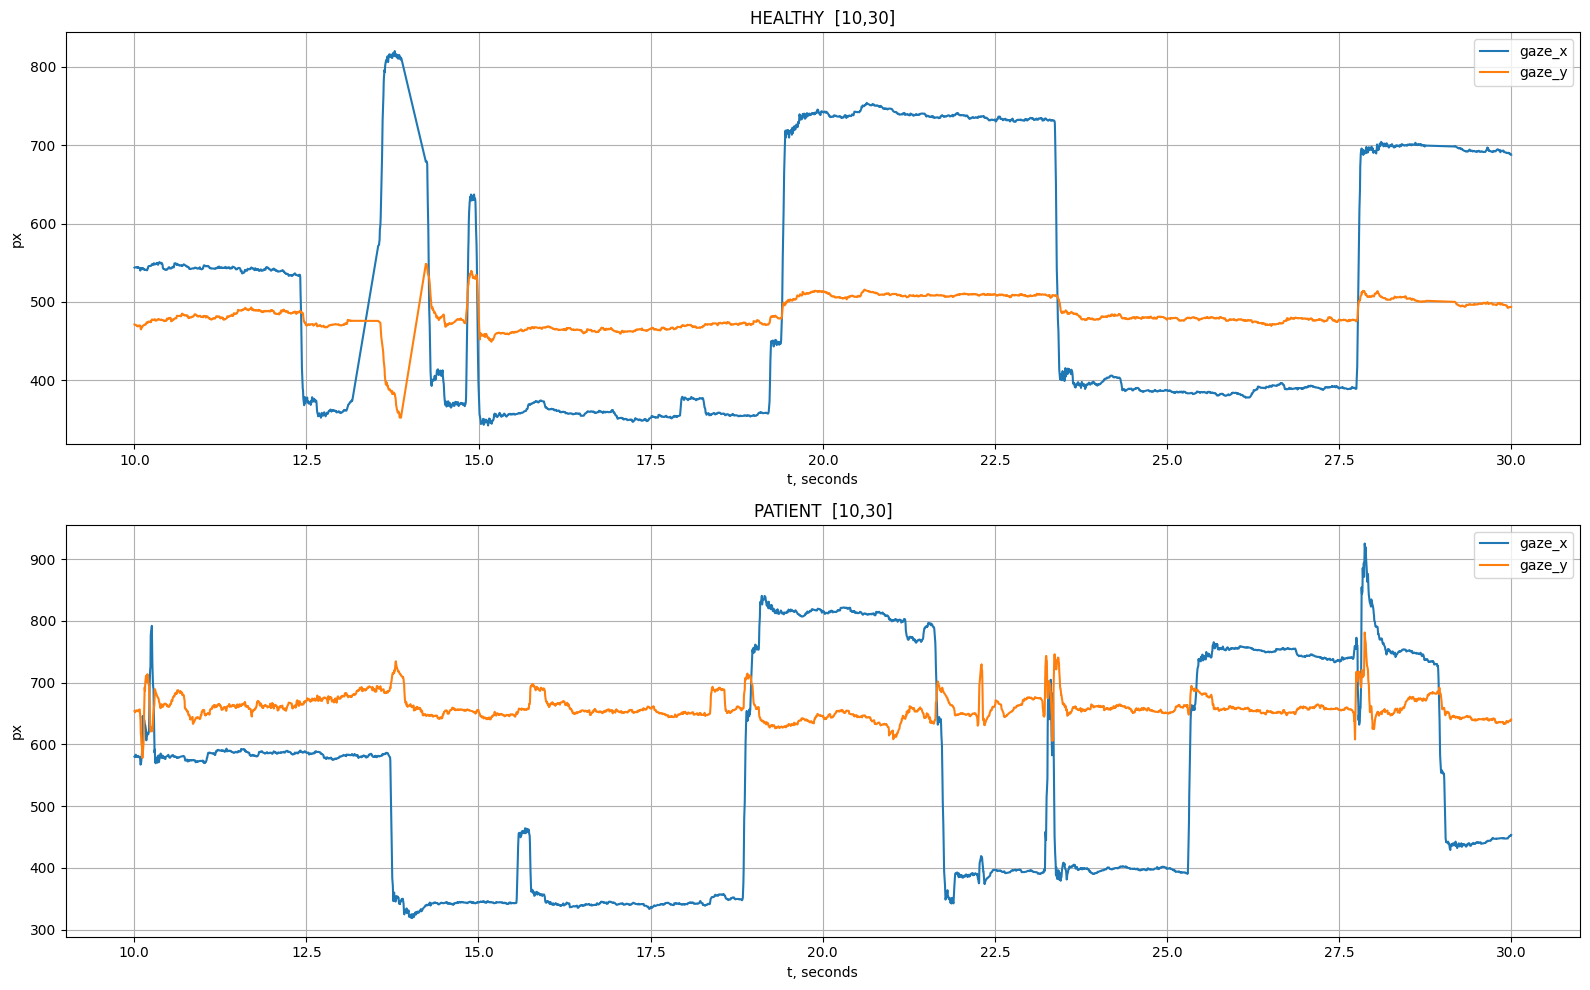

In [ ]:
def plot_gaze_timeline_with_events(rec: dict, t0: float, t1: float, title: str = ""):
    """
    График как plot_gaze_timeline, но:
      - добавляем события вертикальными линиями и подписью name
    """
    gaze = rec["gaze"].copy()
    events = rec["events"].copy()

    seg = gaze[(gaze["t_s"]>=t0) & (gaze["t_s"]<=t1)]
    seg = seg[gaze_valid_mask(seg)]

    plt.plot(seg["t_s"], seg["gaze x [px]"], label="gaze_x")
    plt.plot(seg["t_s"], seg["gaze y [px]"], label="gaze_y")

    # события
    ev = events[(events["t_s"]>=t0) & (events["t_s"]<=t1)]
    # чтобы не было 500 линий — ограничим до "важных": BLOCK и trial start/end
    keep = ev["name"].str.contains("_BLOCK_|\\d+\\.\\d+_.*_(start|end)$|CALIB_BLOCK", regex=True, na=False)
    ev = ev[keep].copy()

    # подписи: можно ещё урезать, если слишком много
    for _, r in ev.iterrows():
        x = float(r["t_s"])
        plt.axvline(x=x, linewidth=1)
        plt.text(x, plt.ylim()[1], str(r["name"])[:25], rotation=90, va="top", fontsize=8)

    plt.title(title)
    plt.xlabel("t, seconds")
    plt.ylabel("px")
    plt.grid(True)
    plt.legend()

def plot_two_timelines(healthy_rec_folder: Path, patient_rec_folder: Path, t0=0.0, t1=30.0):
    """
    Два графика друг под другом: healthy сверху, patient снизу.
    """
    rec_h = normalize_time(load_recording(healthy_rec_folder))
    rec_p = normalize_time(load_recording(patient_rec_folder))

    plt.figure(figsize=(16, 10))

    plt.subplot(2,1,1)
    plot_gaze_timeline_with_events(rec_h, t0, t1, title=f"HEALTHY  [{t0},{t1}]")

    plt.subplot(2,1,2)
    plot_gaze_timeline_with_events(rec_p, t0, t1, title=f"PATIENT  [{t0},{t1}]")

    plt.tight_layout()
    plt.show()

# === Как выбрать кого рисовать ===
# 1) Найти любой healthy recording_folder
healthy_candidates = dataset_index[dataset_index["label_text"]=="healthy"]["recording_folder"].tolist()
patient_candidates = dataset_index[dataset_index["label_text"]=="patient"]["recording_folder"].tolist()

print("healthy candidates:", len(healthy_candidates))
print("patient candidates:", len(patient_candidates))

# 2) Укажи конкретные индексы:
if healthy_candidates and patient_candidates:
    plot_two_timelines(Path(healthy_candidates[0]), Path(patient_candidates[0]), t0=10, t1=30)

In [ ]:
"""
CELL 10A — Timeline alignment by event anchor (без видео)

Идея:
- вместо t0..t1 в абсолютных секундах
- берем событие-якорь (по имени или по regex)
- и строим окно вокруг него в относительном времени (t_rel = t - t_anchor)
- так можно честно сравнивать записи разных людей
"""

import re

def find_anchor_time(events: pd.DataFrame, anchor: str, mode: str = "exact", nth: int = 1) -> float:
    """
    Находит время якоря t_anchor (в секундах) в events.

    mode:
      - "exact": name == anchor
      - "regex": name matches regex anchor

    nth:
      - 1 = первое совпадение
      - 2 = второе совпадение, и т.д.
    """
    ev = events.sort_values("t_s").copy()
    if mode == "exact":
        m = ev[ev["name"] == anchor]
    elif mode == "regex":
        rx = re.compile(anchor)
        m = ev[ev["name"].astype(str).apply(lambda s: bool(rx.search(s)))]
    else:
        raise ValueError("mode must be 'exact' or 'regex'")

    if len(m) < nth:
        raise ValueError(f"Anchor not found enough times: anchor={anchor}, mode={mode}, nth={nth}, found={len(m)}")
    return float(m.iloc[nth-1]["t_s"])


def plot_aligned_timeline_with_events(rec: dict,
                                      anchor: str,
                                      mode: str,
                                      nth: int,
                                      window: tuple[float, float],
                                      title: str):
    """
    Строит gaze_x/y относительно anchor event.
    window = (t_rel_start, t_rel_end) например (-2, 8)

    На графике:
    - gaze_x/gaze_y vs t_rel
    - события в окне -> вертикальные линии с подписями
    """
    gaze = rec["gaze"].copy()
    events = rec["events"].copy()

    t_anchor = find_anchor_time(events, anchor, mode=mode, nth=nth)
    gaze["t_rel"] = gaze["t_s"] - t_anchor
    events["t_rel"] = events["t_s"] - t_anchor

    t0, t1 = window

    seg = gaze[(gaze["t_rel"] >= t0) & (gaze["t_rel"] <= t1)].copy()
    seg = seg[gaze_valid_mask(seg)]

    plt.plot(seg["t_rel"], seg["gaze x [px]"], label="gaze_x")
    plt.plot(seg["t_rel"], seg["gaze y [px]"], label="gaze_y")

    # события: не все подряд, чтобы не зашумить
    ev = events[(events["t_rel"] >= t0) & (events["t_rel"] <= t1)].copy()
    keep = ev["name"].str.contains("_BLOCK_|\\d+\\.\\d+_.*_(start|end)$|CALIB_BLOCK", regex=True, na=False)
    ev = ev[keep]

    for _, r in ev.iterrows():
        x = float(r["t_rel"])
        plt.axvline(x=x, linewidth=1)
        plt.text(x, plt.ylim()[1], str(r["name"])[:25], rotation=90, va="top", fontsize=8)

    plt.axvline(0.0, linewidth=2)  # сам якорь
    plt.title(title + f"\nanchor={anchor}, mode={mode}, nth={nth}")
    plt.xlabel("t_rel, seconds (0 = anchor)")
    plt.ylabel("px")
    plt.grid(True)
    plt.legend()

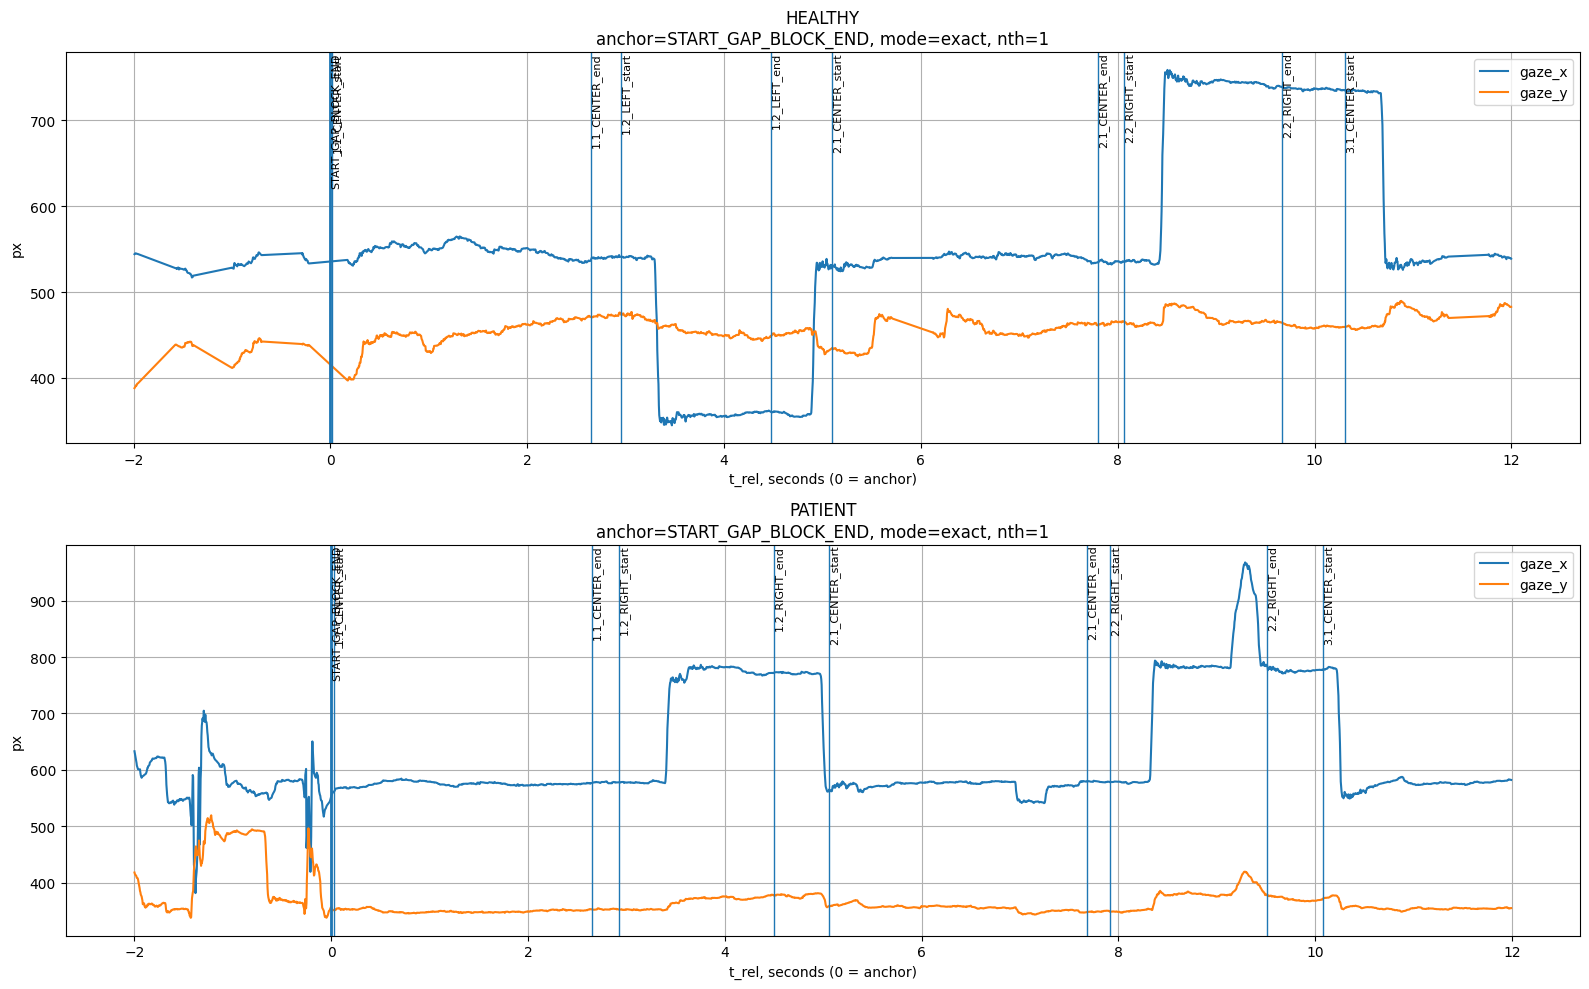

In [ ]:
"""
CELL 10B — Plot healthy vs patient aligned by the same anchor event

Ты задаешь:
- anchor (exact или regex)
- окно (например -2..+8 секунд)
И получаешь сопоставимые картинки.
"""

def plot_two_timelines_aligned(healthy_rec_folder: Path,
                               patient_rec_folder: Path,
                               anchor: str,
                               mode: str = "exact",
                               nth_healthy: int = 1,
                               nth_patient: int = 1,
                               window: tuple[float, float] = (-2, 8)):
    rec_h = normalize_time(load_recording(healthy_rec_folder))
    rec_p = normalize_time(load_recording(patient_rec_folder))

    plt.figure(figsize=(16, 10))

    plt.subplot(2,1,1)
    plot_aligned_timeline_with_events(
        rec_h, anchor=anchor, mode=mode, nth=nth_healthy, window=window,
        title=f"HEALTHY"
    )

    plt.subplot(2,1,2)
    plot_aligned_timeline_with_events(
        rec_p, anchor=anchor, mode=mode, nth=nth_patient, window=window,
        title=f"PATIENT"
    )

    plt.tight_layout()
    plt.show()


# Пример: выравниваем по "началу trials в GAP" (обычно START_GAP_BLOCK_END)
healthy_candidates = dataset_index[dataset_index["label_text"]=="healthy"]["recording_folder"].tolist()
patient_candidates = dataset_index[dataset_index["label_text"]=="patient"]["recording_folder"].tolist()

if healthy_candidates and patient_candidates:
    plot_two_timelines_aligned(
        Path(healthy_candidates[0]),
        Path(patient_candidates[1]),
        anchor="START_GAP_BLOCK_END",
        mode="exact",
        window=(-2, 12)
    )

## Кластеризация по фичам + визуализация

Здесь логика такая:

делаем feature table на уровне recording (самая устойчивая для 6+2)

объединяем:

subject_qc_df (QC)

block_summary_df (агрегаты по блокам) в wide-формат

дальше:

стандартизация

PCA 2D

KMeans (k=2)

смотрим “как совпало” с label_text

In [ ]:
"""
CELL S5-2 — Total number of columns in raw data (no video)

Считает:
- columns_sum: сумма числа столбцов по всем CSV (по одному "эталонному" файлу каждого типа)
- columns_unique: число уникальных названий колонок, встречающихся во всех CSV
- плюс таблица: файл -> колонки
"""

import pandas as pd
from pathlib import Path

def read_columns(folder: Path, fname: str) -> list[str]:
    p = folder / fname
    if not p.exists():
        return []
    try:
        df = pd.read_csv(p, nrows=5)  # достаточно, чтобы прочитать header
        return list(df.columns)
    except:
        return []

# возьмём первую запись как "эталон" структуры (обычно одинаковая для всех)
ref_folder = Path(dataset_index.iloc[0]["recording_folder"])

file_cols = []
all_cols = []

for f in CSV_FILES:
    cols = read_columns(ref_folder, f)
    file_cols.append({"file": f, "n_columns": len(cols), "columns": ", ".join(cols)})
    all_cols.extend(cols)

file_cols_df = pd.DataFrame(file_cols)
columns_sum = int(file_cols_df["n_columns"].sum())
columns_unique = int(len(set(all_cols)))

display(file_cols_df[["file","n_columns"]])

print("TOTAL columns (sum over files):", columns_sum)
print("TOTAL unique column names (union):", columns_unique)

# Если хочешь на слайд красиво: 1 строка со значениями
cols_summary = pd.DataFrame([{
    "columns_sum_over_files": columns_sum,
    "unique_column_names_union": columns_unique
}])
display(cols_summary)

,file,n_columns
0,gaze.csv,10
1,events.csv,4
2,fixations.csv,10
3,saccades.csv,10
4,blinks.csv,6
5,imu.csv,16
6,world_timestamps.csv,3


TOTAL columns (sum over files): 59
TOTAL unique column names (union): 35


,columns_sum_over_files,unique_column_names_union
0,59,35


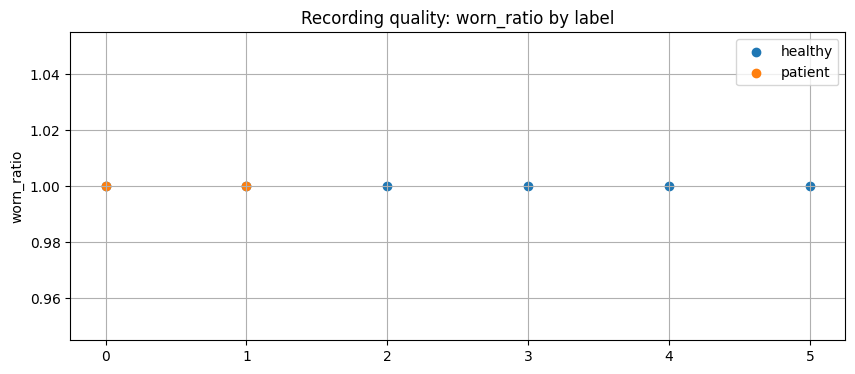

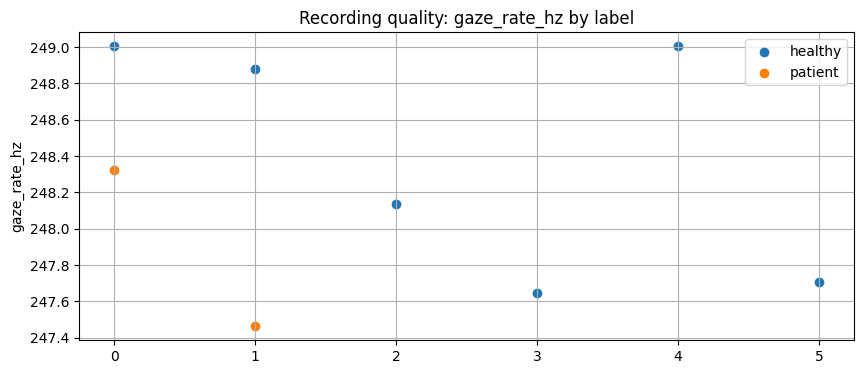

,label_text,n_recordings,worn_ratio_median,gaze_rate_hz_median,qc_low_worn,qc_low_rate,qc_high_motion
0,healthy,6,1.0,248.509499,0,0,0
1,patient,2,1.0,247.893657,0,0,0


In [ ]:
# CELL S5-4 — Quality metrics plots (no video)
# Строим:
# 1) worn_ratio (точки по записям)
# 2) gaze_rate_hz (точки по записям)
# + выводим медианы и сколько QC флагов

import numpy as np
import matplotlib.pyplot as plt

def scatter_by_label(df: pd.DataFrame, y_col: str, title: str):
    plt.figure(figsize=(10,4))
    # фиксируем порядок лейблов для стабильного вида
    order = [x for x in ["healthy","patient","unknown"] if x in df["label_text"].unique()]
    for lt in order:
        sub = df[df["label_text"]==lt].copy()
        # x — просто индекс внутри группы, чтобы точки не наслаивались
        plt.scatter(range(len(sub)), sub[y_col], label=f"{lt}")
    plt.title(title)
    plt.ylabel(y_col)
    plt.grid(True)
    plt.legend()
    plt.show()

# 1) графики
scatter_by_label(subject_qc_df, "worn_ratio", "Recording quality: worn_ratio by label")
scatter_by_label(subject_qc_df, "gaze_rate_hz", "Recording quality: gaze_rate_hz by label")

# 2) числа для слайда
qc_stats = subject_qc_df.groupby("label_text").agg(
    n_recordings=("recording_id","count"),
    worn_ratio_median=("worn_ratio","median"),
    gaze_rate_hz_median=("gaze_rate_hz","median"),
    qc_low_worn=("qc_flag_low_worn","sum"),
    qc_low_rate=("qc_flag_low_rate","sum"),
    qc_high_motion=("qc_flag_high_motion","sum"),
).reset_index()

display(qc_stats)

In [ ]:
# CELL S8-1 — pick a recording & one trial to демонстрировать расчёт

# 1) Выберем пример: первый healthy, первый блок GAP или PREDICTION
ex_row = dataset_index[dataset_index["label_text"]=="healthy"].iloc[0]
folder = Path(ex_row["recording_folder"])

rec_ex = normalize_time(load_recording(folder))
bw_ex = infer_block_windows(rec_ex["events"])
pe_ex = parse_trial_events(rec_ex["events"], bw_ex)

# 2) Возьмём trial_metrics по одному блоку
block_for_demo = "GAP"  # можно "PREDICTION" / "OVERLAP"
tm_demo = compute_trial_metrics_for_block(rec_ex, pe_ex, block_for_demo, CFG)

display(tm_demo.head(10))

# 3) Выбираем первый trial, где RT найден
trial_id_demo = tm_demo[tm_demo["rt_found"]==1]["trial_id"].iloc[0]
row_demo = tm_demo[tm_demo["trial_id"]==trial_id_demo].iloc[0].to_dict()

row_demo

,recording_id,block,trial_id,onset_s,target_side,qc_trial_valid,rt_found,rt_gaze_ms,response_dir,rt_saccade_found,...,target_reached,time_to_target_ms,post_response_dx_px,accuracy_sector,fix_dur_ms_mean_trial,fix_dur_ms_median_trial,n_large_jumps_to_target,n_steps_to_target,trial_duration_ms,time_to_target_share
0,2025-11-10_17-32-11-c567dcb6,GAP,1,339.469103,LEFT,1,1,364.843274,LEFT,1,...,1,364.843274,-185.3190,1,2382.000000,2382.0,0,0,1523.539,0.239471
1,2025-11-10_17-32-11-c567dcb6,GAP,2,344.586524,RIGHT,1,1,383.392274,RIGHT,1,...,1,383.392274,211.4685,1,1814.666667,2184.0,0,0,1605.825,0.238751
2,2025-11-10_17-32-11-c567dcb6,GAP,3,349.779034,LEFT,1,1,486.919274,LEFT,1,...,1,486.919274,-182.2695,1,1707.000000,1978.0,0,0,1637.951,0.297273
3,2025-11-10_17-32-11-c567dcb6,GAP,4,354.932989,LEFT,1,1,356.989274,LEFT,1,...,1,356.989274,-166.9350,1,1309.600000,1840.0,0,0,1594.424,0.223899
4,2025-11-10_17-32-11-c567dcb6,GAP,5,360.050588,LEFT,1,1,359.341274,LEFT,1,...,1,359.341274,-182.6880,1,1333.600000,840.0,0,0,1594.840,0.225315
5,2025-11-10_17-32-11-c567dcb6,GAP,6,365.169058,LEFT,1,1,368.897274,LEFT,1,...,1,368.897274,-186.2560,1,1064.000000,840.0,0,0,1607.571,0.229475
6,2025-11-10_17-32-11-c567dcb6,GAP,7,370.394243,LEFT,1,1,80.247274,LEFT,1,...,1,67.671274,-163.2145,1,1000.800000,420.0,0,0,1552.068,0.043601
7,2025-11-10_17-32-11-c567dcb6,GAP,8,375.411133,RIGHT,1,1,302.818274,RIGHT,1,...,1,302.818274,213.8270,1,927.200000,448.0,0,0,1552.954,0.194995
8,2025-11-10_17-32-11-c567dcb6,GAP,9,380.425306,LEFT,1,1,220.651274,LEFT,1,...,1,220.651274,-168.6240,1,2014.666667,1836.0,0,0,1528.571,0.144351
9,2025-11-10_17-32-11-c567dcb6,GAP,10,385.546083,LEFT,1,1,231.921274,LEFT,1,...,1,231.921274,-167.6215,1,1598.666667,1632.0,0,0,1525.050,0.152075


{'recording_id': '2025-11-10_17-32-11-c567dcb6',
 'block': 'GAP',
 'trial_id': 1,
 'onset_s': 339.469103,
 'target_side': 'LEFT',
 'qc_trial_valid': 1,
 'rt_found': 1,
 'rt_gaze_ms': 364.84327400000893,
 'response_dir': 'LEFT',
 'rt_saccade_found': 1,
 'rt_saccade_ms': 344.84027399997785,
 'direction_error': 0,
 'express_like': 0,
 'target_reached': 1,
 'time_to_target_ms': 364.84327400000893,
 'post_response_dx_px': -185.31899999999996,
 'accuracy_sector': 1,
 'fix_dur_ms_mean_trial': 2382.0,
 'fix_dur_ms_median_trial': 2382.0,
 'n_large_jumps_to_target': 0,
 'n_steps_to_target': 0,
 'trial_duration_ms': 1523.538999999971,
 'time_to_target_share': 0.23947091213288}

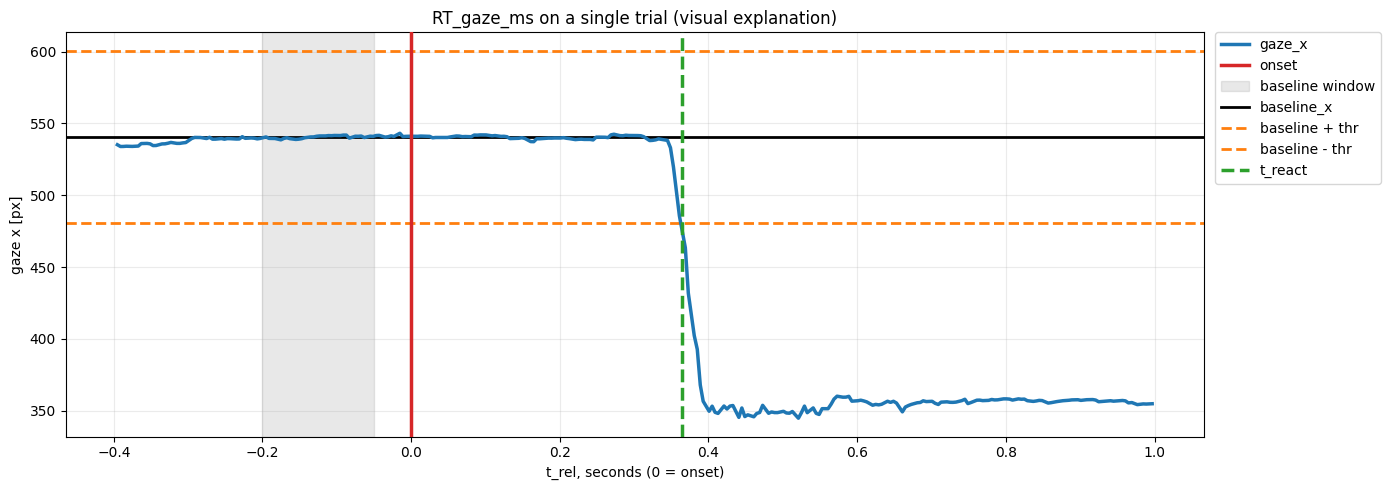

RT found: 1
RT_gaze_ms: 364.84327400000893
response_dir: LEFT
thr_px: 60


In [ ]:
# CELL S8-2 (updated) — readable RT detection plot

def plot_trial_rt_demo(rec: dict, onset_s: float, window=(-0.4, 1.0), cfg=CFG):
    gaze = rec["gaze"].copy()
    gaze = gaze[gaze_valid_mask(gaze)]

    # считаем RT, чтобы получить baseline_x и thr
    rt = gaze_based_rt(rec, onset_s, cfg)
    thr_px = rt["thr_px"]
    baseline_x = rt["baseline_x"]
    rt_s = rt["rt_s"]

    # окно вокруг onset
    t0, t1 = window
    seg = gaze[(gaze["t_s"]>=onset_s+t0) & (gaze["t_s"]<=onset_s+t1)].copy()
    seg["t_rel"] = seg["t_s"] - onset_s

    plt.figure(figsize=(14,5))

    # Основной сигнал — gaze_x (делаем жирной линией)
    plt.plot(
        seg["t_rel"], seg["gaze x [px]"],
        label="gaze_x", linewidth=2.5, color="tab:blue", zorder=3
    )

    # Onset (вертикаль)
    plt.axvline(0.0, linewidth=2.5, color="tab:red", label="onset", zorder=4)

    # Baseline window (полупрозрачная зона)
    plt.axvspan(-0.20, -0.05, alpha=0.18, color="gray", label="baseline window", zorder=1)

    # Baseline и пороги (горизонтали)
    if not np.isnan(baseline_x):
        plt.axhline(baseline_x, linewidth=2, color="black", label="baseline_x", zorder=2)
        plt.axhline(baseline_x + thr_px, linewidth=2, color="tab:orange",
                    linestyle="--", label="baseline + thr", zorder=2)
        plt.axhline(baseline_x - thr_px, linewidth=2, color="tab:orange",
                    linestyle="--", label="baseline - thr", zorder=2)

    # Реакция (если найдена)
    if rt_s is not None:
        plt.axvline(rt_s - onset_s, linewidth=2.5, color="tab:green",
                    linestyle="--", label="t_react", zorder=4)

    plt.title("RT_gaze_ms on a single trial (visual explanation)")
    plt.xlabel("t_rel, seconds (0 = onset)")
    plt.ylabel("gaze x [px]")
    plt.grid(True, alpha=0.25)

    # Легенду лучше вынести, чтобы не перекрывала график
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.)
    plt.tight_layout()
    plt.show()

    print("RT found:", rt["rt_found"])
    print("RT_gaze_ms:", rt["rt_gaze_ms"])
    print("response_dir:", rt["response_dir"])
    print("thr_px:", thr_px)

plot_trial_rt_demo(rec_ex, onset_s=row_demo["onset_s"], window=(-0.4, 1.0), cfg=CFG)

In [ ]:
# CELL S8-2A — Slide mode RT demo (clean, readable, presentation-ready)

def plot_trial_rt_demo_slide(rec: dict,
                             onset_s: float,
                             window=(-0.35, 0.9),
                             cfg=CFG,
                             title="RT_gaze_ms: how we detect reaction",
                             subtitle=None,
                             save_path: str | None = None):
    """
    Слайдовый график:
      - только gaze_x
      - onset (красный)
      - baseline window (серый прямоугольник)
      - baseline (черный) + thresholds (оранжевый пунктир)
      - t_react (зеленый пунктир) + RT подпись
      - без легенды, с аннотациями на графике

    save_path: если указать, сохранит png/pdf.
    """
    gaze = rec["gaze"].copy()
    gaze = gaze[gaze_valid_mask(gaze)]

    rt = gaze_based_rt(rec, onset_s, cfg)
    thr_px = rt["thr_px"]
    baseline_x = rt["baseline_x"]
    rt_s = rt["rt_s"]
    rt_ms = rt["rt_gaze_ms"]
    response_dir = rt["response_dir"]

    t0, t1 = window
    seg = gaze[(gaze["t_s"]>=onset_s+t0) & (gaze["t_s"]<=onset_s+t1)].copy()
    seg["t_rel"] = seg["t_s"] - onset_s

    # --- Plot ---
    plt.figure(figsize=(13.5, 4.8))

    # Основной сигнал
    plt.plot(seg["t_rel"], seg["gaze x [px]"], linewidth=3, color="tab:blue")

    # Onset
    plt.axvline(0.0, linewidth=3, color="tab:red")

    # Baseline window
    plt.axvspan(-0.20, -0.05, color="gray", alpha=0.18)

    # Baseline & thresholds
    if not np.isnan(baseline_x):
        plt.axhline(baseline_x, linewidth=2.5, color="black")
        plt.axhline(baseline_x + thr_px, linewidth=2.5, color="tab:orange", linestyle="--")
        plt.axhline(baseline_x - thr_px, linewidth=2.5, color="tab:orange", linestyle="--")

    # Reaction time marker
    if rt_s is not None:
        plt.axvline(rt_s - onset_s, linewidth=3, color="tab:green", linestyle="--")

    # --- Styling ---
    plt.grid(True, alpha=0.18)
    plt.xlabel("Time relative to onset, s", fontsize=13)
    plt.ylabel("Gaze X, px", fontsize=13)
    plt.title(title, fontsize=16, pad=12)

    if subtitle is None:
        subtitle = f"baseline: [-200..-50] ms | threshold: ±{thr_px:.0f}px | hold: {cfg['hold_ms_reaction']}ms"
    plt.text(0.0, 1.02, subtitle, transform=plt.gca().transAxes, fontsize=12, color="dimgray")

    ax = plt.gca()
    ymin, ymax = ax.get_ylim()
    xmin, xmax = ax.get_xlim()

    # --- Annotations (with white background for readability) ---
    bbox = dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.9)

    # Onset label
    plt.annotate(
        "onset\n(stimulus)",
        xy=(0.0, ymax),
        xytext=(0.02*(xmax-xmin), ymax - 0.08*(ymax-ymin)),
        textcoords="data",
        fontsize=12,
        color="tab:red",
        bbox=bbox,
        arrowprops=dict(arrowstyle="->", lw=2, color="tab:red"),
    )

    # Threshold label
    if not np.isnan(baseline_x):
        plt.annotate(
            "reaction threshold",
            xy=(xmin + 0.55*(xmax-xmin), baseline_x + thr_px),
            xytext=(xmin + 0.55*(xmax-xmin), baseline_x + thr_px + 0.12*(ymax-ymin)),
            fontsize=12,
            color="tab:orange",
            bbox=bbox,
            arrowprops=dict(arrowstyle="->", lw=2, color="tab:orange"),
        )

    # RT label
    if rt_s is not None:
        txt = f"t_react\nRT = {rt_ms:.0f} ms\n(dir: {response_dir})"
        plt.annotate(
            txt,
            xy=(rt_s - onset_s, ymax - 0.02*(ymax-ymin)),
            xytext=(rt_s - onset_s + 0.08*(xmax-xmin), ymax - 0.28*(ymax-ymin)),
            fontsize=12,
            color="tab:green",
            bbox=bbox,
            arrowprops=dict(arrowstyle="->", lw=2, color="tab:green"),
        )
    else:
        plt.text(0.62, 0.15, "No stable reaction detected in window", transform=ax.transAxes,
                 fontsize=12, bbox=bbox, color="black")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

    # print summary for notes
    print("RT found:", rt["rt_found"], "| RT_gaze_ms:", rt["rt_gaze_ms"], "| response_dir:", rt["response_dir"], "| thr_px:", thr_px)

Saved: s8_rt_demo.png


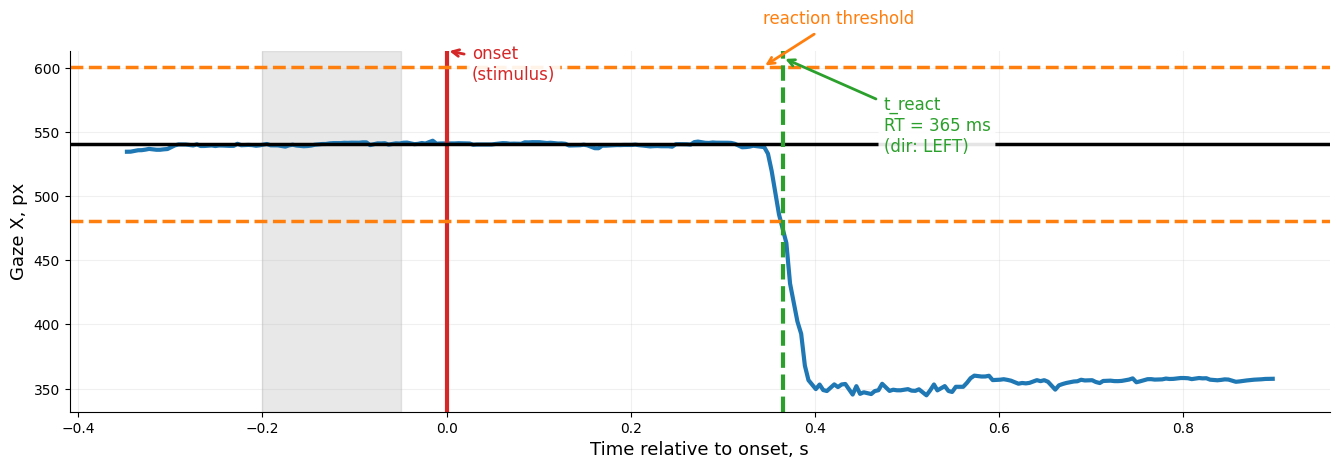

RT found: 1 | RT_gaze_ms: 364.84327400000893 | response_dir: LEFT | thr_px: 60


In [ ]:
# CELL S8-2B — run slide plot for the chosen demo trial

plot_trial_rt_demo_slide(
    rec_ex,
    onset_s=row_demo["onset_s"],
    window=(-0.35, 0.9),
    cfg=CFG,
    title="",
    subtitle="",
    save_path="s8_rt_demo.png"
)

Сохранено: s8_rt_demo_ru.png


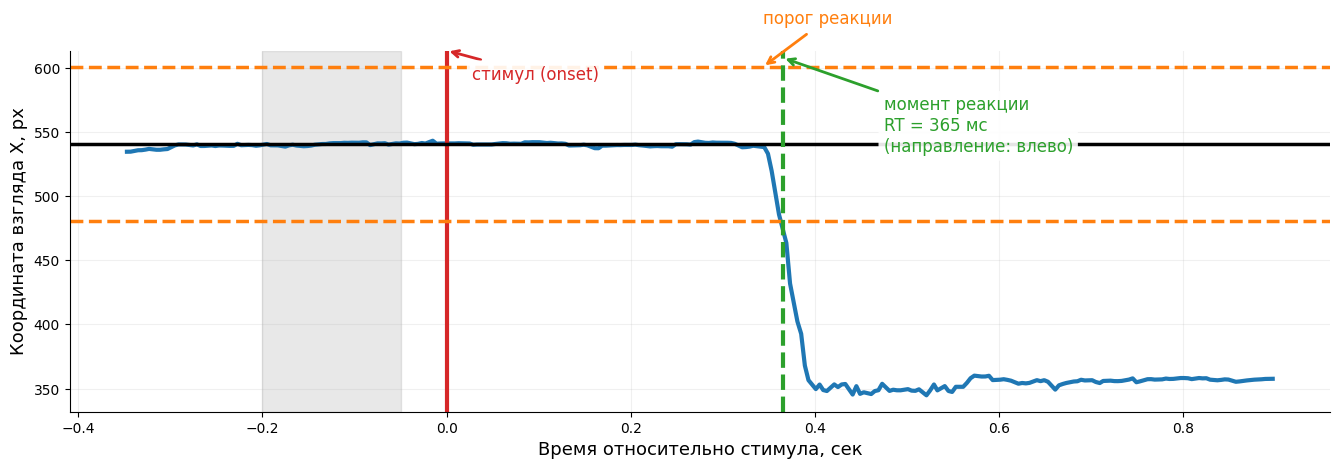

RT найден: 1 | RT_gaze_ms: 364.84327400000893 | направление: LEFT | порог px: 60


In [ ]:
# CELL S8-2B (RU) — запуск слайдового графика для demo trial

plot_trial_rt_demo_slide_ru(
    rec_ex,
    onset_s=row_demo["onset_s"],
    window=(-0.35, 0.9),
    cfg=CFG,
    title="",
    subtitle="",
    save_path="s8_rt_demo_ru.png"
)

In [ ]:
# CELL S9-1 — Advanced metrics per recording (based on trial_metrics_df + saccades.csv)

import numpy as np
import pandas as pd

def safe_iqr(x: pd.Series) -> float:
    x = x.dropna()
    if len(x) < 5:
        return np.nan
    return float(x.quantile(0.75) - x.quantile(0.25))

def safe_cv(x: pd.Series) -> float:
    x = x.dropna()
    if len(x) < 5:
        return np.nan
    m = float(x.mean())
    s = float(x.std())
    return float(s / m) if m != 0 else np.nan

def fit_main_sequence_for_recording(recording_folder: str) -> dict:
    """
    Main sequence: peak velocity vs amplitude, линейная регрессия (без sklearn).
    Возвращает slope/intercept/R2.
    """
    folder = Path(recording_folder)
    sac_path = folder / "saccades.csv"
    if not sac_path.exists():
        return {"mainseq_slope": np.nan, "mainseq_intercept": np.nan, "mainseq_r2": np.nan, "mainseq_n": 0}

    sac = pd.read_csv(sac_path)
    # нужен amplitude [deg] и peak velocity [px/s] (как в ваших файлах)
    if "amplitude [deg]" not in sac.columns or "peak velocity [px/s]" not in sac.columns:
        return {"mainseq_slope": np.nan, "mainseq_intercept": np.nan, "mainseq_r2": np.nan, "mainseq_n": 0}

    x = sac["amplitude [deg]"].astype(float)
    y = sac["peak velocity [px/s]"].astype(float)
    m = x.notna() & y.notna()
    x = x[m].values
    y = y[m].values

    if len(x) < 20:
        return {"mainseq_slope": np.nan, "mainseq_intercept": np.nan, "mainseq_r2": np.nan, "mainseq_n": int(len(x))}

    # y = a*x + b
    a, b = np.polyfit(x, y, 1)
    y_hat = a*x + b
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    return {"mainseq_slope": float(a), "mainseq_intercept": float(b), "mainseq_r2": float(r2), "mainseq_n": int(len(x))}


def build_advanced_recording_features(trial_metrics_df: pd.DataFrame,
                                     subject_qc_df: pd.DataFrame,
                                     dataset_index: pd.DataFrame) -> pd.DataFrame:
    """
    Возвращает df: 1 строка на recording_id
    Включает:
      - gap_overlap_delta_rt_ms (из block_summary можно, но пересчитаем из trial_metrics для прозрачности)
      - IQR/CV RT для GAP и OVERLAP
      - IQR/CV RT для PREDICTION (опционально)
      - decision_accuracy и decision_rt (если есть)
      - main sequence params (slope/intercept/R2)
    """
    # базовая таблица (label + путь к папке)
    base = dataset_index[["recording_id","recording_folder","label","label_text","zip_name","zip_stem"]].drop_duplicates()

    tm = trial_metrics_df.copy()

    # RT по блокам
    rt = tm[tm["rt_found"]==1].copy()
    # GAP / OVERLAP
    feats = []
    for rid, g in rt.groupby("recording_id"):
        row = {"recording_id": rid}

        def block_series(block):
            return g[g["block"]==block]["rt_gaze_ms"]

        # медианы
        med_gap = block_series("GAP").median()
        med_ov  = block_series("OVERLAP").median()
        row["rt_gap_median"] = float(med_gap) if pd.notna(med_gap) else np.nan
        row["rt_overlap_median"] = float(med_ov) if pd.notna(med_ov) else np.nan
        row["gap_overlap_delta_rt_ms"] = row["rt_overlap_median"] - row["rt_gap_median"]

        # вариативность
        row["rt_gap_iqr_ms"] = safe_iqr(block_series("GAP"))
        row["rt_overlap_iqr_ms"] = safe_iqr(block_series("OVERLAP"))
        row["rt_gap_cv"] = safe_cv(block_series("GAP"))
        row["rt_overlap_cv"] = safe_cv(block_series("OVERLAP"))

        # direction_error contrast (если есть)
        if "direction_error" in tm.columns:
            de_gap = tm[(tm["recording_id"]==rid) & (tm["block"]=="GAP")]["direction_error"]
            de_ov  = tm[(tm["recording_id"]==rid) & (tm["block"]=="OVERLAP")]["direction_error"]
            row["direction_error_gap"] = float(de_gap.mean()) if de_gap.notna().any() else np.nan
            row["direction_error_overlap"] = float(de_ov.mean()) if de_ov.notna().any() else np.nan
            row["gap_overlap_delta_direction_error"] = row["direction_error_overlap"] - row["direction_error_gap"]
        else:
            row["gap_overlap_delta_direction_error"] = np.nan

        feats.append(row)

    feats_df = pd.DataFrame(feats)

    # Decision метрики (если есть)
    if "decision_correct" in tm.columns:
        dec = tm[tm["block"]=="DECISION"].copy()
        dec_agg = dec.groupby("recording_id").agg(
            decision_accuracy=("decision_correct", "mean"),
            decision_rt_ms=("decision_rt_gaze_ms", "median"),
        ).reset_index()
    else:
        dec_agg = pd.DataFrame(columns=["recording_id","decision_accuracy","decision_rt_ms"])

    # QC добавим (blink_rate_per_min, worn_ratio, gaze_rate_hz — для интерпретации)
    qc_keep = subject_qc_df[["recording_id","worn_ratio","gaze_rate_hz","blink_rate_per_min","qc_flag_low_worn","qc_flag_low_rate","qc_flag_high_motion"]].copy()

    # Main sequence (по каждому recording_folder)
    ms_rows = []
    for _, r in base.iterrows():
        ms = fit_main_sequence_for_recording(r["recording_folder"])
        ms["recording_id"] = r["recording_id"]
        ms_rows.append(ms)
    ms_df = pd.DataFrame(ms_rows)

    out = base.merge(feats_df, on="recording_id", how="left") \
              .merge(dec_agg, on="recording_id", how="left") \
              .merge(qc_keep, on="recording_id", how="left") \
              .merge(ms_df, on="recording_id", how="left")

    return out


adv_rec_df = build_advanced_recording_features(trial_metrics_df, subject_qc_df, dataset_index)
display(adv_rec_df)

,recording_id,recording_folder,label,label_text,zip_name,zip_stem,rt_gap_median,rt_overlap_median,gap_overlap_delta_rt_ms,rt_gap_iqr_ms,...,worn_ratio,gaze_rate_hz,blink_rate_per_min,qc_flag_low_worn,qc_flag_low_rate,qc_flag_high_motion,mainseq_slope,mainseq_intercept,mainseq_r2,mainseq_n
0,2025-11-10_17-32-11-c567dcb6,/content/neon_workdir/HC_001/2025-11-10_17-32-...,0,healthy,HC_001.zip,HC_001,331.948274,366.648274,34.7000,128.92900,...,1.0,249.003984,39.155882,0,0,0,113.282060,4094.258451,0.065053,995
1,2025-12-22_15-21-53-5007559b,/content/neon_workdir/HC_002/2025-12-22_15-21-...,0,healthy,HC_002.zip,HC_002,228.973334,365.829334,136.8560,184.32600,...,1.0,248.880040,NaN,0,0,0,311.051287,1285.133365,0.658102,764
2,2025-12-22_15-49-23-4e211ab0,/content/neon_workdir/HC_003/2025-12-22_15-49-...,0,healthy,HC_003.zip,HC_003,359.380568,412.540568,53.1600,116.20150,...,1.0,248.138958,NaN,0,0,0,-31.832906,5361.835490,0.003389,631
3,2025-12-22_15-36-14-5ae0d89d,/content/neon_workdir/HC_004/2025-12-22_15-36-...,0,healthy,HC_004.zip,HC_004,338.740298,368.968298,30.2280,82.42400,...,1.0,247.647350,NaN,0,0,0,228.184840,2503.142586,0.263981,650
4,2025-12-22_16-02-47-6f17655e,/content/neon_workdir/HC_005/2025-12-22_16-02-...,0,healthy,HC_005.zip,HC_005,281.683510,357.652510,75.9690,84.59400,...,1.0,249.003984,NaN,0,0,0,190.985410,2679.981314,0.177302,464
5,2026-01-07_14-37-02-7649719b,/content/neon_workdir/HC_006/2026-01-07_14-37-...,0,healthy,HC_006.zip,HC_006,227.803971,322.406471,94.6025,144.80025,...,1.0,247.708695,NaN,0,0,0,193.724724,3012.543656,0.473196,383
6,мультиситемная_атрофия-2bcec8bf,/content/neon_workdir/PAT_001/мультиситемная_а...,1,patient,PAT_001.zip,PAT_001,188.440850,276.846350,88.4055,103.57450,...,1.0,248.323814,NaN,0,0,0,250.602033,2512.254553,0.360444,1028
7,болезнь_парксинсона_смешанная_форма_3_стадия-e...,/content/neon_workdir/PAT_002/болезнь_парксинс...,1,patient,PAT_002.zip,PAT_002,292.231515,521.004515,228.7730,147.01900,...,1.0,247.463499,NaN,0,0,0,185.823256,2653.056326,0.231098,841


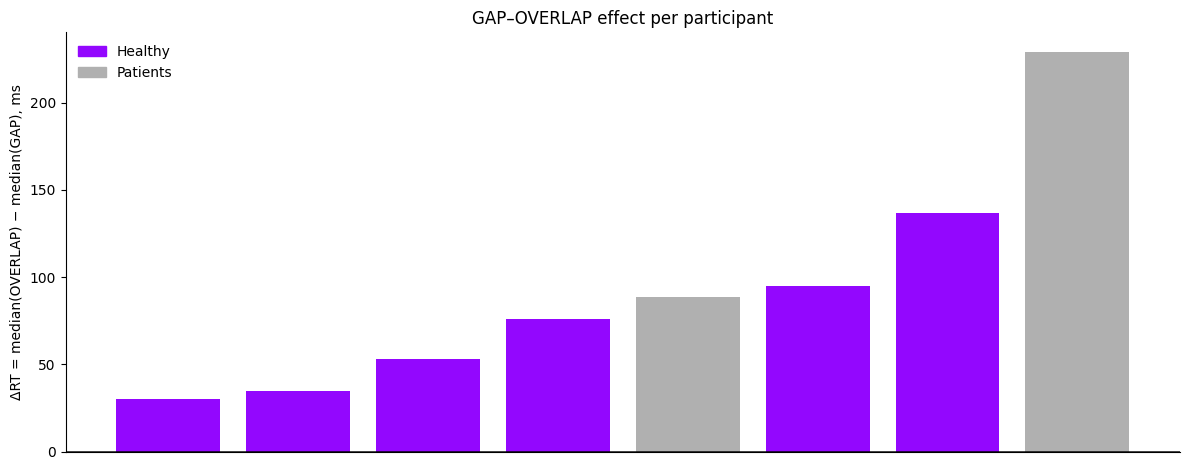

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

def plot_gap_overlap_delta_slide(
    adv_df: pd.DataFrame,
    lang: str = "ru",               # "ru" or "en"
    healthy_color: str = "#9307FE",
    patient_color: str = "#B0B0B0"
):
    df = adv_df.copy()
    df = df[df["gap_overlap_delta_rt_ms"].notna()].copy()
    if df.empty:
        print("Нет gap_overlap_delta_rt_ms для построения графика.")
        return

    df = df.sort_values("gap_overlap_delta_rt_ms").reset_index(drop=True)

    x = np.arange(len(df))
    y = df["gap_overlap_delta_rt_ms"].values
    is_healthy = df["label_text"].astype(str).str.lower().eq("healthy")

    # подписи RU/EN
    if lang.lower() == "ru":
        title = "Эффект GAP–OVERLAP по участникам"
        ylabel = "ΔRT = медиана(OVERLAP) − медиана(GAP), мс"
        leg_h = "Здоровые"
        leg_p = "Пациенты"
    else:
        title = "GAP–OVERLAP effect per participant"
        ylabel = "ΔRT = median(OVERLAP) − median(GAP), ms"
        leg_h = "Healthy"
        leg_p = "Patients"

    colors = [healthy_color if bool(is_healthy.iloc[i]) else patient_color for i in range(len(df))]

    plt.figure(figsize=(12, 4.8))
    plt.bar(x, y, color=colors)

    # нулевая линия
    plt.axhline(0, linewidth=2, color="black", alpha=0.8)

    # ось X без ID
    plt.xticks([])
    plt.xlabel("")
    plt.ylabel(ylabel)
    plt.title(title)

    # сетку убираем полностью
    plt.grid(False)

    # аккуратная легенда
    legend_handles = [
        mpatches.Patch(color=healthy_color, label=leg_h),
        mpatches.Patch(color=patient_color, label=leg_p),
    ]
    plt.legend(handles=legend_handles, frameon=False, loc="upper left")

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


# RU
# plot_gap_overlap_delta_slide(adv_rec_df, lang="ru", healthy_color="#9307FE", patient_color="#B0B0B0")

# EN
plot_gap_overlap_delta_slide(adv_rec_df, lang="en", healthy_color="#9307FE", patient_color="#B0B0B0")

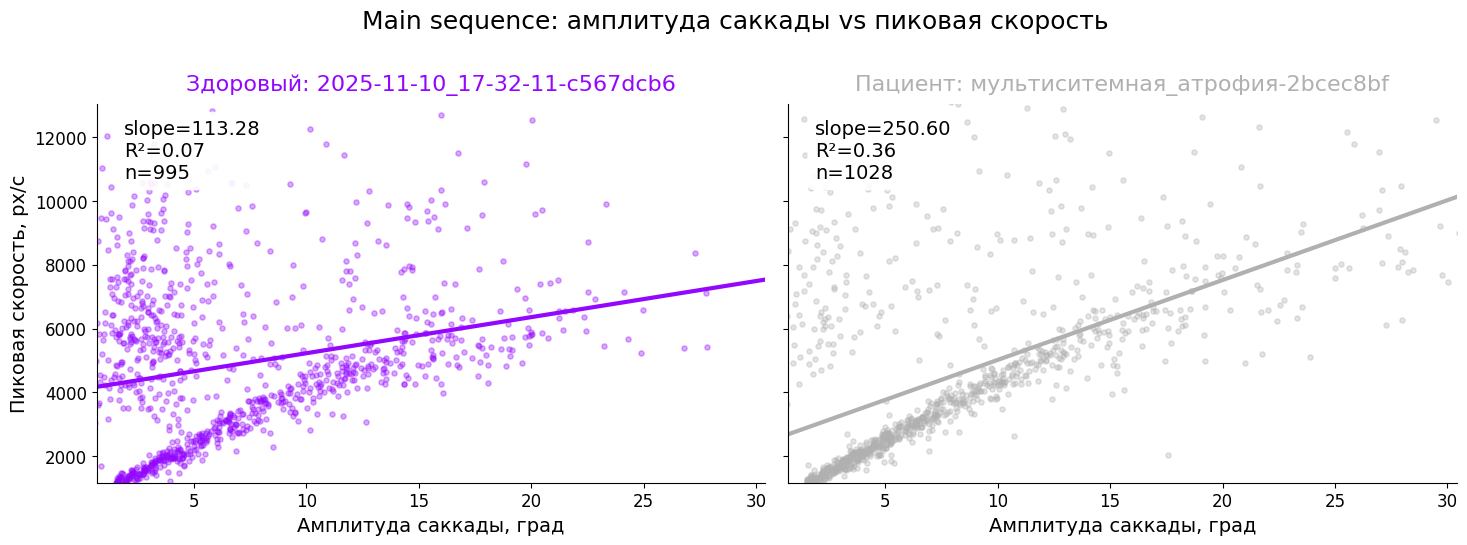

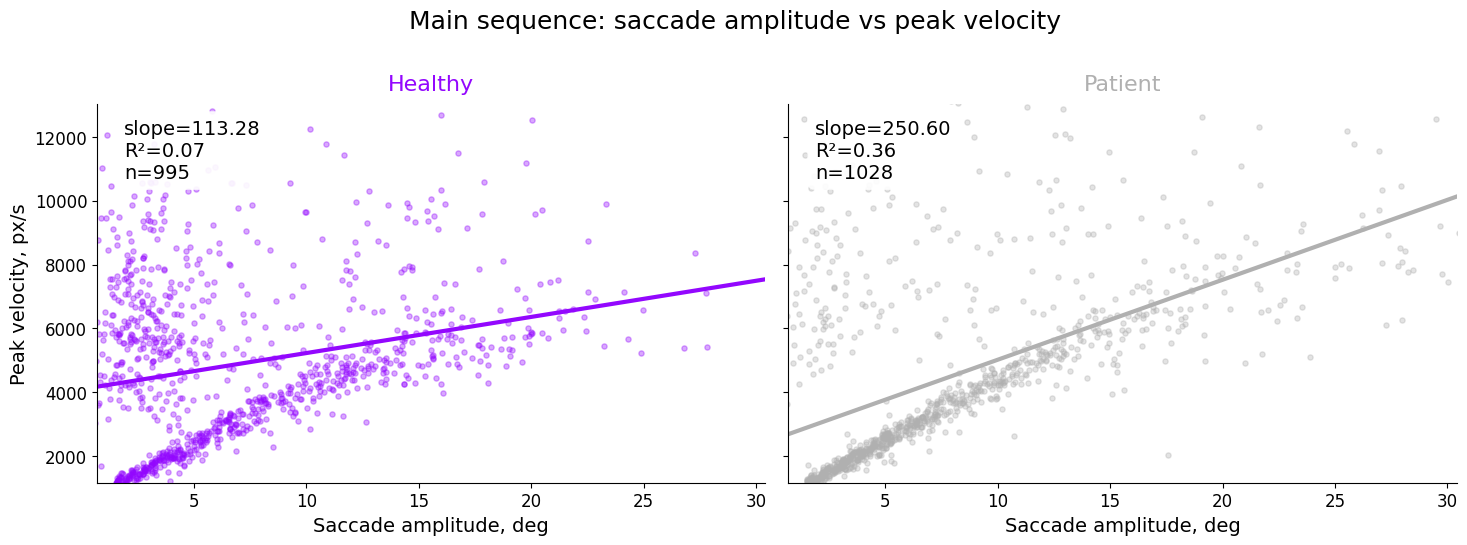

In [ ]:
# CELL S9-3 — Main sequence (slide mode): healthy vs patient in one row (RU/EN)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def _load_saccade_xy(recording_folder: str):
    folder = Path(recording_folder)
    sac_path = folder / "saccades.csv"
    if not sac_path.exists():
        return None, None, 0

    sac = pd.read_csv(sac_path)
    if "amplitude [deg]" not in sac.columns or "peak velocity [px/s]" not in sac.columns:
        return None, None, 0

    x = sac["amplitude [deg]"].astype(float)
    y = sac["peak velocity [px/s]"].astype(float)
    m = x.notna() & y.notna()
    x = x[m].values
    y = y[m].values
    return x, y, int(len(x))

def _fit_line(x, y):
    # y = a*x + b
    a, b = np.polyfit(x, y, 1)
    y_hat = a*x + b
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return float(a), float(b), float(r2)

def plot_main_sequence_pair_slide(
    healthy_folder: str,
    patient_folder: str,
    healthy_id: str = "HEALTHY",
    patient_id: str = "PATIENT",
    lang: str = "ru",               # "ru" or "en"
    healthy_color: str = "#9307FE",
    patient_color: str = "#B0B0B0",
    point_size: int = 14,
):
    # labels RU/EN
    if lang.lower() == "ru":
        sup_title = "Main sequence: амплитуда саккады vs пиковая скорость"
        xlab = "Амплитуда саккады, град"
        ylab = "Пиковая скорость, px/с"
        left_title = f"Здоровый: {healthy_id}"
        right_title = f"Пациент: {patient_id}"
        metric_fmt = "slope={:.2f}\nR²={:.2f}\nn={}"
    else:
        sup_title = "Main sequence: saccade amplitude vs peak velocity"
        xlab = "Saccade amplitude, deg"
        ylab = "Peak velocity, px/s"
        left_title = f"Healthy"
        right_title = f"Patient"
        metric_fmt = "slope={:.2f}\nR²={:.2f}\nn={}"

    # load data
    x_h, y_h, n_h = _load_saccade_xy(healthy_folder)
    x_p, y_p, n_p = _load_saccade_xy(patient_folder)

    if x_h is None or x_p is None:
        print("Не удалось загрузить saccades.csv или нужные колонки.")
        return

    # shared limits for fair comparison
    x_all = np.concatenate([x_h, x_p])
    y_all = np.concatenate([y_h, y_p])
    x_min, x_max = np.nanpercentile(x_all, [1, 99])
    y_min, y_max = np.nanpercentile(y_all, [1, 99])

    # fit
    a_h, b_h, r2_h = _fit_line(x_h, y_h) if n_h >= 20 else (np.nan, np.nan, np.nan)
    a_p, b_p, r2_p = _fit_line(x_p, y_p) if n_p >= 20 else (np.nan, np.nan, np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(14.8, 5.3), sharex=True, sharey=True)
    fig.suptitle(sup_title, fontsize=18, y=1.02)

    # helper to style axes "slide-like"
    def style_ax(ax):
        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(labelsize=12)

    # LEFT: healthy
    ax = axes[0]
    ax.scatter(x_h, y_h, s=point_size, alpha=0.35, color=healthy_color)
    if n_h >= 20:
        xs = np.linspace(x_min, x_max, 100)
        ax.plot(xs, a_h*xs + b_h, linewidth=3, color=healthy_color)
        ax.text(
            0.04, 0.96, metric_fmt.format(a_h, r2_h, n_h),
            transform=ax.transAxes, va="top",
            fontsize=14,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="none", alpha=0.92)
        )
    ax.set_title(left_title, fontsize=16, color=healthy_color, pad=10)
    ax.set_xlabel(xlab, fontsize=14)
    ax.set_ylabel(ylab, fontsize=14)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    style_ax(ax)

    # RIGHT: patient
    ax = axes[1]
    ax.scatter(x_p, y_p, s=point_size, alpha=0.35, color=patient_color)
    if n_p >= 20:
        xs = np.linspace(x_min, x_max, 100)
        ax.plot(xs, a_p*xs + b_p, linewidth=3, color=patient_color)
        ax.text(
            0.04, 0.96, metric_fmt.format(a_p, r2_p, n_p),
            transform=ax.transAxes, va="top",
            fontsize=14,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="none", alpha=0.92)
        )
    ax.set_title(right_title, fontsize=16, color=patient_color, pad=10)
    ax.set_xlabel(xlab, fontsize=14)
    style_ax(ax)

    plt.tight_layout()
    plt.show()


healthy_candidates = dataset_index[dataset_index["label_text"]=="healthy"].head(1)
patient_candidates = dataset_index[dataset_index["label_text"]=="patient"].head(1)

if len(healthy_candidates) and len(patient_candidates):
    h_folder = healthy_candidates.iloc[0]["recording_folder"]
    p_folder = patient_candidates.iloc[0]["recording_folder"]
    h_id = healthy_candidates.iloc[0]["recording_id"]
    p_id = patient_candidates.iloc[0]["recording_id"]

    # RU
    plot_main_sequence_pair_slide(
        h_folder, p_folder,
        healthy_id=h_id, patient_id=p_id,
        lang="ru",
        healthy_color="#9307FE",
        patient_color="#B0B0B0"
    )

    # EN
    plot_main_sequence_pair_slide(
        h_folder, p_folder,
        healthy_id=h_id, patient_id=p_id,
        lang="en",
        healthy_color="#9307FE",
        patient_color="#B0B0B0"
    )

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_qc_profile_slide(
    qc_df: pd.DataFrame,
    lang: str = "ru",  # "ru" or "en"
    healthy_color: str = "#9307FE",
    patient_color: str = "#B0B0B0",
    worn_thr: float = 0.85,
    rate_thr: float = 150.0,
    blink_thr: float = 30.0,
):
    """
    qc_df ожидает колонки:
      - label_text ("healthy"/"patient")
      - worn_ratio
      - gaze_rate_hz
      - blink_rate_per_min
      - qc_flag_low_worn (0/1)
      - qc_flag_low_rate (0/1)
      - qc_flag_high_motion (0/1)  (если нет — ок, поставим 0)
    """

    df = qc_df.copy()

    # на всякий случай
    for c in ["qc_flag_low_worn", "qc_flag_low_rate", "qc_flag_high_motion"]:
        if c not in df.columns:
            df[c] = 0

    df["label_text"] = df["label_text"].astype(str).str.lower()
    df = df[df["label_text"].isin(["healthy", "patient"])].copy()

    # QC score = сколько флагов сработало
    df["qc_score"] = df[["qc_flag_low_worn", "qc_flag_low_rate", "qc_flag_high_motion"]].sum(axis=1)

    # сортировка: сначала score, потом worn (чтобы красиво)
    df = df.sort_values(["qc_score", "worn_ratio"], ascending=[True, False]).reset_index(drop=True)

    is_healthy = df["label_text"].eq("healthy")
    colors = [healthy_color if bool(is_healthy.iloc[i]) else patient_color for i in range(len(df))]
    x = np.arange(len(df))

    # тексты RU/EN
    if lang.lower() == "ru":
        sup = "Профиль качества данных (QC)"
        t1, y1 = "Очки надеты (worn ratio)", "Доля"
        t2, y2 = "Частота gaze", "Гц"
        t3, y3 = "Частота морганий", "в минуту"
        t4, y4 = "QC score", "кол-во флагов"
        leg_h, leg_p = "Здоровые", "Пациенты"
        thr1, thr2, thr3 = "порог", "порог", "ориентир"
    else:
        sup = "Data quality profile (QC)"
        t1, y1 = "Worn ratio", "Ratio"
        t2, y2 = "Gaze sample rate", "Hz"
        t3, y3 = "Blink rate", "per min"
        t4, y4 = "QC score", "# flags"
        leg_h, leg_p = "Healthy", "Patients"
        thr1, thr2, thr3 = "threshold", "threshold", "reference"

    plt.figure(figsize=(15.8, 4.9))
    plt.suptitle(sup, fontsize=20, y=1.05)

    # helper: style axis for slides
    def style_ax(ax):
        ax.grid(False)
        ax.set_xticks([])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(labelsize=13)

    # 1) worn_ratio
    ax1 = plt.subplot(1,4,1)
    ax1.bar(x, df["worn_ratio"].values, color=colors)
    ax1.axhline(worn_thr, linewidth=3, color="black", alpha=0.85)
    ax1.set_title(t1, fontsize=16, pad=10)
    ax1.set_ylabel(y1, fontsize=15)
    ax1.set_ylim(0, 1.02)
    ax1.text(0.02, 0.92, f"{thr1}: {worn_thr:.2f}", transform=ax1.transAxes,
             fontsize=14, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.92))
    style_ax(ax1)

    # 2) gaze_rate_hz
    ax2 = plt.subplot(1,4,2, sharex=ax1)
    ax2.bar(x, df["gaze_rate_hz"].values, color=colors)
    ax2.axhline(rate_thr, linewidth=3, color="black", alpha=0.85)
    ax2.set_title(t2, fontsize=16, pad=10)
    ax2.set_ylabel(y2, fontsize=15)
    ax2.text(0.02, 0.92, f"{thr2}: {rate_thr:.0f}", transform=ax2.transAxes,
             fontsize=14, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.92))
    style_ax(ax2)

    # 3) blink_rate_per_min
    ax3 = plt.subplot(1,4,3, sharex=ax1)
    ax3.bar(x, df["blink_rate_per_min"].values, color=colors)
    ax3.axhline(blink_thr, linewidth=3, color="black", alpha=0.85)
    ax3.set_title(t3, fontsize=16, pad=10)
    ax3.set_ylabel(y3, fontsize=15)
    ax3.text(0.02, 0.92, f"{thr3}: {blink_thr:.0f}", transform=ax3.transAxes,
             fontsize=14, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.92))
    style_ax(ax3)

    # 4) qc_score
    ax4 = plt.subplot(1,4,4, sharex=ax1)
    ax4.bar(x, df["qc_score"].values, color=colors)
    ax4.set_title(t4, fontsize=16, pad=10)
    ax4.set_ylabel(y4, fontsize=15)
    ax4.set_ylim(-0.2, 3.2)
    style_ax(ax4)

    # легенда (одна на всю фигуру)
    legend_handles = [
        mpatches.Patch(color=healthy_color, label=leg_h),
        mpatches.Patch(color=patient_color, label=leg_p),
    ]
    plt.legend(handles=legend_handles, frameon=False, loc="upper left", bbox_to_anchor=(0.01, 1.12), fontsize=14)

    plt.tight_layout()
    plt.show()

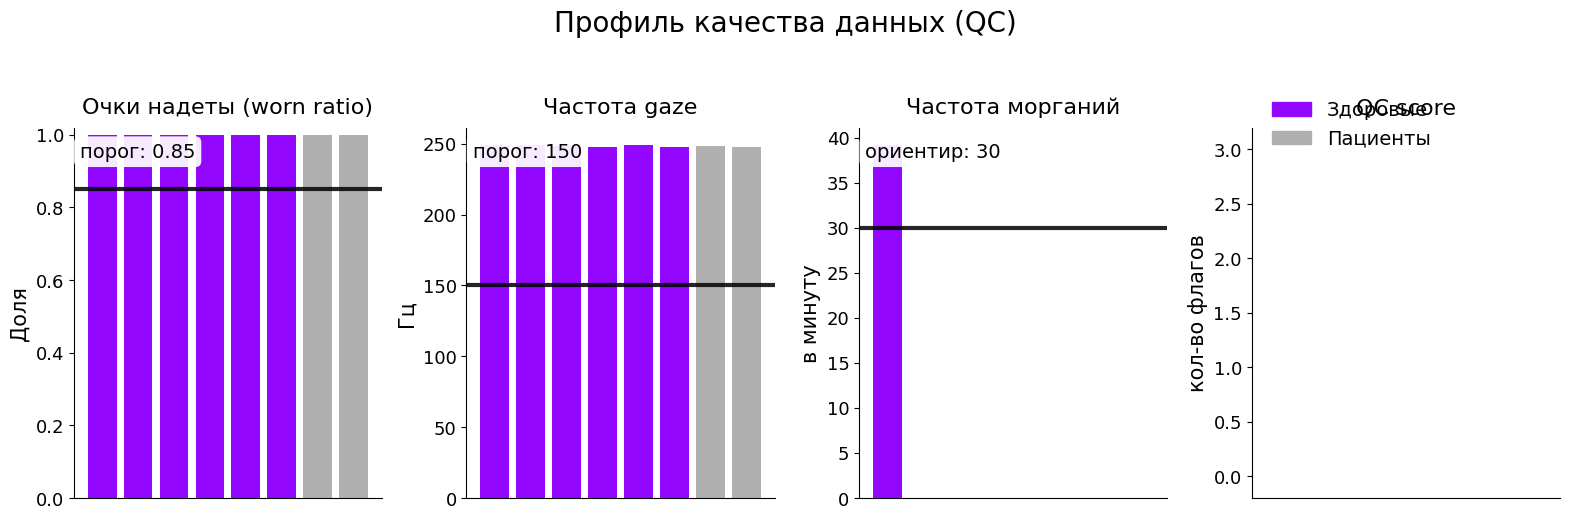

In [ ]:
# RU
plot_qc_profile_slide(
    subject_qc_df,
    lang="ru",
    healthy_color="#9307FE",
    patient_color="#B0B0B0",
    worn_thr=0.85,
    rate_thr=150.0,
    blink_thr=30.0
)

# # EN
# plot_qc_profile_slide(
#     subject_qc_df,
#     lang="en",
#     healthy_color="#9307FE",
#     patient_color="#B0B0B0",
#     worn_thr=0.85,
#     rate_thr=150.0,
#     blink_thr=30.0
# )

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

def _pick_col(df: pd.DataFrame, candidates):
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    # fallback: contains
    for cand in candidates:
        for c in df.columns:
            if cand.lower() in c.lower():
                return c
    return None

def compute_qc_from_folder(recording_folder: str, conf_thr: float = 0.6, dropout_gap_s: float = 0.1):
    """
    QC метрики из gaze.csv:
      - worn_ratio
      - valid_gaze_ratio (worn & ~blink & (confidence>=thr если есть))
      - gaze_rate_hz (effective)
      - blink_rate_per_min (по blink id episodes)
      - dropout_rate_per_min (по большим gaps в timestamps)
      - duration_s
    """
    folder = Path(recording_folder)
    gaze_path = folder / "gaze.csv"
    if not gaze_path.exists():
        return None

    gaze = pd.read_csv(gaze_path)

    ts_col = _pick_col(gaze, ["timestamp [ns]", "timestamp_ns", "timestamp"])
    if ts_col is None:
        return None

    # timestamps -> seconds
    ts = pd.to_numeric(gaze[ts_col], errors="coerce").values
    ts = ts[np.isfinite(ts)]
    if len(ts) < 10:
        return None

    t0, t1 = ts.min(), ts.max()
    duration_s = (t1 - t0) / 1e9
    if duration_s <= 0:
        return None

    # worn
    worn_col = _pick_col(gaze, ["worn", "worn [bool]"])
    if worn_col is not None:
        worn = gaze[worn_col].astype(float).fillna(0).values > 0.5
    else:
        worn = np.ones(len(gaze), dtype=bool)

    worn_ratio = float(np.mean(worn))

    # blink state (по blink id в gaze.csv)
    blink_col = _pick_col(gaze, ["blink id", "blink_id"])
    if blink_col is not None:
        blink_id = pd.to_numeric(gaze[blink_col], errors="coerce")
        # считаем blink, если blink_id не NaN
        blink_state = blink_id.notna().values
    else:
        blink_state = np.zeros(len(gaze), dtype=bool)

    # confidence (если есть)
    conf_col = _pick_col(gaze, ["confidence"])
    if conf_col is not None:
        conf = pd.to_numeric(gaze[conf_col], errors="coerce").fillna(0).values
        conf_ok = conf >= conf_thr
        low_conf_ratio = float(np.mean(conf < conf_thr))
    else:
        conf_ok = np.ones(len(gaze), dtype=bool)
        low_conf_ratio = np.nan

    valid = worn & (~blink_state) & conf_ok
    valid_gaze_ratio = float(np.mean(valid))

    # effective rate
    gaze_rate_hz = float(len(gaze) / duration_s)

    # blink episodes count (rising edges)
    if len(blink_state) >= 2:
        blink_onsets = np.sum((blink_state[1:] == True) & (blink_state[:-1] == False))
    else:
        blink_onsets = 0
    blink_rate_per_min = float(blink_onsets / (duration_s / 60.0))

    # dropouts: gaps in time > dropout_gap_s
    # (берём полную шкалу из исходного gaze, чтобы учитывать пропуски)
    ts_full = pd.to_numeric(gaze[ts_col], errors="coerce").values
    m = np.isfinite(ts_full)
    ts_full = ts_full[m]
    dt = np.diff(np.sort(ts_full)) / 1e9
    dropout_events = np.sum(dt > dropout_gap_s)
    dropout_rate_per_min = float(dropout_events / (duration_s / 60.0))

    return {
        "duration_s": float(duration_s),
        "worn_ratio": worn_ratio,
        "valid_gaze_ratio": valid_gaze_ratio,
        "gaze_rate_hz": gaze_rate_hz,
        "blink_rate_per_min": blink_rate_per_min,
        "dropout_rate_per_min": dropout_rate_per_min,
        "low_conf_ratio": low_conf_ratio,
    }

# пересчёт QC для всех записей
qc_rows = []
for _, r in dataset_index.drop_duplicates("recording_id").iterrows():
    rec_id = r["recording_id"]
    out = compute_qc_from_folder(r["recording_folder"])
    if out is None:
        continue
    out.update({
        "recording_id": rec_id,
        "label_text": r["label_text"],
    })
    qc_rows.append(out)

qc_recomputed_df = pd.DataFrame(qc_rows)
display(qc_recomputed_df)

,duration_s,worn_ratio,valid_gaze_ratio,gaze_rate_hz,blink_rate_per_min,dropout_rate_per_min,low_conf_ratio,recording_id,label_text
0,725.379971,1.0,0.761872,199.735319,36.642865,0.0,NaN,2025-11-10_17-32-11-c567dcb6,healthy
1,680.920027,1.0,1.000000,199.740050,0.000000,0.0,NaN,2025-12-22_15-21-53-5007559b,healthy
2,674.780006,1.0,1.000000,199.697677,0.000000,0.0,NaN,2025-12-22_15-49-23-4e211ab0,healthy
3,655.051971,1.0,1.000000,199.730717,0.000000,0.0,NaN,2025-12-22_15-36-14-5ae0d89d,healthy
4,648.751969,1.0,1.000000,199.729644,0.000000,0.0,NaN,2025-12-22_16-02-47-6f17655e,healthy
5,559.316159,1.0,1.000000,199.720674,0.000000,0.0,NaN,2026-01-07_14-37-02-7649719b,healthy
6,717.552042,1.0,1.000000,199.666354,0.000000,0.0,NaN,мультиситемная_атрофия-2bcec8bf,patient
7,741.087817,1.0,1.000000,199.711824,0.000000,0.0,NaN,болезнь_парксинсона_смешанная_форма_3_стадия-e...,patient


In [ ]:
# coverage из trial_metrics_df: сколько trial всего и доля найденных RT
cov = (
    trial_metrics_df.groupby("recording_id")
    .agg(
        n_trials=("trial_id", "nunique"),
        rt_found_rate=("rt_found", "mean"),
    )
    .reset_index()
)

qc_slide_df = qc_recomputed_df.merge(cov, on="recording_id", how="left")
display(qc_slide_df)

,duration_s,worn_ratio,valid_gaze_ratio,gaze_rate_hz,blink_rate_per_min,dropout_rate_per_min,low_conf_ratio,recording_id,label_text,n_trials,rt_found_rate
0,725.379971,1.0,0.761872,199.735319,36.642865,0.0,NaN,2025-11-10_17-32-11-c567dcb6,healthy,20,0.9500
1,680.920027,1.0,1.000000,199.740050,0.000000,0.0,NaN,2025-12-22_15-21-53-5007559b,healthy,20,0.9375
2,674.780006,1.0,1.000000,199.697677,0.000000,0.0,NaN,2025-12-22_15-49-23-4e211ab0,healthy,20,0.9125
3,655.051971,1.0,1.000000,199.730717,0.000000,0.0,NaN,2025-12-22_15-36-14-5ae0d89d,healthy,20,0.9750
4,648.751969,1.0,1.000000,199.729644,0.000000,0.0,NaN,2025-12-22_16-02-47-6f17655e,healthy,20,0.9250
5,559.316159,1.0,1.000000,199.720674,0.000000,0.0,NaN,2026-01-07_14-37-02-7649719b,healthy,20,0.9375
6,717.552042,1.0,1.000000,199.666354,0.000000,0.0,NaN,мультиситемная_атрофия-2bcec8bf,patient,20,0.9250
7,741.087817,1.0,1.000000,199.711824,0.000000,0.0,NaN,болезнь_парксинсона_смешанная_форма_3_стадия-e...,patient,20,0.8000


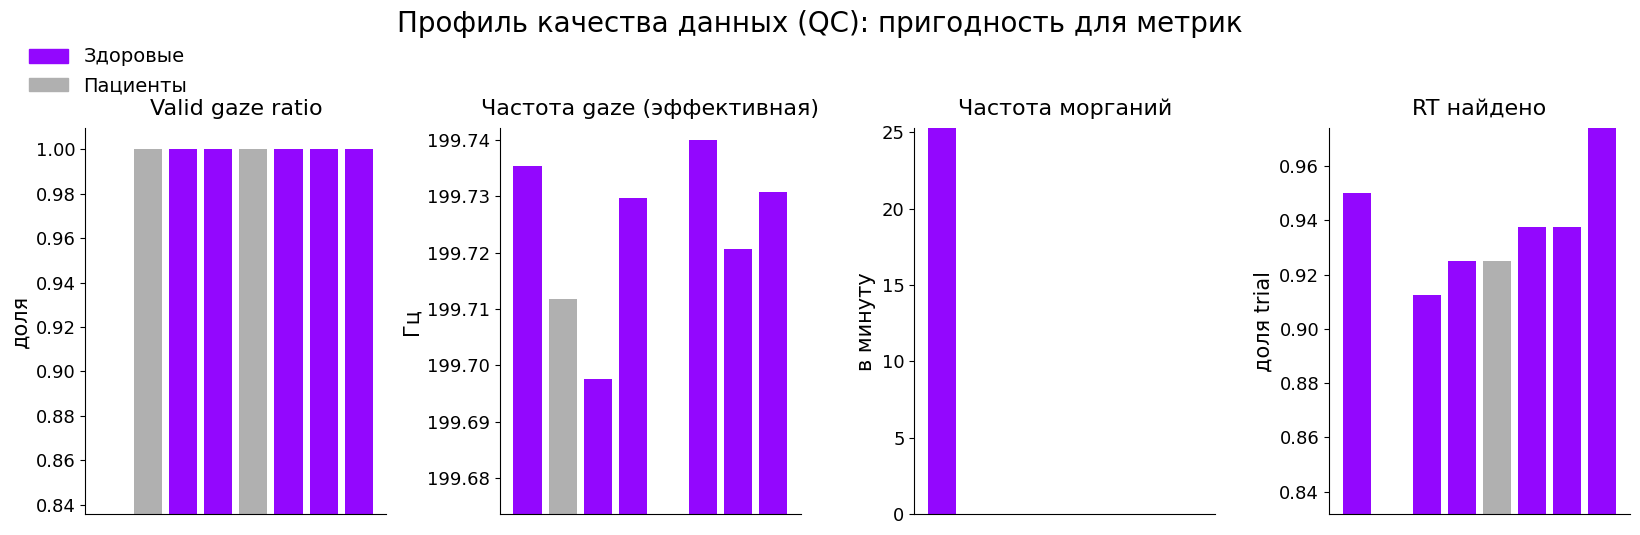

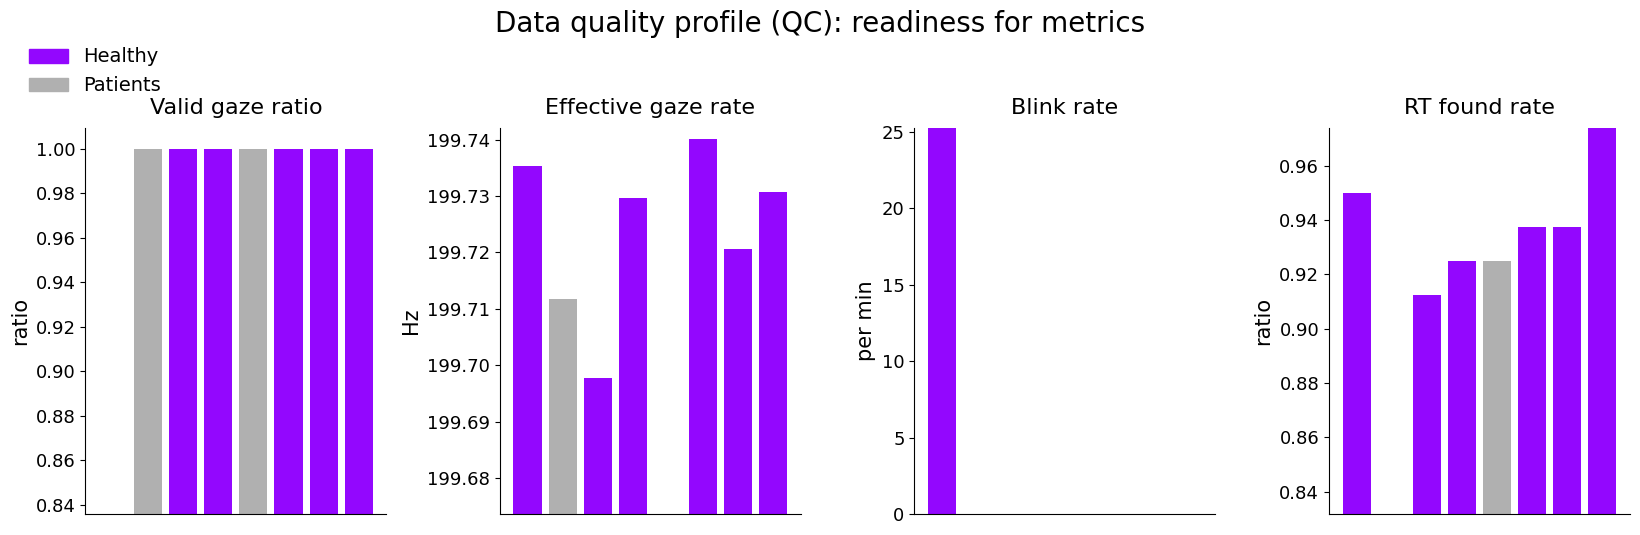

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def _auto_ylim(vals, pad=0.06):
    v = np.array(vals, dtype=float)
    v = v[np.isfinite(v)]
    if len(v) == 0:
        return None
    lo, hi = np.percentile(v, [5, 95])
    if lo == hi:
        lo -= 1
        hi += 1
    span = hi - lo
    return (lo - pad*span, hi + pad*span)

def plot_qc_profile_slide_v2(
    df_in,
    lang="ru",
    healthy_color="#9307FE",
    patient_color="#B0B0B0",
    valid_thr=0.80,
    rate_ref=200.0,
    blink_ref=30.0,
    rt_found_ref=0.70,
):
    df = df_in.copy()
    df["label_text"] = df["label_text"].astype(str).str.lower()
    df = df[df["label_text"].isin(["healthy","patient"])].copy()

    # сортируем так, чтобы "хуже" было левее (для всех панелей единый порядок)
    df = df.sort_values(["valid_gaze_ratio", "rt_found_rate"], ascending=[True, True]).reset_index(drop=True)

    is_healthy = df["label_text"].eq("healthy")
    colors = [healthy_color if bool(is_healthy.iloc[i]) else patient_color for i in range(len(df))]
    x = np.arange(len(df))

    if lang.lower() == "ru":
        sup = "Профиль качества данных (QC): пригодность для метрик"
        t1, y1 = "Valid gaze ratio", "доля"
        t2, y2 = "Частота gaze (эффективная)", "Гц"
        t3, y3 = "Частота морганий", "в минуту"
        t4, y4 = "RT найдено", "доля trial"
        leg_h, leg_p = "Здоровые", "Пациенты"
    else:
        sup = "Data quality profile (QC): readiness for metrics"
        t1, y1 = "Valid gaze ratio", "ratio"
        t2, y2 = "Effective gaze rate", "Hz"
        t3, y3 = "Blink rate", "per min"
        t4, y4 = "RT found rate", "ratio"
        leg_h, leg_p = "Healthy", "Patients"

    fig, axes = plt.subplots(1, 4, figsize=(16.5, 5.0))
    fig.suptitle(sup, fontsize=20, y=1.06)

    def style(ax):
        ax.grid(False)
        ax.set_xticks([])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(labelsize=13)

    # 1) valid gaze ratio
    ax = axes[0]
    ax.bar(x, df["valid_gaze_ratio"], color=colors)
    ax.axhline(valid_thr, linewidth=3, color="black", alpha=0.8)
    ax.set_title(t1, fontsize=16, pad=10)
    ax.set_ylabel(y1, fontsize=15)
    yl = _auto_ylim(df["valid_gaze_ratio"])
    ax.set_ylim(max(0, yl[0]), min(1.02, yl[1]))
    style(ax)

    # 2) gaze rate (zoomed)
    ax = axes[1]
    ax.bar(x, df["gaze_rate_hz"], color=colors)
    ax.axhline(rate_ref, linewidth=3, color="black", alpha=0.8)
    ax.set_title(t2, fontsize=16, pad=10)
    ax.set_ylabel(y2, fontsize=15)
    yl = _auto_ylim(df["gaze_rate_hz"])
    ax.set_ylim(yl)
    style(ax)

    # 3) blink rate
    ax = axes[2]
    ax.bar(x, df["blink_rate_per_min"], color=colors)
    ax.axhline(blink_ref, linewidth=3, color="black", alpha=0.8)
    ax.set_title(t3, fontsize=16, pad=10)
    ax.set_ylabel(y3, fontsize=15)
    yl = _auto_ylim(df["blink_rate_per_min"])
    ax.set_ylim(max(0, yl[0]), yl[1])
    style(ax)

    # 4) RT found rate (protocol/metric readiness)
    ax = axes[3]
    ax.bar(x, df["rt_found_rate"], color=colors)
    ax.axhline(rt_found_ref, linewidth=3, color="black", alpha=0.8)
    ax.set_title(t4, fontsize=16, pad=10)
    ax.set_ylabel(y4, fontsize=15)
    yl = _auto_ylim(df["rt_found_rate"])
    ax.set_ylim(max(0, yl[0]), min(1.02, yl[1]))
    style(ax)

    legend_handles = [
        mpatches.Patch(color=healthy_color, label=leg_h),
        mpatches.Patch(color=patient_color, label=leg_p),
    ]
    fig.legend(handles=legend_handles, frameon=False, loc="upper left",
               bbox_to_anchor=(0.01, 1.02), fontsize=14)

    plt.tight_layout()
    plt.show()

# RU
plot_qc_profile_slide_v2(qc_slide_df, lang="ru", healthy_color="#9307FE", patient_color="#B0B0B0")

# EN
plot_qc_profile_slide_v2(qc_slide_df, lang="en", healthy_color="#9307FE", patient_color="#B0B0B0")

In [ ]:
# CELL S11-1 — Post-hoc mapping cluster->label and error flags

import numpy as np
import pandas as pd

def add_posthoc_mapping_and_errors(df: pd.DataFrame,
                                  cluster_col="cluster",
                                  label_col="label_text"):
    out = df.copy()
    out[label_col] = out[label_col].astype(str).str.lower()

    valid = out[label_col].isin(["healthy","patient"])
    mapping = {}
    for cl, g in out[valid].groupby(cluster_col):
        if len(g) == 0:
            continue
        mapping[int(cl)] = g[label_col].value_counts().idxmax()

    out["cluster_mapped_label"] = out[cluster_col].map(mapping)
    out["is_error"] = valid & (out["cluster_mapped_label"] != out[label_col])

    # короткая сводка
    err_n = int(out["is_error"].sum())
    tot_n = int(valid.sum())
    return out, mapping, err_n, tot_n

feat_df2, cluster2label, err_n, tot_n = add_posthoc_mapping_and_errors(feat_df)
cluster2label, err_n, tot_n

({0: 'healthy', 1: 'healthy'}, 2, 8)

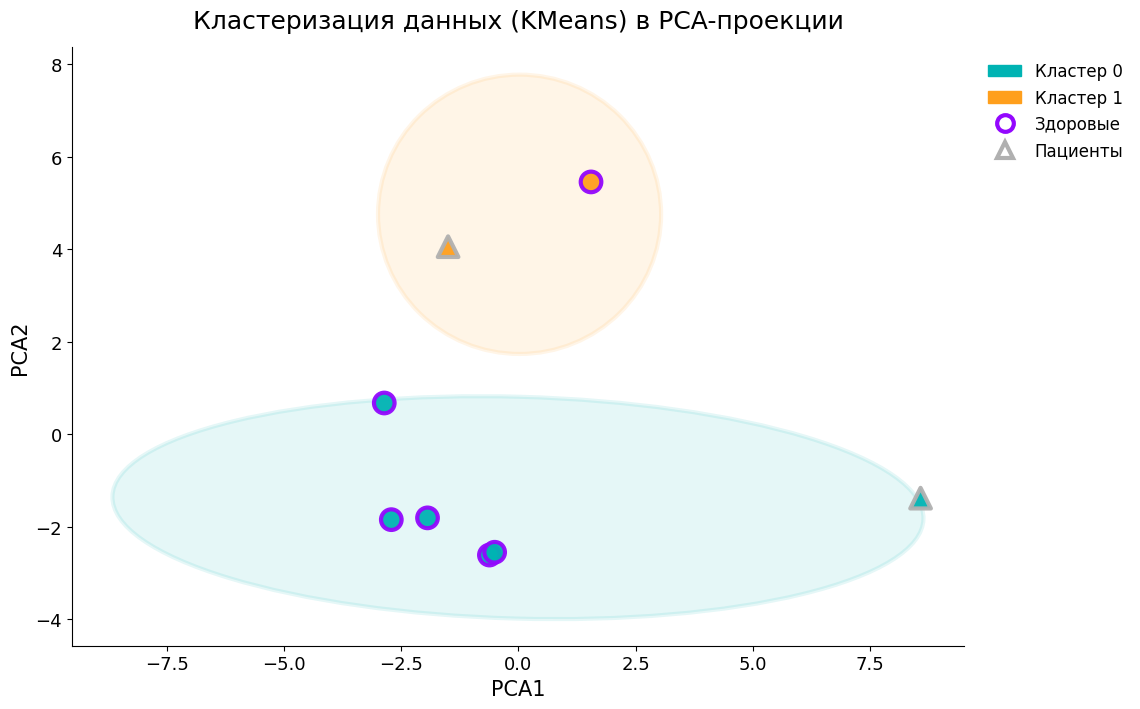

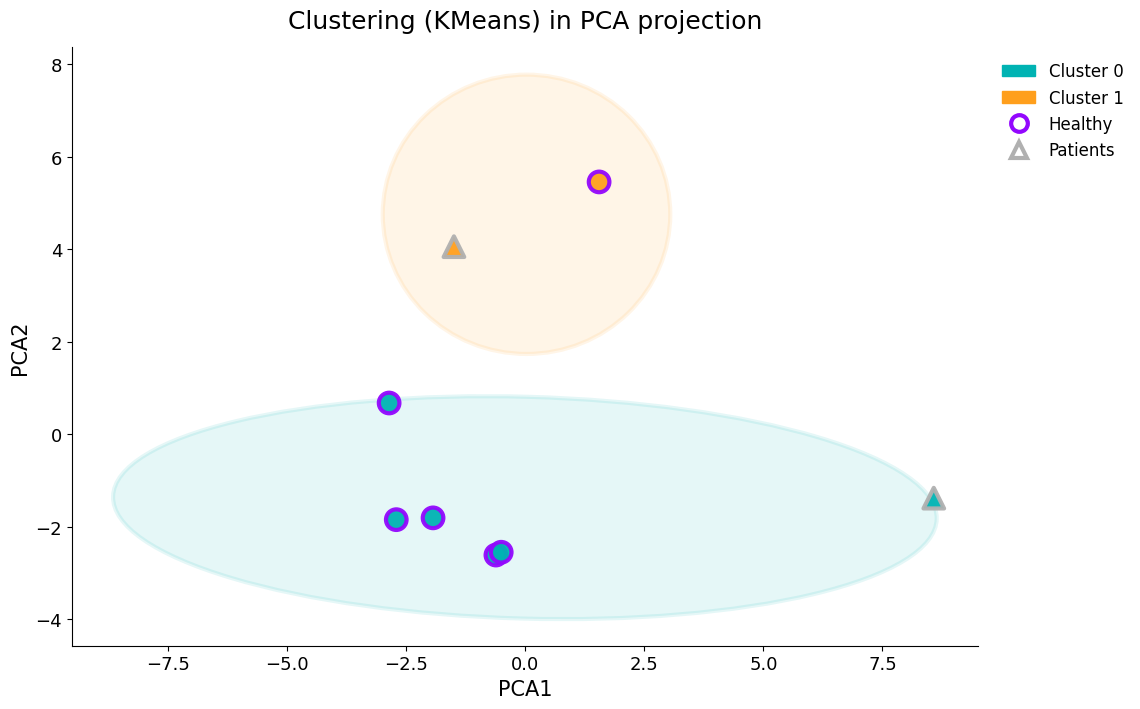

In [ ]:
# CELL S11-2 — Slide-ready clustering plot (RU/EN)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse

def _add_cluster_ellipse(ax, xs, ys, color, alpha=0.12, lw=3):
    xs = np.asarray(xs, float)
    ys = np.asarray(ys, float)
    xs = xs[np.isfinite(xs)]
    ys = ys[np.isfinite(ys)]
    if len(xs) < 3:
        # fallback: circle around centroid
        cx, cy = np.mean(xs), np.mean(ys)
        r = 0.15 if len(xs) == 1 else max(np.hypot(xs-cx, ys-cy)) * 1.8
        circ = plt.Circle((cx, cy), r, facecolor=color, edgecolor=color, alpha=alpha, lw=lw)
        ax.add_patch(circ)
        return

    cov = np.cov(xs, ys)
    if not np.all(np.isfinite(cov)):
        return

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    # 2 std ellipse
    n_std = 2.0
    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 1e-9))
    angle = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))

    ell = Ellipse(
        (np.mean(xs), np.mean(ys)),
        width=width, height=height, angle=angle,
        facecolor=color, edgecolor=color, lw=lw, alpha=alpha
    )
    ax.add_patch(ell)

def plot_clustering_slide(df: pd.DataFrame,
                          lang="ru",
                          healthy_color="#9307FE",
                          patient_color="#B0B0B0",
                          cluster_colors=None,
                          point_size=220,
                          error_size=280):
    d = df.copy()

    # цвета кластеров
    if cluster_colors is None:
        cluster_colors = {
            0: "#00B3B3",  # teal
            1: "#FF9F1C",  # orange
        }

    # тексты RU/EN
    if lang.lower() == "ru":
        title = "Кластеризация данных (KMeans) в PCA-проекции"
        xlab, ylab = "PCA1", "PCA2"
        leg_cluster = "Кластер"
        leg_h, leg_p = "Здоровые", "Пациенты"
        leg_err = "Несовпадение с меткой"
        # note = f"Ошибки (post-hoc): {err_n}/{tot_n} | mapping: {cluster2label}"
    else:
        title = "Clustering (KMeans) in PCA projection"
        xlab, ylab = "PCA1", "PCA2"
        leg_cluster = "Cluster"
        leg_h, leg_p = "Healthy", "Patients"
        leg_err = "Mismatch vs label"
        # note = f"Mismatches (post-hoc): {err_n}/{tot_n} | mapping: {cluster2label}"

    # маркеры истинных меток (для sanity-check)
    marker_map = {"healthy": "o", "patient": "^"}

    fig, ax = plt.subplots(1, 1, figsize=(11.5, 7.2))
    ax.set_title(title, fontsize=18, pad=14)

    # 1) эллипсы и центроиды кластеров
    for cl in sorted(d["cluster"].dropna().unique()):
        cl = int(cl)
        sub = d[d["cluster"] == cl]
        c = cluster_colors.get(cl, "#888888")

        _add_cluster_ellipse(ax, sub["pca1"], sub["pca2"], color=c, alpha=0.10, lw=3)

        cx, cy = sub["pca1"].mean(), sub["pca2"].mean()
        # ax.scatter([cx], [cy], s=420, marker="*", color=c, edgecolor="black", linewidth=1.5, zorder=6)
        # ax.text(cx, cy, f"  C{cl}", fontsize=14, va="center", zorder=7)

    # 2) точки: заливка = кластер, форма = метка (healthy/patient)
    for lt in ["healthy", "patient"]:
        sub = d[d["label_text"].astype(str).str.lower() == lt]
        if sub.empty:
            continue

        facecols = [cluster_colors.get(int(cl), "#888888") for cl in sub["cluster"].values]
        edge = healthy_color if lt == "healthy" else patient_color

        ax.scatter(
            sub["pca1"], sub["pca2"],
            s=point_size,
            c=facecols,
            marker=marker_map[lt],
            edgecolor=edge,
            linewidth=3.0,
            alpha=0.95,
            zorder=5
        )

    # 3) ошибки — красный X поверх
    # err = d[d.get("is_error", False) == True]
    # if not err.empty:
    #     ax.scatter(
    #         err["pca1"], err["pca2"],
    #         s=error_size,
    #         marker="x",
    #         color="red",
    #         linewidth=4.0,
    #         zorder=8
    #     )

    # оформление: без сетки
    ax.grid(False)
    ax.set_xlabel(xlab, fontsize=15)
    ax.set_ylabel(ylab, fontsize=15)
    ax.tick_params(labelsize=13)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # легенда (аккуратно)
    handles = []
    # кластеры
    for cl in sorted(d["cluster"].dropna().unique()):
        cl = int(cl)
        handles.append(mpatches.Patch(color=cluster_colors.get(cl, "#888888"), label=f"{leg_cluster} {cl}"))

    # формы меток
    handles.append(plt.Line2D([0],[0], marker="o", linestyle="",
                             markerfacecolor="white", markeredgecolor=healthy_color,
                             markeredgewidth=3, markersize=12, label=leg_h))
    handles.append(plt.Line2D([0],[0], marker="^", linestyle="",
                             markerfacecolor="white", markeredgecolor=patient_color,
                             markeredgewidth=3, markersize=12, label=leg_p))
    # ошибки
    # handles.append(plt.Line2D([0],[0], marker="x", linestyle="", color="red",
                            #  markersize=12, markeredgewidth=3, label=leg_err))

    ax.legend(handles=handles, frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=12)

    # # заметка на графике
    # ax.text(
    #     0.02, 0.02, note,
    #     transform=ax.transAxes,
    #     fontsize=12,
    #     bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="none", alpha=0.92)
    # )

    plt.tight_layout()
    plt.show()

# RU
plot_clustering_slide(feat_df2, lang="ru", healthy_color="#9307FE", patient_color="#B0B0B0")

# EN
plot_clustering_slide(feat_df2, lang="en", healthy_color="#9307FE", patient_color="#B0B0B0")

## Классификация типов задания

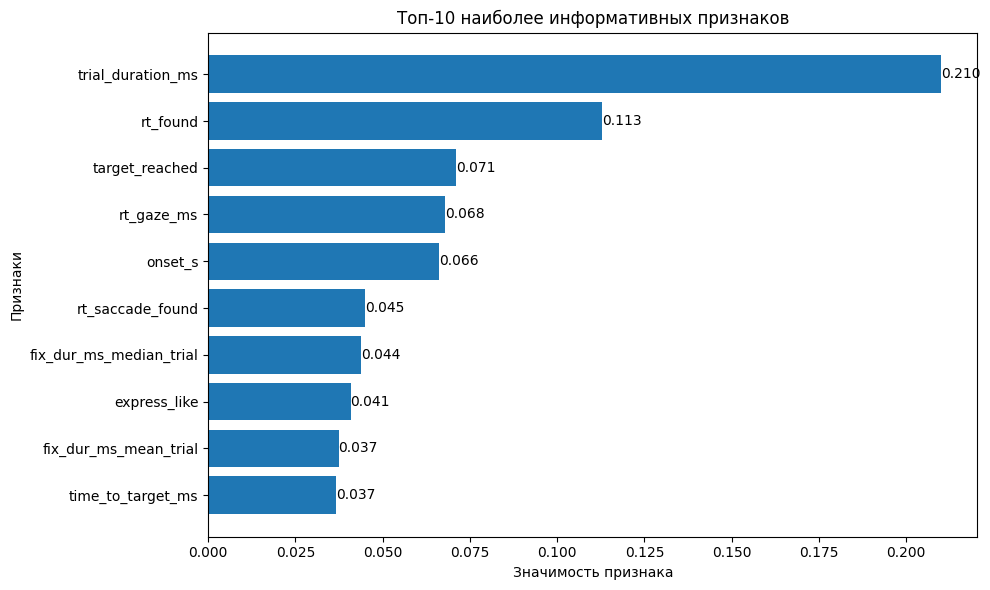

In [ ]:
import matplotlib.pyplot as plt

# Данные
features = [
    'trial_duration_ms',
    'rt_found',
    'target_reached',
    'rt_gaze_ms',
    'onset_s',
    'rt_saccade_found',
    'fix_dur_ms_median_trial',
    'express_like',
    'fix_dur_ms_mean_trial',
    'time_to_target_ms'
]

values = [
    0.20990992458240623,
    0.11280244264988719,
    0.07091378601822325,
    0.0680003109835179,
    0.06627174629566791,
    0.04498136760620564,
    0.0437387307711047,
    0.040812625119787824,
    0.037373574212436395,
    0.03653541844713339
]

# Сортировка (по убыванию важности)
features_sorted, values_sorted = zip(*sorted(zip(features, values), key=lambda x: x[1], reverse=True))

# Построение графика
plt.figure(figsize=(10, 6))
plt.barh(features_sorted, values_sorted)
plt.xlabel('Значимость признака')
plt.ylabel('Признаки')
plt.title('Топ-10 наиболее информативных признаков')
plt.gca().invert_yaxis()  # самый важный сверху

# Подписи значений
for i, v in enumerate(values_sorted):
    plt.text(v, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.show()

---
# Загрузка данных

In [ ]:
SPEECH_PATH = 'speech_datase.csv'
EYE_PATH    = 'subject_qc.csv'

speech_raw = pd.read_csv(SPEECH_PATH)
eye_raw    = pd.read_csv(EYE_PATH)

print(f'Speech: {speech_raw.shape}  |  классы: {dict(speech_raw.status.value_counts())}')
print(f'Eye:    {eye_raw.shape}     |  классы: {dict(eye_raw.label.value_counts())}')

Speech: (197, 23)  |  классы: {1: np.int64(148), 0: np.int64(49)}
Eye:    (8, 21)     |  классы: {0: np.int64(6), 1: np.int64(2)}


---
# Анализ речевого датасета и визуализация результатов

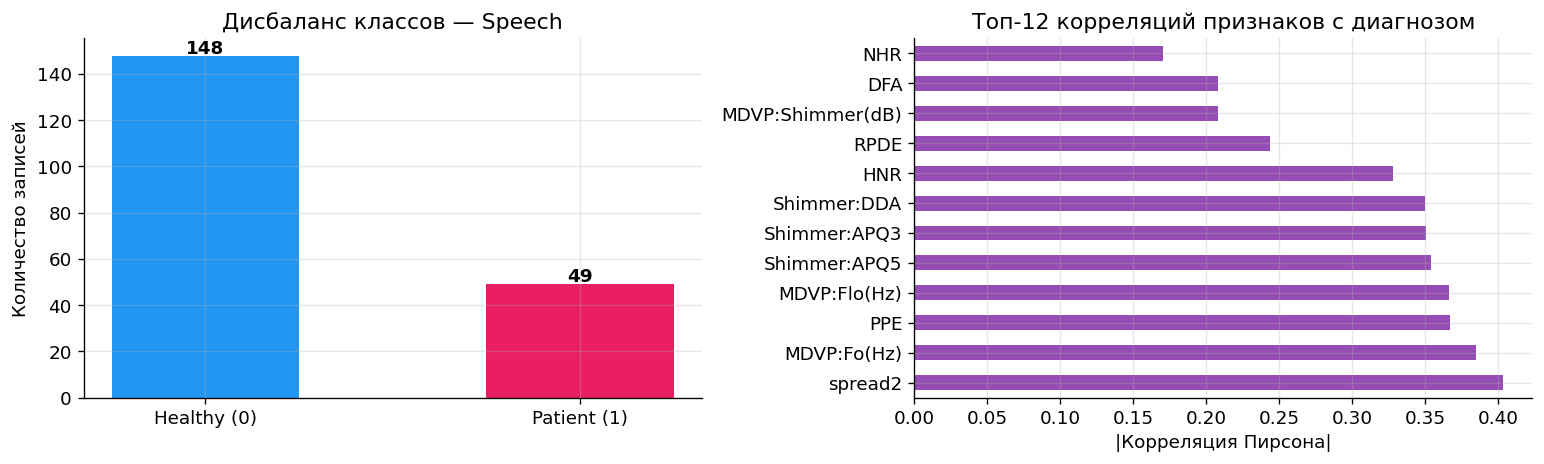

In [ ]:
# ── EDA: Дисбаланс классов ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Распределение классов
ax = axes[0]
counts = speech['status'].value_counts()
bars = ax.bar(['Healthy (0)', 'Patient (1)'], counts.values,
              color=[PALETTE['healthy'], PALETTE['patient']], width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontweight='bold')
ax.set_title('Дисбаланс классов — Speech')
ax.set_ylabel('Количество записей')

ax = axes[1]
feat_cols = [c for c in speech.columns if c != 'status']
corrs = speech[feat_cols].corrwith(speech['status']).abs().sort_values(ascending=False)[:12]
corrs.plot(kind='barh', ax=ax, color='#7B1FA2', alpha=0.8)
ax.set_title('Топ-12 корреляций признаков с диагнозом')
ax.set_xlabel('|Корреляция Пирсона|')

plt.tight_layout()
plt.savefig('speech_eda.png', bbox_inches='tight')
plt.show()

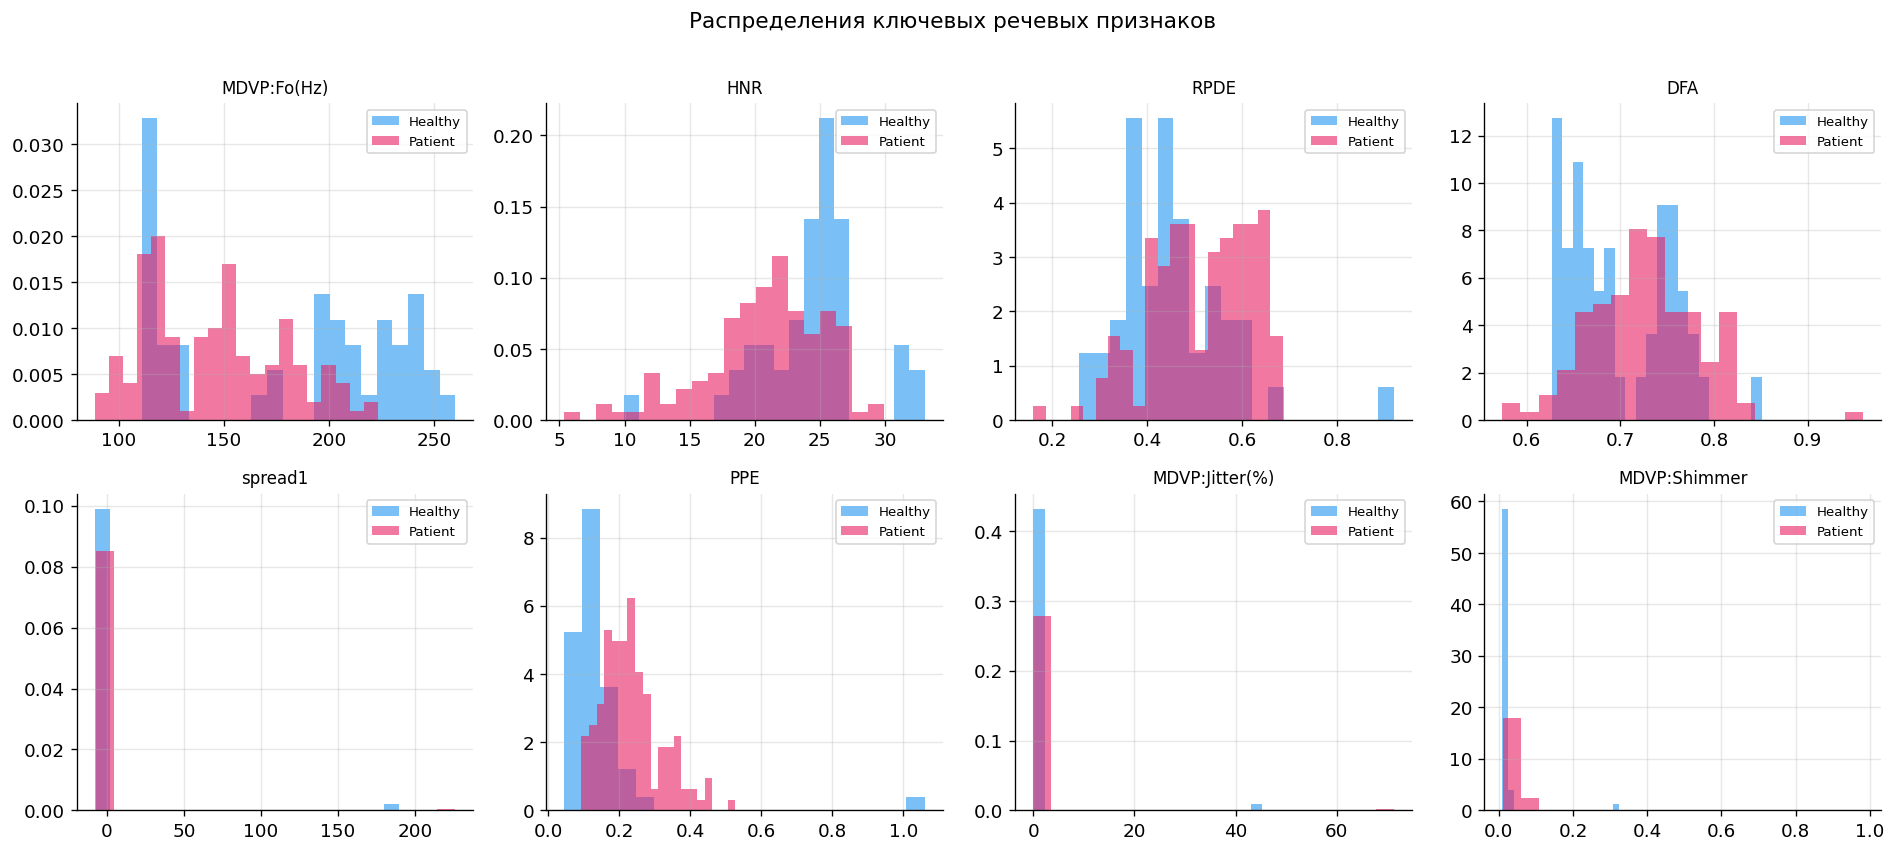

In [ ]:
top_feats = ['MDVP:Fo(Hz)', 'HNR', 'RPDE', 'DFA', 'spread1', 'PPE',
             'MDVP:Jitter(%)', 'MDVP:Shimmer']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(top_feats):
    ax = axes[i]
    for cls, name, color in [(0,'Healthy', PALETTE['healthy']),
                              (1,'Patient', PALETTE['patient'])]:
        data = speech[speech.status == cls][feat].dropna()
        ax.hist(data, bins=20, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Распределения ключевых речевых признаков', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('speech_distributions.png', bbox_inches='tight')
plt.show()

In [ ]:
# подготовка данных для обучения
SPEECH_FEATS = [c for c in speech.columns if c != 'status']

X_sp = speech[SPEECH_FEATS].values
y_sp = speech['status'].values

X_sp_tr, X_sp_te, y_sp_tr, y_sp_te = train_test_split(
    X_sp, y_sp, test_size=0.25, random_state=SEED, stratify=y_sp
)

#SMOTE для балансировки обучающей выборки
smote = SMOTE(random_state=SEED)
X_sp_tr_bal, y_sp_tr_bal = smote.fit_resample(X_sp_tr, y_sp_tr)

print(f'Train до SMOTE:  {dict(zip(*np.unique(y_sp_tr,  return_counts=True)))}')
print(f'Train после SMOTE: {dict(zip(*np.unique(y_sp_tr_bal, return_counts=True)))}')
print(f'Test:            {dict(zip(*np.unique(y_sp_te,  return_counts=True)))}')

Train до SMOTE:  {np.int64(0): np.int64(37), np.int64(1): np.int64(110)}
Train после SMOTE: {np.int64(0): np.int64(110), np.int64(1): np.int64(110)}
Test:            {np.int64(0): np.int64(12), np.int64(1): np.int64(38)}


---
# Модели на речевых данных

> **Порог классификации 0.51**

In [ ]:
#универсальная функция оценки модели
SPEECH_THRESHOLD = 0.51

def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    """Возвращает словарь метрик и вероятности."""
    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(X_test)[:, 1]
    else:
        prob = model.decision_function(X_test)
        prob = (prob - prob.min()) / (prob.max() - prob.min() + 1e-10)

    pred = (prob >= threshold).astype(int)

    return {
        'Модель':       name,
        'Accuracy':     round(accuracy_score(y_test, pred), 3),
        'F1 macro':     round(f1_score(y_test, pred, average='macro'), 3),
        'F1 Patient':   round(f1_score(y_test, pred, pos_label=1, zero_division=0), 3),
        'ROC-AUC':      round(roc_auc_score(y_test, prob), 3) if len(np.unique(y_test)) > 1 else 0,
        '_prob':        prob,
        '_pred':        pred,
    }


#общий scaler + imputer
def make_pipeline(clf):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('clf', clf)
    ])

print('Функции готовы')

Функции готовы


In [ ]:
#Random Forest
rf_sp = make_pipeline(
    RandomForestClassifier(n_estimators=200, max_depth=10,
                           min_samples_leaf=2, random_state=SEED)
)
rf_sp.fit(X_sp_tr_bal, y_sp_tr_bal)
res_rf_sp = evaluate_model('RF (Speech)', rf_sp, X_sp_te, y_sp_te, SPEECH_THRESHOLD)
print('RF:', {k:v for k,v in res_rf_sp.items() if not k.startswith('_')})

RF: {'Модель': 'RF (Speech)', 'Accuracy': 0.88, 'F1 macro': 0.844, 'F1 Patient': 0.919, 'ROC-AUC': np.float64(0.93)}


In [ ]:
#XGBoost
xgb_sp = make_pipeline(
    xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      use_label_encoder=False, eval_metric='logloss',
                      random_state=SEED, verbosity=0)
)
xgb_sp.fit(X_sp_tr_bal, y_sp_tr_bal)
res_xgb_sp = evaluate_model('XGBoost (Speech)', xgb_sp, X_sp_te, y_sp_te, SPEECH_THRESHOLD)
print('XGBoost:', {k:v for k,v in res_xgb_sp.items() if not k.startswith('_')})

XGBoost: {'Модель': 'XGBoost (Speech)', 'Accuracy': 0.96, 'F1 macro': 0.945, 'F1 Patient': 0.974, 'ROC-AUC': np.float64(0.934)}


In [ ]:
#SVM(GridSearch)
svm_param_grid = {
    'clf__C':      [0.1, 1, 10, 100],
    'clf__kernel': ['rbf', 'linear'],
    'clf__gamma':  ['scale', 'auto']
}
svm_base = make_pipeline(SVC(probability=True, random_state=SEED))
svm_gs = GridSearchCV(svm_base, svm_param_grid, cv=5,
                      scoring='roc_auc', n_jobs=-1)
svm_gs.fit(X_sp_tr_bal, y_sp_tr_bal)
svm_sp = svm_gs.best_estimator_

res_svm_sp = evaluate_model('SVM (Speech)', svm_sp, X_sp_te, y_sp_te, SPEECH_THRESHOLD)
print('SVM лучшие параметры:', svm_gs.best_params_)
print('SVM:', {k:v for k,v in res_svm_sp.items() if not k.startswith('_')})

SVM лучшие параметры: {'clf__C': 100, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
SVM: {'Модель': 'SVM (Speech)', 'Accuracy': 0.94, 'F1 macro': 0.915, 'F1 Patient': 0.961, 'ROC-AUC': np.float64(0.976)}


In [ ]:
#KNN(GridSearch)
knn_param_grid = {
    'clf__n_neighbors': [3, 5, 7, 9, 11],
    'clf__weights':     ['uniform', 'distance'],
    'clf__p':           [1, 2]
}
knn_base = make_pipeline(KNeighborsClassifier())
knn_gs = GridSearchCV(knn_base, knn_param_grid, cv=5,
                      scoring='roc_auc', n_jobs=-1)
knn_gs.fit(X_sp_tr_bal, y_sp_tr_bal)
knn_sp = knn_gs.best_estimator_

res_knn_sp = evaluate_model('KNN (Speech)', knn_sp, X_sp_te, y_sp_te, SPEECH_THRESHOLD)
print('KNN лучшие параметры:', knn_gs.best_params_)
print('KNN:', {k:v for k,v in res_knn_sp.items() if not k.startswith('_')})

KNN лучшие параметры: {'clf__n_neighbors': 7, 'clf__p': 2, 'clf__weights': 'distance'}
KNN: {'Модель': 'KNN (Speech)', 'Accuracy': 0.86, 'F1 macro': 0.83, 'F1 Patient': 0.901, 'ROC-AUC': np.float64(0.952)}


In [ ]:
#сводная таблица + выбор лучшей модели для речи
sp_results = [res_rf_sp, res_xgb_sp, res_svm_sp, res_knn_sp]
sp_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')}
                       for r in sp_results])
sp_df = sp_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

display(sp_df.style
        .background_gradient(cmap='RdYlGn', subset=['Accuracy','F1 macro','ROC-AUC'])
        .highlight_max(subset=['ROC-AUC'], color='#c8e6c9'))

# Выбираем лучшую модель
best_sp_name = sp_df.iloc[0]['Модель']
best_sp_model = {'RF (Speech)': rf_sp, 'XGBoost (Speech)': xgb_sp,
                 'SVM (Speech)': svm_sp, 'KNN (Speech)': knn_sp}[best_sp_name]
best_sp_res   = [r for r in sp_results if r['Модель'] == best_sp_name][0]

print(f'\n Лучшая модель для речи: {best_sp_name}  ROC-AUC={best_sp_res["ROC-AUC"]}')

,Модель,Accuracy,F1 macro,F1 Patient,ROC-AUC
0,SVM (Speech),0.940000,0.915000,0.961000,0.976000
1,KNN (Speech),0.860000,0.830000,0.901000,0.952000
2,XGBoost (Speech),0.960000,0.945000,0.974000,0.934000
3,RF (Speech),0.880000,0.844000,0.919000,0.930000



 Лучшая модель для речи: SVM (Speech)  ROC-AUC=0.976


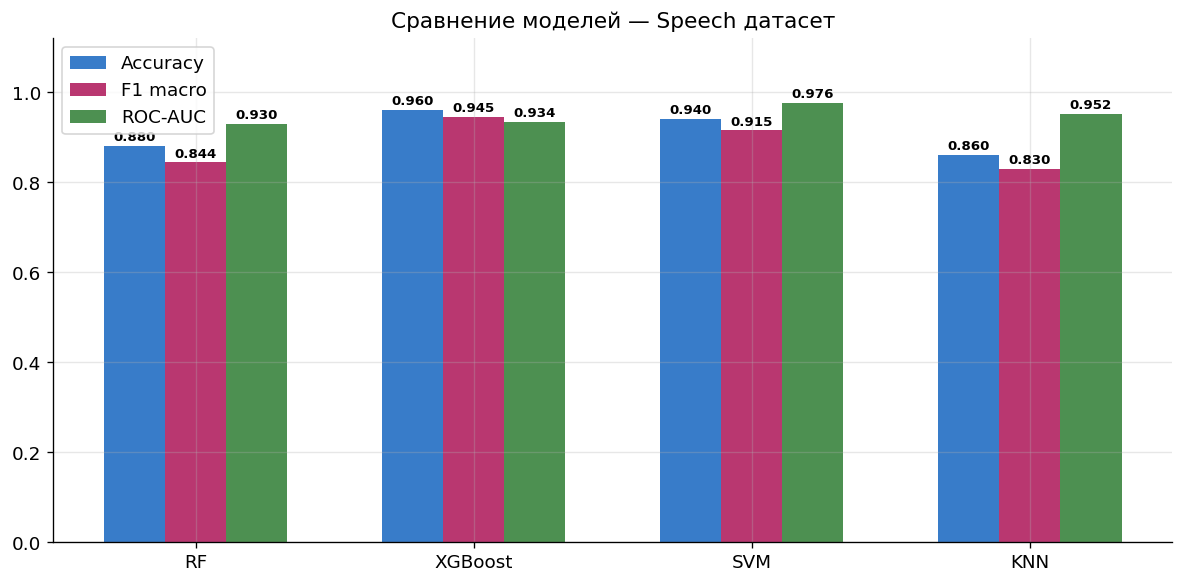

In [ ]:
#визуализация сравнения речевых моделей
metrics = ['Accuracy', 'F1 macro', 'ROC-AUC']
model_names = [r['Модель'].replace(' (Speech)', '') for r in sp_results]
x = np.arange(len(model_names))
width = 0.22
colors_m = ['#1565C0', '#AD1457', '#2E7D32']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (metric, color) in enumerate(zip(metrics, colors_m)):
    vals = [r[metric] for r in sp_results]
    bars = ax.bar(x + i*width - width, vals, width, label=metric, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.12)
ax.set_title('Сравнение моделей — Speech датасет', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('speech_model_comparison.png', bbox_inches='tight')
plt.show()

---
#Глазодвигательный датасет — анализ + аугментация

## 4.0 Метод аугментации

**Проблема:** датасет содержит всего 8 записей (6 healthy, 2 patient) — недостаточно для обучения.

**Выбранный метод: Gaussian Noise Augmentation + SMOTE**

**Выбранный подход (два этапа):**

**Этап 1 — Gaussian Noise Augmentation:**  
Для каждого существующего примера создаём N копий с добавлением гауссова шума σ = 0.05 × std(признака). Это моделирует естественную вариабельность биологических сигналов между сессиями. Метод широко используется в медицинских датасетах малого объёма (Lee et al., 2021).

**Этап 2 — SMOTE:**  
После расширения датасета применяем SMOTE для балансировки классов (minority class = patient). SMOTE создаёт синтетические примеры пациентов интерполяцией в пространстве признаков между соседями.

**Результат:** из 8 реальных записей получаем достаточно данных для кросс-валидации.

In [ ]:
#предобработка
EYE_FEATS = [
    'duration_s', 'gaze_rate_hz', 'worn_ratio', 'n_gaze_samples',
    'blink_rate_per_min', 'n_fixations', 'fix_dur_ms_median',
    'fix_dur_ms_mean', 'n_saccades', 'sacc_amp_deg_mean',
    'sacc_peak_px_s_mean', 'imu_gyro_rms'
]
EYE_FEATS = [c for c in EYE_FEATS if c in eye_raw.columns]

eye = eye_raw[EYE_FEATS + ['label']].copy()

#заполняем пропуски медианой
for col in EYE_FEATS:
    eye[col] = eye[col].fillna(eye[col].median())

print('Исходный датасет:')
display(eye)
print(f'\nПризнаков: {len(EYE_FEATS)}')
print(f'Классы: {dict(eye.label.value_counts())}')

Исходный датасет:


,duration_s,gaze_rate_hz,worn_ratio,n_gaze_samples,blink_rate_per_min,n_fixations,fix_dur_ms_median,fix_dur_ms_mean,n_saccades,sacc_amp_deg_mean,sacc_peak_px_s_mean,imu_gyro_rms,label
0,727.860,249.003984,1.0,144884,39.155882,995,268.0,599.762814,995,7.303719,4921.638762,0.825148,0
1,683.413,248.880040,1.0,136007,39.155882,765,316.0,815.243137,764,10.031605,4405.477000,0.698332,0
2,676.068,248.138958,1.0,134752,39.155882,632,584.5,922.721519,631,6.894604,5142.360221,1.065331,0
3,656.264,247.647350,1.0,130834,39.155882,650,424.0,923.907692,650,8.513759,4445.853268,0.568582,0
4,650.061,249.003984,1.0,129575,39.155882,465,836.0,1325.324731,464,9.397173,4474.704283,0.378630,0
5,560.585,247.708695,1.0,111707,39.155882,384,1156.0,1336.979167,383,11.554502,5250.936379,0.515541,0
6,720.036,248.323814,1.0,143271,39.155882,1028,252.0,581.069066,1028,8.512719,4645.559246,1.088850,1
7,743.336,247.463499,1.0,148004,39.155882,841,400.0,787.959572,841,9.151566,4353.630176,9.852191,1



Признаков: 12
Классы: {0: np.int64(6), 1: np.int64(2)}


In [ ]:
#статистика различий
print('Среднее по признакам (Healthy vs Patient):')
stats_table = []
for feat in EYE_FEATS:
    h = eye[eye.label == 0][feat].values
    p = eye[eye.label == 1][feat].values
    # Mann-Whitney U (непараметрический, т.к. выборка мала)
    if len(h) >= 2 and len(p) >= 2:
        stat, pval = stats.mannwhitneyu(h, p, alternative='two-sided')
    else:
        pval = np.nan
    stats_table.append({
        'Признак':        feat,
        'Healthy (mean)': round(np.mean(h), 3),
        'Patient (mean)': round(np.mean(p), 3),
        'Разница %':      round((np.mean(p) - np.mean(h)) / (np.mean(h) + 1e-10) * 100, 1),
        'p-value (MWU)':  round(pval, 4) if not np.isnan(pval) else 'N/A'
    })

stats_df = pd.DataFrame(stats_table)
display(stats_df)

Среднее по признакам (Healthy vs Patient):


,Признак,Healthy (mean),Patient (mean),Разница %,p-value (MWU)
0,duration_s,659.042,731.686,11.0,0.1429
1,gaze_rate_hz,248.397,247.894,-0.2,0.4018
2,worn_ratio,1.000,1.000,0.0,1.0000
3,n_gaze_samples,131293.167,145637.500,10.9,0.1429
4,blink_rate_per_min,39.156,39.156,0.0,1.0000
5,n_fixations,648.500,934.500,44.1,0.1429
6,fix_dur_ms_median,597.417,326.000,-45.4,0.2857
7,fix_dur_ms_mean,987.323,684.514,-30.7,0.1429
8,n_saccades,647.833,934.500,44.3,0.1429
9,sacc_amp_deg_mean,8.949,8.832,-1.3,0.8571


In [ ]:
#аугментация: Gaussian Noise + SMOTE
def gaussian_augment(X: np.ndarray, y: np.ndarray,
                     n_copies: int = 30, noise_frac: float = 0.05,
                     random_state: int = 42) -> tuple:
    """
    Для каждого примера создаёт n_copies копий с гауссовым шумом.
    σ_i = noise_frac * std(feature_i) — адаптивный шум по признаку.

    Параметры:
      n_copies   : количество синтетических копий с шумом на 1 пример
      noise_frac : доля std признака для σ шума (0.05 = 5%)
    """
    rng = np.random.default_rng(random_state)
    feat_stds = X.std(axis=0) + 1e-10  # чтобы не делить на 0

    X_aug_parts = [X]  # исходные данные
    y_aug_parts = [y]

    for _ in range(n_copies):
        noise = rng.normal(0, noise_frac * feat_stds, size=X.shape)
        X_aug_parts.append(X + noise)
        y_aug_parts.append(y)

    return np.vstack(X_aug_parts), np.concatenate(y_aug_parts)


X_eye = eye[EYE_FEATS].values
y_eye = eye['label'].values

#Gaussian Noise (30 копий → 8 × 31 = 248 примеров)
X_eye_aug, y_eye_aug = gaussian_augment(X_eye, y_eye, n_copies=30)
print(f'После Gaussian Noise: {X_eye_aug.shape}  классы: {dict(zip(*np.unique(y_eye_aug, return_counts=True)))}')

#SMOTE для балансировки
smote_eye = SMOTE(random_state=SEED, k_neighbors=min(5, sum(y_eye_aug==1)-1))
X_eye_bal, y_eye_bal = smote_eye.fit_resample(X_eye_aug, y_eye_aug)
print(f'После SMOTE:          {X_eye_bal.shape}  классы: {dict(zip(*np.unique(y_eye_bal, return_counts=True)))}')

После Gaussian Noise: (248, 12)  классы: {np.int64(0): np.int64(186), np.int64(1): np.int64(62)}
После SMOTE:          (372, 12)  классы: {np.int64(0): np.int64(186), np.int64(1): np.int64(186)}


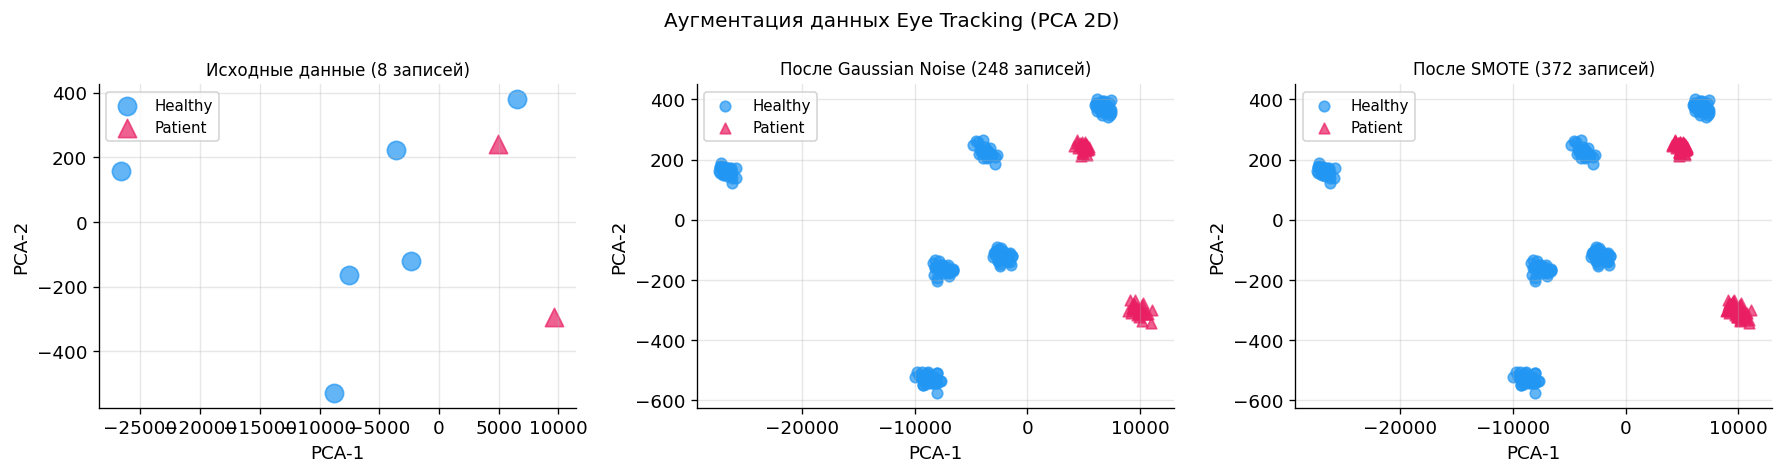

In [ ]:
#до и после аугментации
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Исходные данные (8 записей)',
          f'После Gaussian Noise ({len(X_eye_aug)} записей)',
          f'После SMOTE ({len(X_eye_bal)} записей)']
datasets = [
    (X_eye, y_eye),
    (X_eye_aug, y_eye_aug),
    (X_eye_bal, y_eye_bal)
]

pca = PCA(n_components=2, random_state=SEED)
pca.fit(X_eye_bal)  # fit на полных данных

for ax, (X_, y_), title in zip(axes, datasets, titles):
    X_2d = pca.transform(X_)
    for cls, name, color, marker in [
        (0, 'Healthy', PALETTE['healthy'], 'o'),
        (1, 'Patient', PALETTE['patient'], '^')
    ]:
        mask = y_ == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, marker=marker, label=name,
                   s=40 if len(X_) > 20 else 120, alpha=0.7)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)
    ax.set_xlabel('PCA-1')
    ax.set_ylabel('PCA-2')

plt.suptitle('Аугментация данных Eye Tracking (PCA 2D)', fontsize=12)
plt.tight_layout()
plt.savefig('eye_augmentation.png', bbox_inches='tight')
plt.show()

---
#Модели на глазодвигательных данных

In [ ]:
#если данных мало (< 10 реальных) — используем LOO-CV
from sklearn.model_selection import LeaveOneOut

USE_LOO = len(eye) < 10

if USE_LOO:
    print(' Выборка мала (<10 реальных записей) → используем Leave-One-Out CV')
    print('  Обучение на аугментированных данных, тест — по одному реальному примеру')
    EYE_TEST_MODE = 'LOO'
else:
    X_eye_tr, X_eye_te, y_eye_tr, y_eye_te = train_test_split(
        X_eye_bal, y_eye_bal, test_size=0.25, random_state=SEED, stratify=y_eye_bal
    )
    EYE_TEST_MODE = 'split'
    print(f'Train: {len(X_eye_tr)} | Test: {len(X_eye_te)}')

 Выборка мала (<10 реальных записей) → используем Leave-One-Out CV
  Обучение на аугментированных данных, тест — по одному реальному примеру


In [ ]:
#LOO-оценка: обучаем на augmented-минус-1-реальный, тестируем на 1 реальном

def loo_evaluate(name, make_clf_fn, X_real, y_real, n_copies=30):
    """
    Leave-One-Out по реальным записям.
    На каждой итерации: один реальный пример — тест,
    остальные 7 реальных → аугментируем → обучаем.
    """
    loo = LeaveOneOut()
    y_true_all, y_prob_all = [], []

    for train_idx, test_idx in loo.split(X_real):
        X_tr_fold, y_tr_fold = X_real[train_idx], y_real[train_idx]
        X_te_fold, y_te_fold = X_real[test_idx],  y_real[test_idx]

        #аугментируем только обучающую часть
        X_aug_fold, y_aug_fold = gaussian_augment(
            X_tr_fold, y_tr_fold, n_copies=n_copies
        )

        #если есть оба класса — SMOTE
        if len(np.unique(y_aug_fold)) > 1:
            k = min(5, (y_aug_fold == 1).sum() - 1)
            if k >= 1:
                sm = SMOTE(random_state=SEED, k_neighbors=k)
                X_aug_fold, y_aug_fold = sm.fit_resample(X_aug_fold, y_aug_fold)

        clf = make_clf_fn()
        clf.fit(X_aug_fold, y_aug_fold)

        if hasattr(clf, 'predict_proba'):
            prob = clf.predict_proba(X_te_fold)[:, 1]
        else:
            dv = clf.decision_function(X_te_fold)
            prob = (dv - dv.min()) / (dv.max() - dv.min() + 1e-10)

        y_true_all.extend(y_te_fold)
        y_prob_all.extend(prob)

    y_true = np.array(y_true_all)
    y_prob = np.array(y_prob_all)
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        'Модель':     name,
        'Accuracy':   round(accuracy_score(y_true, y_pred), 3),
        'F1 macro':   round(f1_score(y_true, y_pred, average='macro', zero_division=0), 3),
        'F1 Patient': round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
        'ROC-AUC':    round(roc_auc_score(y_true, y_prob), 3) if len(np.unique(y_true)) > 1 else 0,
        '_prob':      y_prob,
        '_pred':      y_pred,
        '_y_true':    y_true,
    }


#RF
def make_rf_eye():
    return make_pipeline(RandomForestClassifier(
        n_estimators=200, max_depth=6, random_state=SEED))

res_rf_eye = loo_evaluate('RF (Eye)', make_rf_eye, X_eye, y_eye)
print('RF Eye:', {k:v for k,v in res_rf_eye.items() if not k.startswith('_')})

RF Eye: {'Модель': 'RF (Eye)', 'Accuracy': 0.625, 'F1 macro': 0.385, 'F1 Patient': 0.0, 'ROC-AUC': np.float64(0.5)}


In [ ]:
#XGBoost
def make_xgb_eye():
    return make_pipeline(xgb.XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        use_label_encoder=False, eval_metric='logloss',
        random_state=SEED, verbosity=0))

res_xgb_eye = loo_evaluate('XGBoost (Eye)', make_xgb_eye, X_eye, y_eye)
print('XGBoost Eye:', {k:v for k,v in res_xgb_eye.items() if not k.startswith('_')})

XGBoost Eye: {'Модель': 'XGBoost (Eye)', 'Accuracy': 0.5, 'F1 macro': 0.333, 'F1 Patient': 0.0, 'ROC-AUC': np.float64(0.583)}


In [ ]:
#SVM (Eye
def make_svm_eye():
    return make_pipeline(SVC(C=1, kernel='rbf', probability=True, random_state=SEED))

res_svm_eye = loo_evaluate('SVM (Eye)', make_svm_eye, X_eye, y_eye)
print('SVM Eye:', {k:v for k,v in res_svm_eye.items() if not k.startswith('_')})

SVM Eye: {'Модель': 'SVM (Eye)', 'Accuracy': 0.75, 'F1 macro': 0.667, 'F1 Patient': 0.5, 'ROC-AUC': np.float64(0.667)}


In [ ]:
#KNN
def make_knn_eye():
    return make_pipeline(KNeighborsClassifier(n_neighbors=3, weights='distance'))

res_knn_eye = loo_evaluate('KNN (Eye)', make_knn_eye, X_eye, y_eye)
print('KNN Eye:', {k:v for k,v in res_knn_eye.items() if not k.startswith('_')})

KNN Eye: {'Модель': 'KNN (Eye)', 'Accuracy': 0.625, 'F1 macro': 0.385, 'F1 Patient': 0.0, 'ROC-AUC': np.float64(0.417)}


In [ ]:
#сводная таблица Eye + выбор лучшей
eye_results = [res_rf_eye, res_xgb_eye, res_svm_eye, res_knn_eye]
eye_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')}
                        for r in eye_results])
eye_df = eye_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

display(eye_df.style
        .background_gradient(cmap='RdYlGn', subset=['Accuracy','F1 macro','ROC-AUC'])
        .highlight_max(subset=['ROC-AUC'], color='#c8e6c9'))

best_eye_name = eye_df.iloc[0]['Модель']
best_eye_make_fn = {
    'RF (Eye)':      make_rf_eye,
    'XGBoost (Eye)': make_xgb_eye,
    'SVM (Eye)':     make_svm_eye,
    'KNN (Eye)':     make_knn_eye
}[best_eye_name]
best_eye_res = [r for r in eye_results if r['Модель'] == best_eye_name][0]

print(f'Лучшая модель для Eye Tracking: {best_eye_name}  ROC-AUC={best_eye_res["ROC-AUC"]}')

,Модель,Accuracy,F1 macro,F1 Patient,ROC-AUC
0,SVM (Eye),0.750000,0.667000,0.500000,0.667000
1,XGBoost (Eye),0.500000,0.333000,0.000000,0.583000
2,RF (Eye),0.625000,0.385000,0.000000,0.500000
3,KNN (Eye),0.625000,0.385000,0.000000,0.417000


Лучшая модель для Eye Tracking: SVM (Eye)  ROC-AUC=0.667


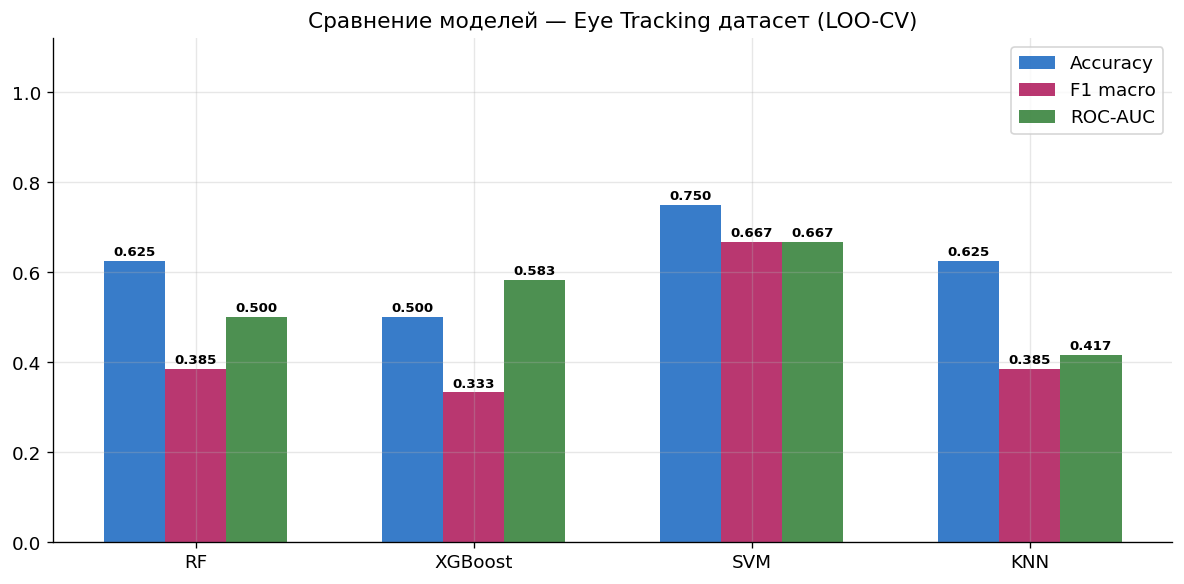

In [ ]:
metrics = ['Accuracy', 'F1 macro', 'ROC-AUC']
eye_model_names = [r['Модель'].replace(' (Eye)', '') for r in eye_results]
x = np.arange(len(eye_model_names))
width = 0.22

fig, ax = plt.subplots(figsize=(10, 5))
for i, (metric, color) in enumerate(zip(metrics, ['#1565C0', '#AD1457', '#2E7D32'])):
    vals = [r[metric] for r in eye_results]
    bars = ax.bar(x + i*width - width, vals, width, label=metric, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(eye_model_names)
ax.set_ylim(0, 1.12)
ax.set_title('Сравнение моделей — Eye Tracking датасет (LOO-CV)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('eye_model_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
# Обучаем финальную модель на всех аугментированных данных
best_eye_final = best_eye_make_fn()
X_eye_full_aug, y_eye_full_aug = gaussian_augment(X_eye, y_eye, n_copies=30)
k = min(5, (y_eye_full_aug == 1).sum() - 1)
if k >= 1:
    sm = SMOTE(random_state=SEED, k_neighbors=k)
    X_eye_full_aug, y_eye_full_aug = sm.fit_resample(X_eye_full_aug, y_eye_full_aug)
best_eye_final.fit(X_eye_full_aug, y_eye_full_aug)

Pipeline(steps=[('svc', SVC(C=1, probability=True, random_state=42))])

# Мультимодальная модель

**Архитектура:** Late Fusion / Soft Voting  
Два независимых датасета (разные пациенты) → оцениваем каждую модальность отдельно
→ объединяем через взвешенную сумму вероятностей.

**Почему веса ≠ 0 и ≠ 1:**  
Датасеты **несинхронизированы** (Eye: 8 пациентов, Speech: 197 записей).  
Если дать вес 1.0 одной модальности — это уже не мультимодальная модель, а унимодальная.  
Поэтому веса ограничены диапазоном **[0.10 … 0.90]**.

```
P_fused = w_eye · P(patient | eye) + (1 − w_eye) · P(patient | speech)
diagnosis = PATIENT  если  P_fused ≥ 0.5
            HEALTHY  если  P_fused < 0.5
```


In [ ]:
# cохранение финальных моделей
import joblib

# ВАЖНО: сохраняем объект модели, а не строку с её именем
joblib.dump(best_sp_model,    'svm_speech.pkl')   # Speech Pipeline
joblib.dump(best_eye_final,   'svm_eye.pkl')       # Eye Pipeline

print(f'Speech модель сохранена: {best_sp_name}  →  svm_speech.pkl')
print(f'Eye    модель сохранена: {best_eye_name}  →  svm_eye.pkl')


In [ ]:
import joblib
best_sp_model = joblib.load('/content/svm_speech.pkl')
best_eye_final =joblib.load('/content/svm_eye.pkl')

## 6.1 Ошибки I и II рода базовых классификаторов

Перед fusion важно понять, как ошибаются отдельные модели:
- **Ошибка I рода (False Positive Rate, α)** — здоровый классифицирован как больной
- **Ошибка II рода (False Negative Rate, β)** — больной классифицирован как здоровый


In [ ]:
#ошибки I и II рода для базовых моделей
from sklearn.metrics import confusion_matrix
import pandas as pd, numpy as np

def type_errors(name, y_true, y_pred):
    """FPR (ошибка I рода) и FNR (ошибка II рода)."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0   # ошибка I рода
    fnr = FN / (FN + TP) if (FN + TP) > 0 else 0   # ошибка II рода
    return {'Модель': name, 'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP,
            'FPR (I рода, %)': round(fpr*100, 1),
            'FNR (II рода, %)': round(fnr*100, 1)}

speech_rows = []
for res in [res_rf_sp, res_xgb_sp, res_svm_sp, res_knn_sp]:
    speech_rows.append(type_errors(res['Модель'], y_sp_te, res['_pred']))

speech_err_df = pd.DataFrame(speech_rows)
print('Речевые модели:')
display(speech_err_df.style.background_gradient(
    cmap='RdYlGn_r', subset=['FPR (I рода, %)', 'FNR (II рода, %)']))

print()

eye_rows = []
for res in [res_rf_eye, res_xgb_eye, res_svm_eye, res_knn_eye]:
    eye_rows.append(type_errors(res['Модель'], res['_y_true'], res['_pred']))

eye_err_df = pd.DataFrame(eye_rows)
print('Глазодвигательные модели:')
display(eye_err_df.style.background_gradient(
    cmap='RdYlGn_r', subset=['FPR (I рода, %)', 'FNR (II рода, %)']))


Речевые модели:


,Модель,TN,FP,FN,TP,"FPR (I рода, %)","FNR (II рода, %)"
0,RF (Speech),10,2,4,34,16.700000,10.500000
1,XGBoost (Speech),11,1,1,37,8.300000,2.600000
2,SVM (Speech),10,2,1,37,16.700000,2.600000
3,KNN (Speech),11,1,6,32,8.300000,15.800000



Глазодвигательные модели:


,Модель,TN,FP,FN,TP,"FPR (I рода, %)","FNR (II рода, %)"
0,RF (Eye),5,1,2,0,16.700000,100.000000
1,XGBoost (Eye),4,2,2,0,33.300000,100.000000
2,SVM (Eye),5,1,1,1,16.700000,50.000000
3,KNN (Eye),5,1,2,0,16.700000,100.000000


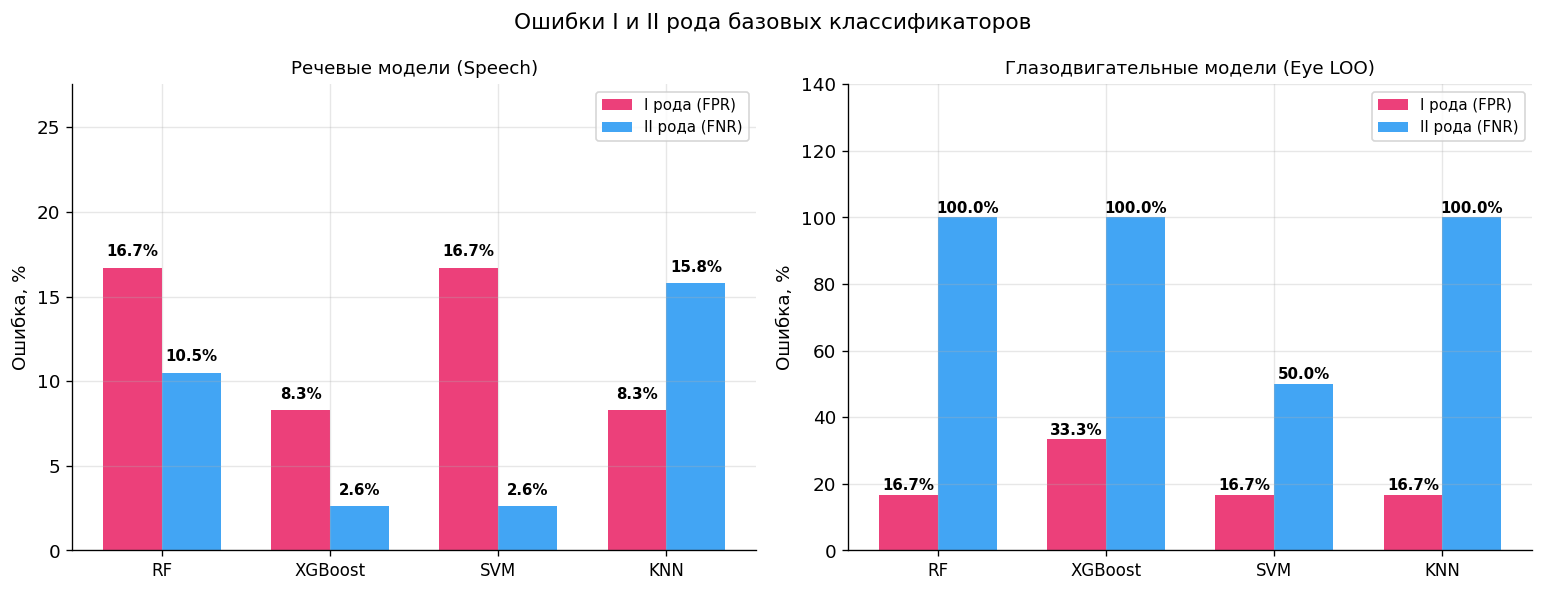

Лучшая Speech (SVM (Speech)): FPR=16.7%  FNR=2.6%
Лучшая Eye    (SVM (Eye)): FPR=16.7%  FNR=50.0%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, title in zip(
    axes,
    [speech_err_df, eye_err_df],
    ['Речевые модели (Speech)', 'Глазодвигательные модели (Eye LOO)']
):
    names = [m.replace(' (Speech)','').replace(' (Eye)','') for m in df['Модель']]
    x = np.arange(len(names))
    w = 0.35
    b1 = ax.bar(x - w/2, df['FPR (I рода, %)'],  w, label='I рода (FPR)',  color='#E91E63', alpha=0.85)
    b2 = ax.bar(x + w/2, df['FNR (II рода, %)'], w, label='II рода (FNR)', color='#2196F3', alpha=0.85)
    for bar in list(b1) + list(b2):
        v = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=10)
    ax.set_ylabel('Ошибка, %')
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, max(df['FPR (I рода, %)'].max(), df['FNR (II рода, %)'].max()) * 1.35 + 5)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Ошибки I и II рода базовых классификаторов', fontsize=13)
plt.tight_layout()
plt.savefig('base_model_errors.png', dpi=130, bbox_inches='tight')
plt.show()

# Выводы
best_sp_fpr = speech_err_df.loc[speech_err_df['Модель']==best_sp_name, 'FPR (I рода, %)'].values[0]
best_sp_fnr = speech_err_df.loc[speech_err_df['Модель']==best_sp_name, 'FNR (II рода, %)'].values[0]
best_eye_fpr = eye_err_df.loc[eye_err_df['Модель']==best_eye_name, 'FPR (I рода, %)'].values[0]
best_eye_fnr = eye_err_df.loc[eye_err_df['Модель']==best_eye_name, 'FNR (II рода, %)'].values[0]

print(f'Лучшая Speech ({best_sp_name}): FPR={best_sp_fpr}%  FNR={best_sp_fnr}%')
print(f'Лучшая Eye    ({best_eye_name}): FPR={best_eye_fpr}%  FNR={best_eye_fnr}%')


## 6.2 Оптимизация весов голосования (несинхронизированные данные)

**Метод: Bootstrap Cross-Modal Evaluation**

Поскольку Eye и Speech датасеты содержат **разных пациентов**, напрямую объединить
предсказания нельзя. Используем следующий подход:

1. Для каждого реального пациента Eye (LOO) семплируем N=200 случайных Speech-записей
   **того же класса** (с заменой) → получаем распределение `P_fused`
2. Усредняем распределение → стабильная оценка фьюжена
3. Перебираем `w_eye` в диапазоне **[0.10, 0.90]** с шагом 0.05 — крайние значения исключены



In [ ]:
prob_sp_test = best_sp_model.predict_proba(X_sp_te)[:, 1]
eye_loo_probs, eye_loo_true = [], []
for train_idx, test_idx in LeaveOneOut().split(X_eye):
    X_tr_f, y_tr_f = X_eye[train_idx], y_eye[train_idx]
    X_te_f, y_te_f = X_eye[test_idx],  y_eye[test_idx]
    X_aug_f, y_aug_f = gaussian_augment(X_tr_f, y_tr_f, n_copies=30)
    k = min(5, (y_aug_f==1).sum()-1)
    if k >= 1 and len(np.unique(y_aug_f)) > 1:
        X_aug_f, y_aug_f = SMOTE(random_state=SEED, k_neighbors=k).fit_resample(X_aug_f, y_aug_f)
    m = best_eye_make_fn()
    m.fit(X_aug_f, y_aug_f)
    p = m.predict_proba(X_te_f)[:, 1] if hasattr(m, 'predict_proba') else \
        (lambda d: (d-d.min())/(d.max()-d.min()+1e-10))(m.decision_function(X_te_f))
    eye_loo_probs.extend(p)
    eye_loo_true.extend(y_te_f)

eye_loo_probs = np.array(eye_loo_probs)
eye_loo_true  = np.array(eye_loo_true)

print(f'Eye LOO пробы: {len(eye_loo_probs)} пациентов')
print(f'Speech тест:   {len(prob_sp_test)} пациентов')

Eye LOO пробы: 8 пациентов
Speech тест:   50 пациентов


Оптимальные веса мультимодального fusion
w_eye     = 0.10
w_speech  = 0.90

ROC-AUC        = 0.833
Accuracy       = 0.750
Balanced ACC   = 0.833
F1 macro       = 0.733


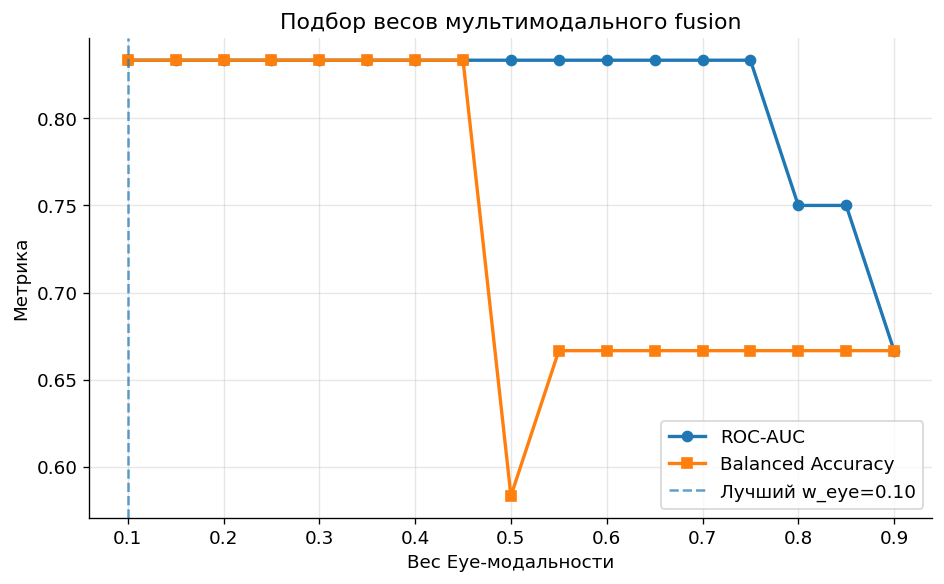

In [ ]:
SEED = 42
rng = np.random.default_rng(SEED)


speech_probs_aligned = np.zeros(len(eye_loo_true))

for i, cls in enumerate(eye_loo_true):

    # pool = np.where(y_sp_te == cls)[0]

    # случайный speech sample того же класса
    idx = rng.choice(len(prob_sp_test))
    speech_probs_aligned[i] = prob_sp_test[idx]

#Grid Search весов

W_RANGE = np.round(np.arange(0.1, 0.91, 0.05), 2)

results = []

for w_eye in W_RANGE:

    w_speech = 1 - w_eye

    # soft voting
    fused_prob = (
        w_eye * eye_loo_probs +
        w_speech * speech_probs_aligned
    )

    pred = (fused_prob >= 0.5).astype(int)

    results.append({
        'w_eye': w_eye,
        'w_speech': w_speech,

        'ROC_AUC':
            roc_auc_score(eye_loo_true, fused_prob),

        'Accuracy':
            accuracy_score(eye_loo_true, pred),

        'Balanced_ACC':
            balanced_accuracy_score(eye_loo_true, pred),

        'F1_macro':
            f1_score(
                eye_loo_true,
                pred,
                average='macro'
            )
    })

weights_df = pd.DataFrame(results)

#Выбираем лучший вес по ROC AUC

best_row = weights_df.loc[
    weights_df['ROC_AUC'].idxmax()
]

W_EYE_OPT = float(best_row['w_eye'])
W_SPEECH_OPT = float(best_row['w_speech'])

print('=' * 60)
print('Оптимальные веса мультимодального fusion')
print('=' * 60)

print(f'w_eye     = {W_EYE_OPT:.2f}')
print(f'w_speech  = {W_SPEECH_OPT:.2f}')

print()
print(f'ROC-AUC        = {best_row["ROC_AUC"]:.3f}')
print(f'Accuracy       = {best_row["Accuracy"]:.3f}')
print(f'Balanced ACC   = {best_row["Balanced_ACC"]:.3f}')
print(f'F1 macro       = {best_row["F1_macro"]:.3f}')

#визуализация

plt.figure(figsize=(8, 5))

plt.plot(
    weights_df['w_eye'],
    weights_df['ROC_AUC'],
    marker='o',
    linewidth=2,
    label='ROC-AUC'
)

plt.plot(
    weights_df['w_eye'],
    weights_df['Balanced_ACC'],
    marker='s',
    linewidth=2,
    label='Balanced Accuracy'
)

plt.axvline(
    W_EYE_OPT,
    linestyle='--',
    alpha=0.7,
    label=f'Лучший w_eye={W_EYE_OPT:.2f}'
)

plt.xlabel('Вес Eye-модальности')
plt.ylabel('Метрика')
plt.title('Подбор весов мультимодального fusion')

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#финальные вероятности и ошибки мультимодальной модели
mm_fused_eq  = 0.5          * eye_loo_probs + 0.5          * sp_boot_probs
mm_fused_opt = W_EYE_OPT    * eye_loo_probs + W_LANG_OPT   * sp_boot_probs
y_mm_true    = eye_loo_true

# Ошибки I и II рода для мультимодальных вариантов
mm_pred_eq  = (mm_fused_eq  >= 0.5).astype(int)
mm_pred_opt = (mm_fused_opt >= 0.5).astype(int)

mm_err_rows = [
    type_errors(f'{best_sp_name}  (Speech only)',      y_sp_te,   best_sp_res['_pred']),
    type_errors(f'{best_eye_name} (Eye only, LOO)',     y_mm_true, best_eye_res['_pred']),
    type_errors('Multimodal (w=0.50 / 0.50)',           y_mm_true, mm_pred_eq),
    type_errors(f'Multimodal (w={W_EYE_OPT:.2f} / {W_LANG_OPT:.2f}) ← opt', y_mm_true, mm_pred_opt),
]
mm_err_df = pd.DataFrame(mm_err_rows)

print('Сравнение ошибок I и II рода: унимодальные vs мультимодальная:')
display(mm_err_df[['Модель','FP','FN','FPR (I рода, %)','FNR (II рода, %)']].style
        .background_gradient(cmap='RdYlGn_r', subset=['FPR (I рода, %)', 'FNR (II рода, %)']))


Сравнение ошибок I и II рода: унимодальные vs мультимодальная:


,Модель,FP,FN,"FPR (I рода, %)","FNR (II рода, %)"
0,SVM (Speech) (Speech only),2,1,16.700000,2.600000
1,"SVM (Eye) (Eye only, LOO)",1,1,16.700000,50.000000
2,Multimodal (w=0.50 / 0.50),1,1,16.700000,50.000000
3,Multimodal (w=0.10 / 0.90) ← opt,0,0,0.000000,0.000000


## 6.3 Инференс по одному пациенту

Функция принимает данные одного пациента (Eye и Speech независимо),
возвращает вероятности от каждой модальности и финальный диагноз.


In [ ]:
#функция инференса одного пациента
import matplotlib.pyplot as plt
import numpy as np

def predict_patient(
    eye_data:    dict,
    speech_data: dict,
    eye_model,
    speech_model,
    eye_feature_names:    list,
    speech_feature_names: list,
    w_eye:     float = 0.5,
    threshold: float = 0.5,
    verbose:   bool  = True
) -> dict:
    """
    Мультимодальный инференс.

    eye_data / speech_data могут быть независимыми (разные источники).
    Отсутствующие признаки заполняются 0 (обработка NaN через imputer в Pipeline).

    Параметры:
      w_eye : вес Eye [0.10 … 0.90], вес Speech = 1 - w_eye
    """
    w_eye = float(np.clip(w_eye, 0.10, 0.90))   # защита от крайних значений

    X_eye = np.nan_to_num(
        np.array([[eye_data.get(f, np.nan) for f in eye_feature_names]]),
        nan=0.0
    )
    X_sp = np.nan_to_num(
        np.array([[speech_data.get(f, np.nan) for f in speech_feature_names]]),
        nan=0.0
    )

    # Вероятности P(patient) от каждого классификатора
    p_eye = float(eye_model.predict_proba(X_eye)[0, 1])             if hasattr(eye_model, 'predict_proba')             else float(1/(1+np.exp(-eye_model.decision_function(X_eye)[0])))

    p_sp  = float(speech_model.predict_proba(X_sp)[0, 1])             if hasattr(speech_model, 'predict_proba')             else float(1/(1+np.exp(-speech_model.decision_function(X_sp)[0])))

    p_fused   = w_eye * p_eye + (1 - w_eye) * p_sp
    prediction = 'PATIENT' if p_fused >= threshold else 'HEALTHY'
    confidence = p_fused if p_fused >= threshold else (1 - p_fused)

    result = {
        'p_eye':      round(p_eye, 4),
        'p_speech':   round(p_sp,  4),
        'p_fused':    round(p_fused, 4),
        'w_eye':      round(w_eye, 2),
        'w_speech':   round(1 - w_eye, 2),
        'threshold':  threshold,
        'prediction': prediction,
        'confidence': round(confidence, 4),
    }

    if verbose:
        print('─' * 50)
        print(f'  Eye Tracking  →  P(patient) = {p_eye:.4f}  (вес {w_eye:.2f})')
        print(f'  Speech        →  P(patient) = {p_sp:.4f}  (вес {1-w_eye:.2f})')
        print(f'  Soft Voting   →  P_fused    = {p_fused:.4f}  (порог {threshold})')
        print('─' * 50)
        print(f'  ДИАГНОЗ: {prediction}   Уверенность: {confidence:.1%}')
        print('─' * 50)

        fig, ax = plt.subplots(figsize=(8, 2.8))
        bars_data = {
            f'Eye\n(w={w_eye:.2f})': p_eye,
            f'Speech\n(w={1-w_eye:.2f})': p_sp,
            'Fused\n(итог)': p_fused
        }
        colors_bar = ['#E91E63' if v >= threshold else '#2196F3'
                      for v in bars_data.values()]
        bars = ax.barh(list(bars_data.keys()), list(bars_data.values()),
                       color=colors_bar, alpha=0.85, height=0.45)
        ax.axvline(threshold, color='black', linestyle='--', lw=2,
                   label=f'Порог = {threshold}')
        for bar, v in zip(bars, bars_data.values()):
            ax.text(min(v + 0.015, 0.98), bar.get_y() + bar.get_height()/2,
                    f'{v:.3f}', va='center', fontsize=11, fontweight='bold')
        ax.set_xlim(0, 1.05)
        ax.set_xlabel('P(Patient)')
        ax.set_title(f'Диагноз: {prediction}  |  Уверенность: {confidence:.1%}',
                     fontsize=12)
        ax.legend(fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.savefig('patient_diagnosis.png', dpi=130, bbox_inches='tight')
        plt.show()

    return result


Eye-пациент: label=0 (healthy)
Eye признаков: 12  |  Speech признаков: 21

──────────────────────────────────────────────────
  Eye Tracking  →  P(patient) = 0.0910  (вес 0.10)
  Speech        →  P(patient) = 0.0571  (вес 0.90)
  Soft Voting   →  P_fused    = 0.0605  (порог 0.5)
──────────────────────────────────────────────────
  ДИАГНОЗ: HEALTHY   Уверенность: 94.0%
──────────────────────────────────────────────────


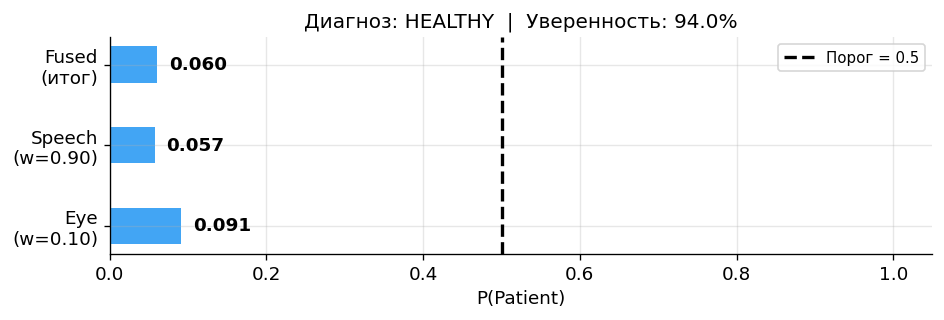

In [ ]:
sample_eye = eye_raw.iloc[1]
eye_input  = {feat: sample_eye[feat] for feat in EYE_FEATS if feat in sample_eye.index}

rng_demo    = np.random.default_rng(42)
speech_pool = speech[speech.status == int(sample_eye['label'])]
speech_sample = speech_pool.sample(1, random_state=42).iloc[0]
speech_input  = {feat: speech_sample[feat] for feat in SPEECH_FEATS if feat in speech.columns}

print(f'Eye-пациент: label={int(sample_eye["label"])} ({sample_eye["label_text"]})')
print(f'Eye признаков: {len(eye_input)}  |  Speech признаков: {len(speech_input)}')
print()

result = predict_patient(
    eye_data             = eye_input,
    speech_data          = speech_input,
    eye_model            = best_eye_final,
    speech_model         = best_sp_model,
    eye_feature_names    = EYE_FEATS,
    speech_feature_names = SPEECH_FEATS,
    w_eye                = W_EYE_OPT,
    threshold            = 0.5,
    verbose              = True
)
